In [ ]:
library(tidyverse)
library(MASS)
library(anndata)
library(pbapply)
library(ggplot2)
library(scales)
library(reshape2)
library(ggridges)
library(viridis)
library(hrbrthemes)
library(patchwork)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ purrr::%||%()   masks base::%||%()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select



Attaching package: ‘anndata’


The following object is masked from ‘package:readr’:

    read_csv



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


Loading required package: viridisLite


Attaching package: ‘viridis’


T

# Set options

In [2]:
options(repr.plot.width = 15, repr.plot.height = 8)
set.seed(seed = 1)


# Load data

In [3]:
adata <- read_h5ad("/mnt/weird_vol/projects/ifnb_nsc/5prime10x_2024/processing/Ifit1KO_WT_young_old_10x_processed.h5ad")
adata


AnnData object with n_obs × n_vars = 8799 × 2500
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'cell_barcode', 'genotype', 'tissue', 'mouse', 'sample', 'hto_success', 'percent.mt', 'Sample', 'Genotype', 'Age', 'Region', 'HTO', 'batch', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'S_score', 'G2M_score', 'phase', 'age_global'
    var: 'gene_ids', 'feature_types', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'Age_colors', 'Genotype_colors', 'HTO_classification.global_colors', 'HTO_colors', 'Region_colors', 'Sample_colors', 'age_global_colors', 'batch_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'phase_colors', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'lognorm'
    obsp: 'connectivities', 'distances'

In [4]:
adata$X <- adata$layers["lognorm"]


# Check data properties

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  230.6   469.5   527.0   533.8   584.8   963.3 

CCTTCGAAGCCAGGAT-1 
              1349

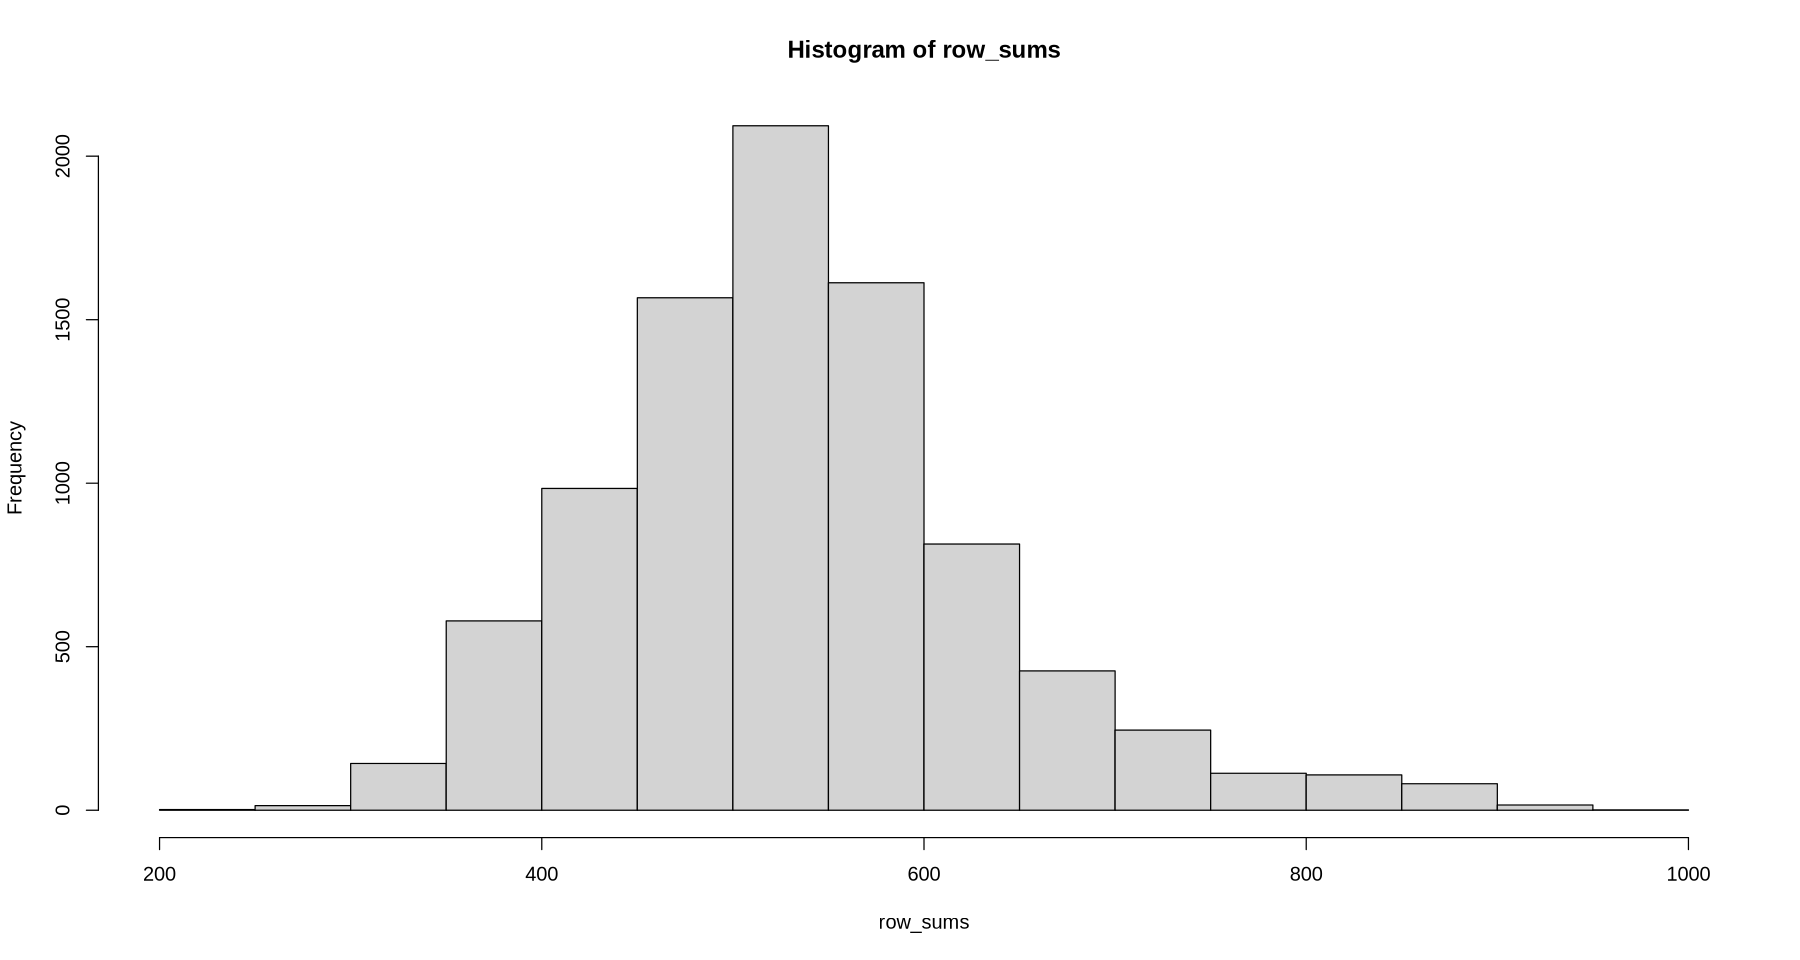

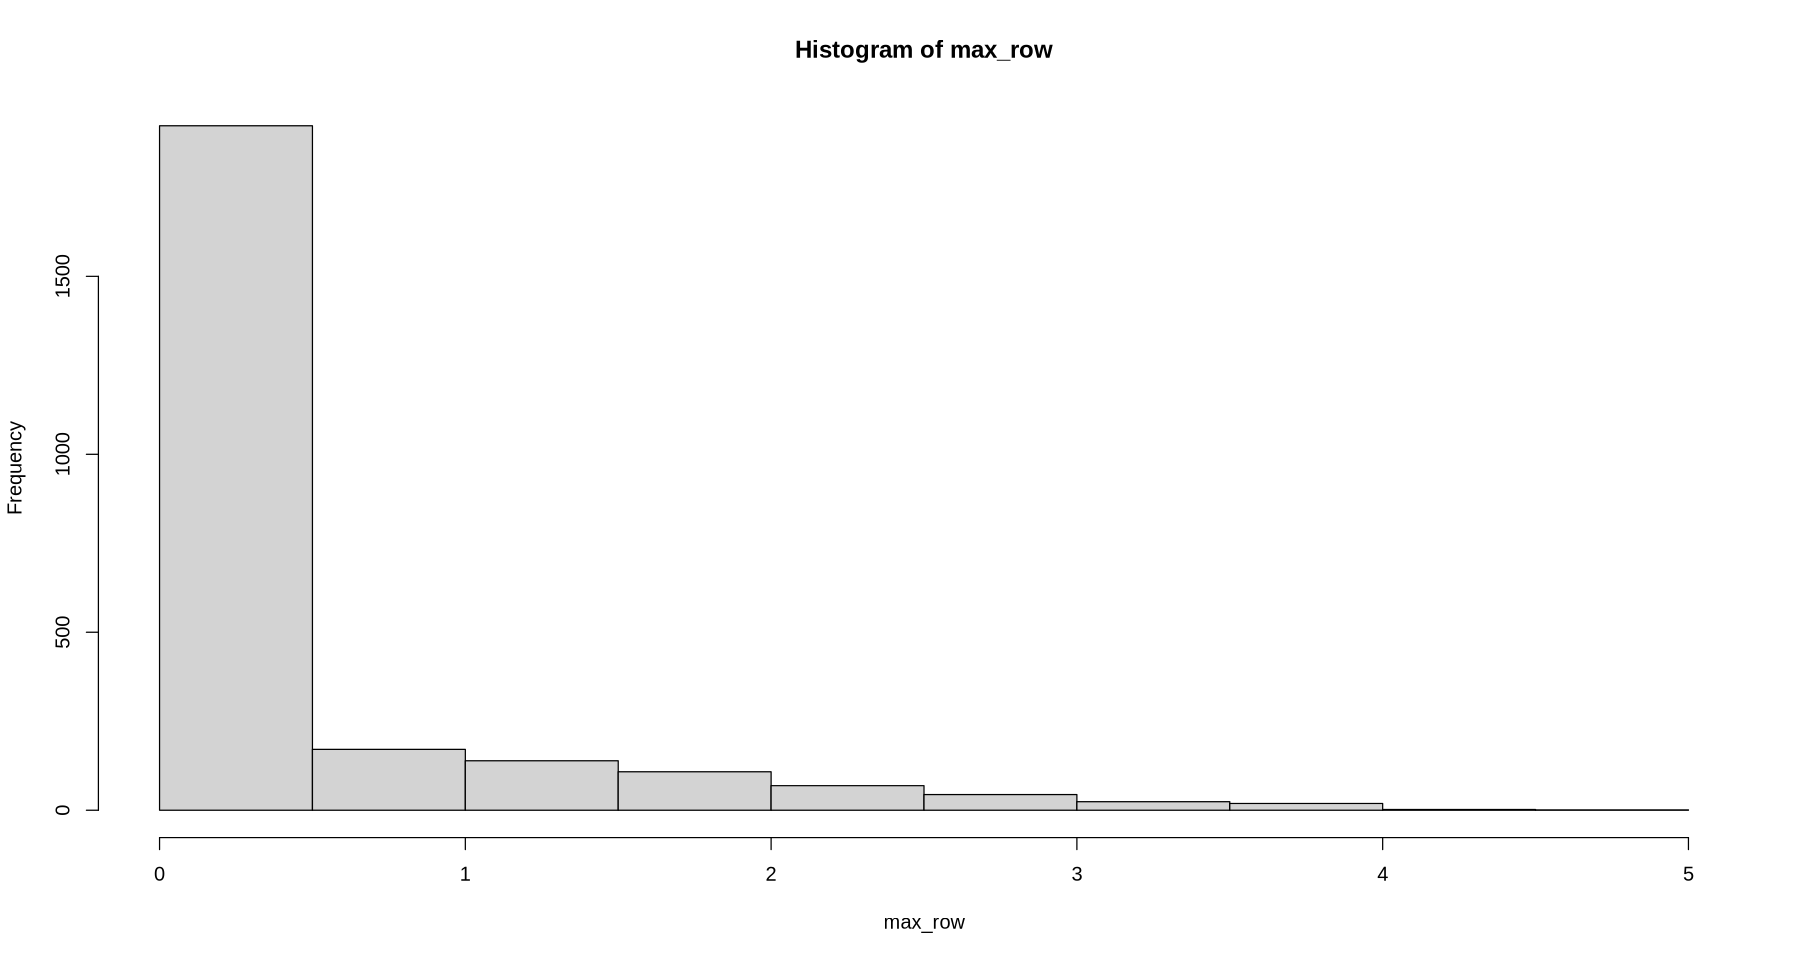

In [87]:
# Calculate row sums
row_sums <- rowSums(as.matrix(adata$X))
hist(row_sums)

# Summary statistics of row sums
summary(row_sums)

# Get the row with the maximum sum value
max_row_index <- which.max(row_sums)
max_row <- adata$X[max_row_index, ]
max_row_index
hist(max_row)


     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
    1.246    30.364   585.660  1878.663  2296.393 30695.965 

Cst3 
 338

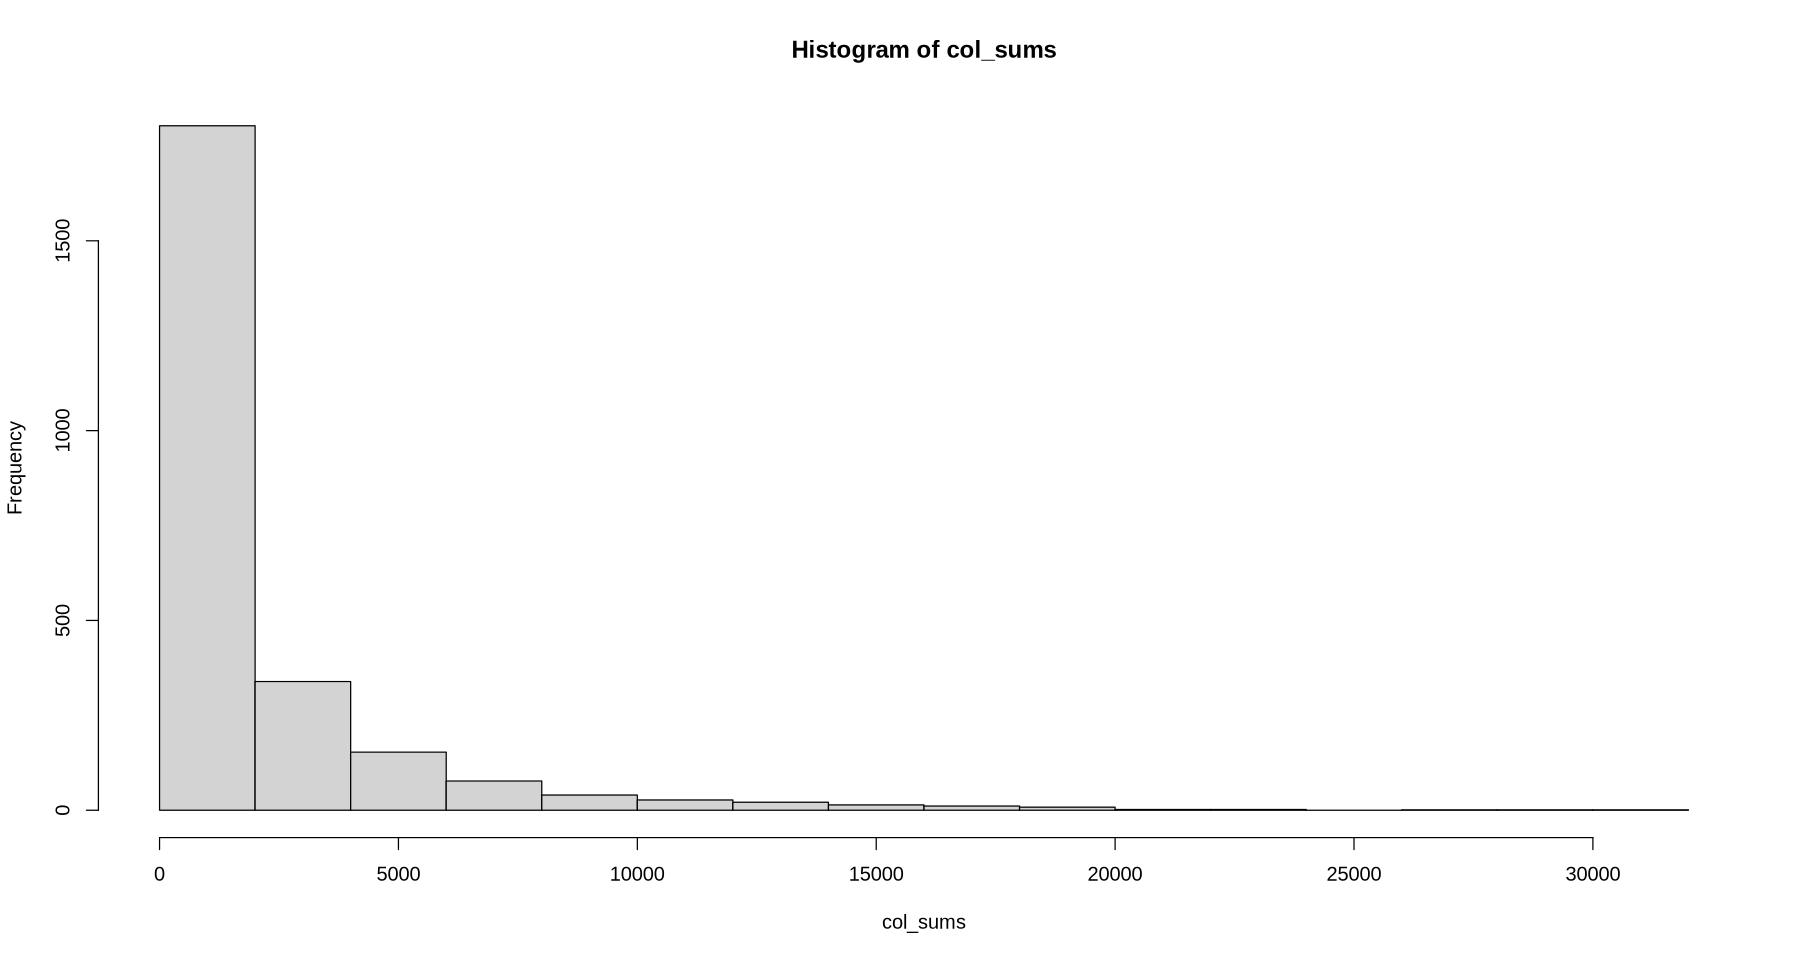

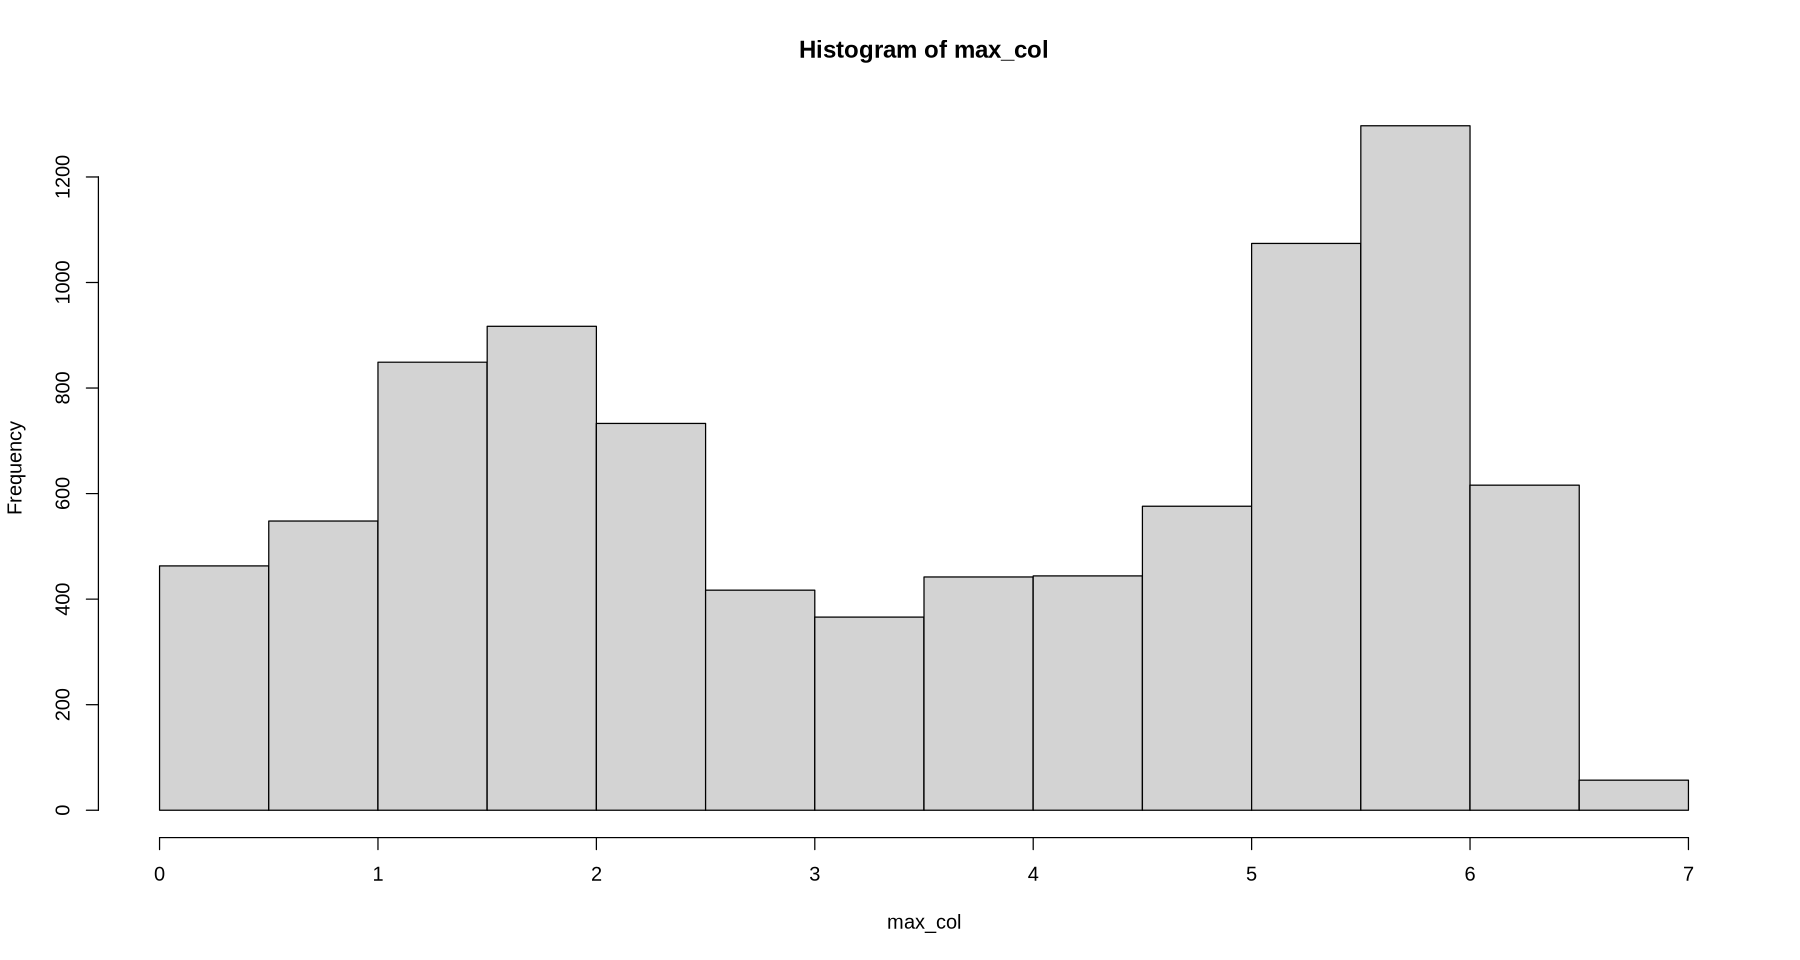

In [88]:
# Calculate row sums
col_sums <- colSums(as.matrix(adata$X))
hist(col_sums)

# Summary statistics of row sums
summary(col_sums)

# Get the row with the maximum sum value
max_col_index <- which.max(col_sums)
max_col <- adata$X[, max_col_index]
max_col_index
hist(max_col)


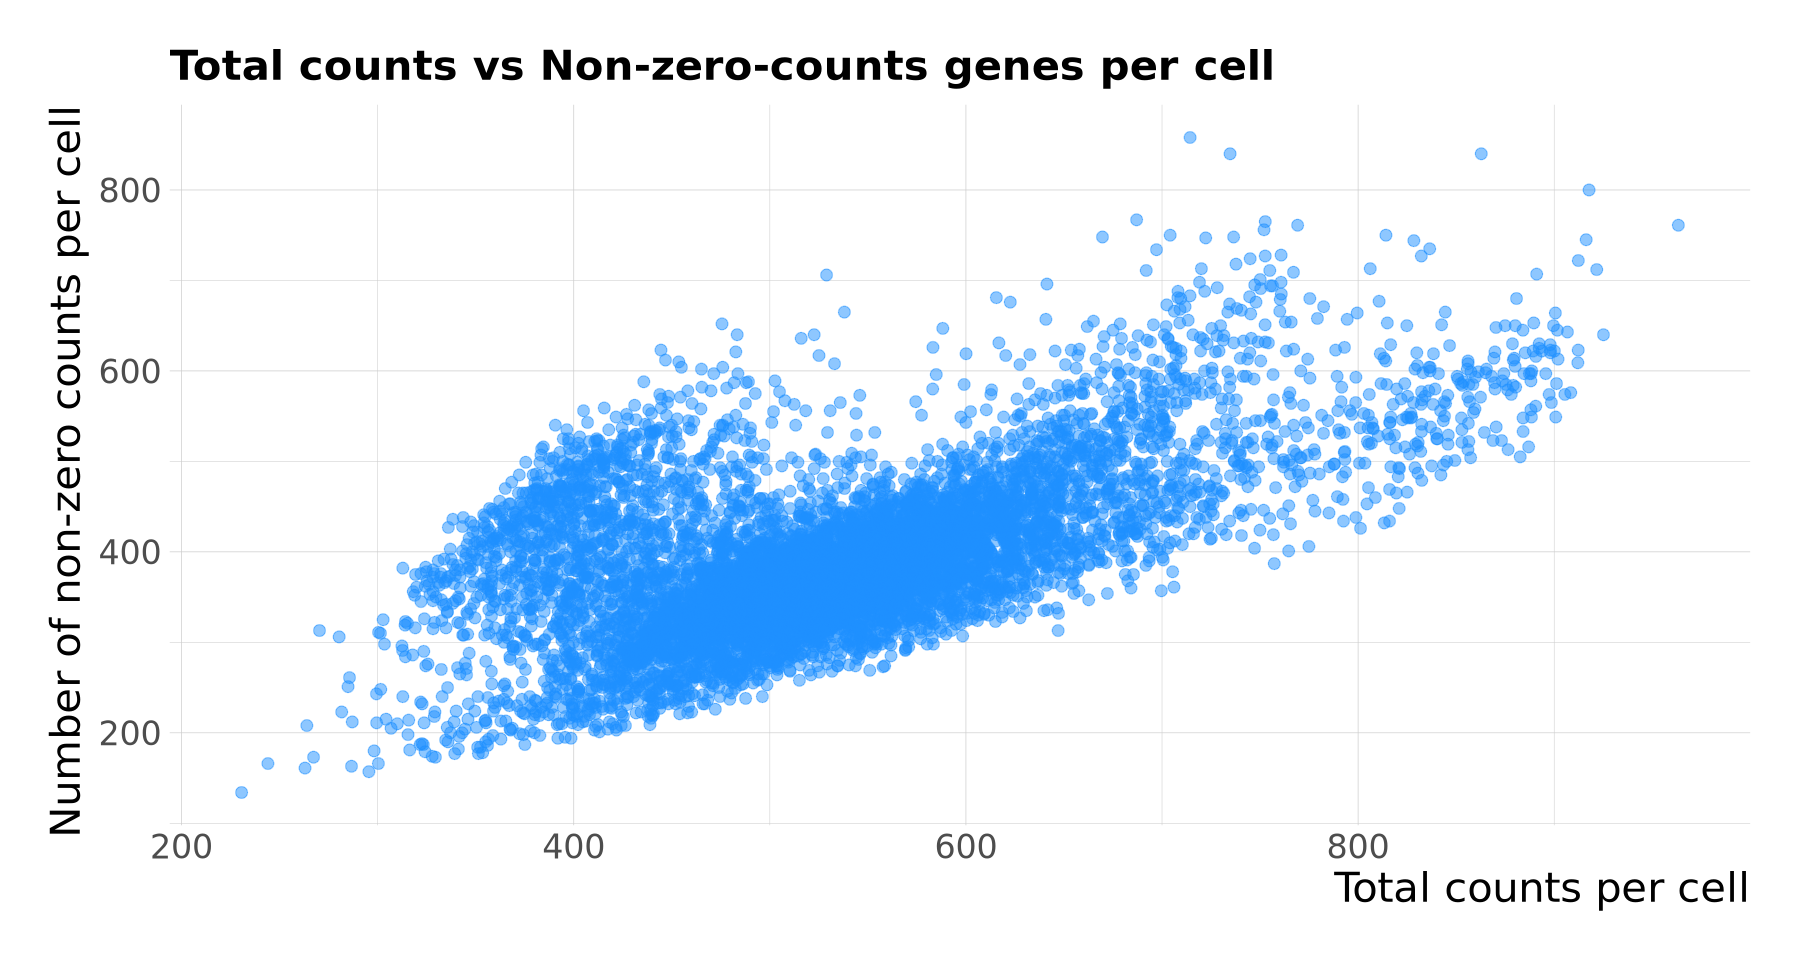

In [5]:
# Calculate the number of rows where sum(counts) > 0
non_zero_counts <- rowSums(as.matrix(adata$X) > 0)

# Create a data frame for plotting
plot_data <- data.frame(Counts = rowSums(as.matrix(adata$X)), NonZeroCounts = non_zero_counts)

# Plot using ggplot2
ggplot(plot_data, aes(x = Counts, y = NonZeroCounts)) +
    geom_point(alpha = 0.5, color = "dodgerblue", size = 3) +
    labs(
        title = "Total counts vs Non-zero-counts genes per cell",
        x = "Total counts per cell",
        y = "Number of non-zero counts per cell"
    ) +
    theme_ipsum_rc(base_size = 20, plot_title_size = 25, axis_title_size = 25)


In [ ]:
df <- as.matrix(adata$X)
dim(df)

# Function to calculate Hartigan's dip statistic
hartigans_dip <- function(x) {
    x <- sort(x)
    n <- length(x)
    gcm <- numeric(n)
    lcm <- numeric(n)
    dip <- 0

    for (i in 1:n) {
        gcm[i] <- max(cumsum(x[1:i]) / (1:i))
        lcm[i] <- min(cumsum(x[i:n]) / (1:(n - i + 1)))
    }

    for (i in 1:(n - 1)) {
        dip <- max(dip, gcm[i] - lcm[i + 1])
    }

    return(dip)
}

# Function to perform a bootstrap test for unimodality
bootstrap_test <- function(column, n_bootstrap = 100) {
    observed_dip <- hartigans_dip(column)
    bootstrap_dips <- replicate(n_bootstrap, hartigans_dip(sample(column, replace = TRUE)))
    p_value <- mean(bootstrap_dips >= observed_dip)
    return(p_value)
}

# Function to check modality of a column
is_bimodal <- function(column) {
    p_value <- bootstrap_test(column)
    return(p_value < 0.05) # Reject unimodality if p-value < 0.05
}

# Randomly sample X number of columns
set.seed(1) # For reproducibility
sampled_columns <- sample(1:ncol(df), 5)
df_sample <- df[, sampled_columns]

# Apply the function to each column of the sampled data
bimodal_columns <- apply(df_sample, 2, is_bimodal)

# Calculate the percentage of bimodal columns
percent_bimodal <- sum(bimodal_columns) / ncol(df_sample) * 100

cat("Percentage of bimodal columns in the sample:", percent_bimodal, "%\n")


[1] 8799 2500

Percentage of bimodal columns in the sample: 0 %


# Simulating one gene

## Unimodal data

### Poisson

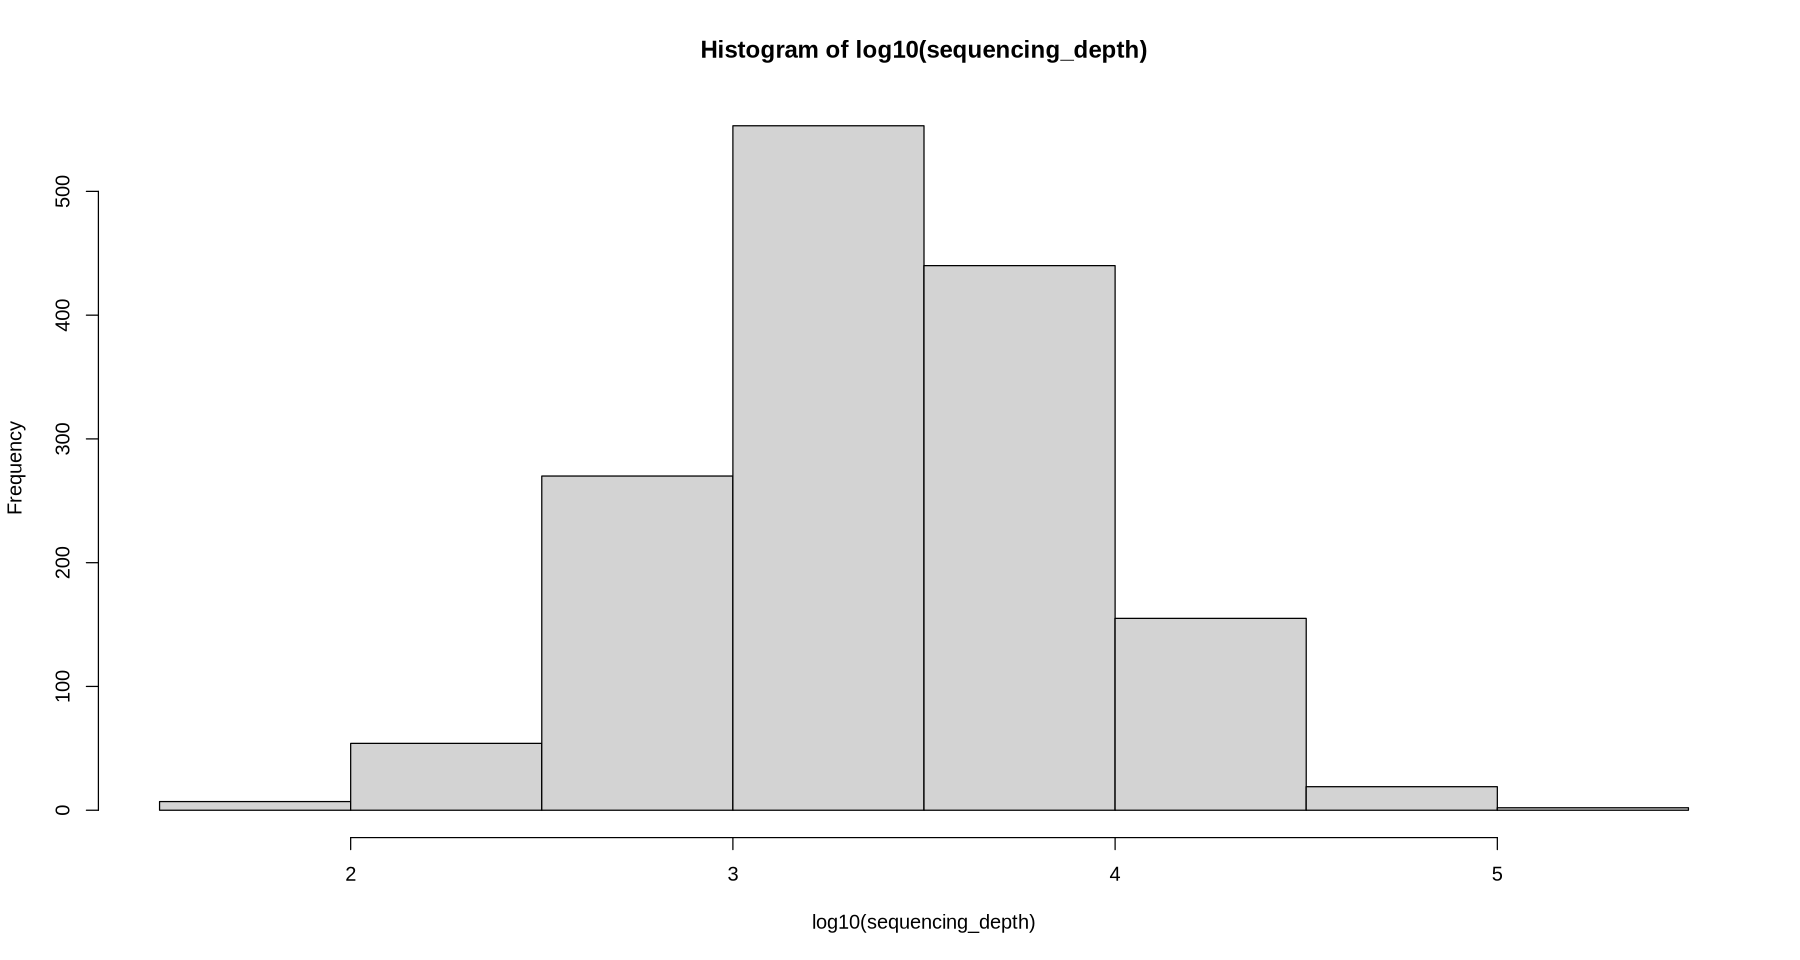

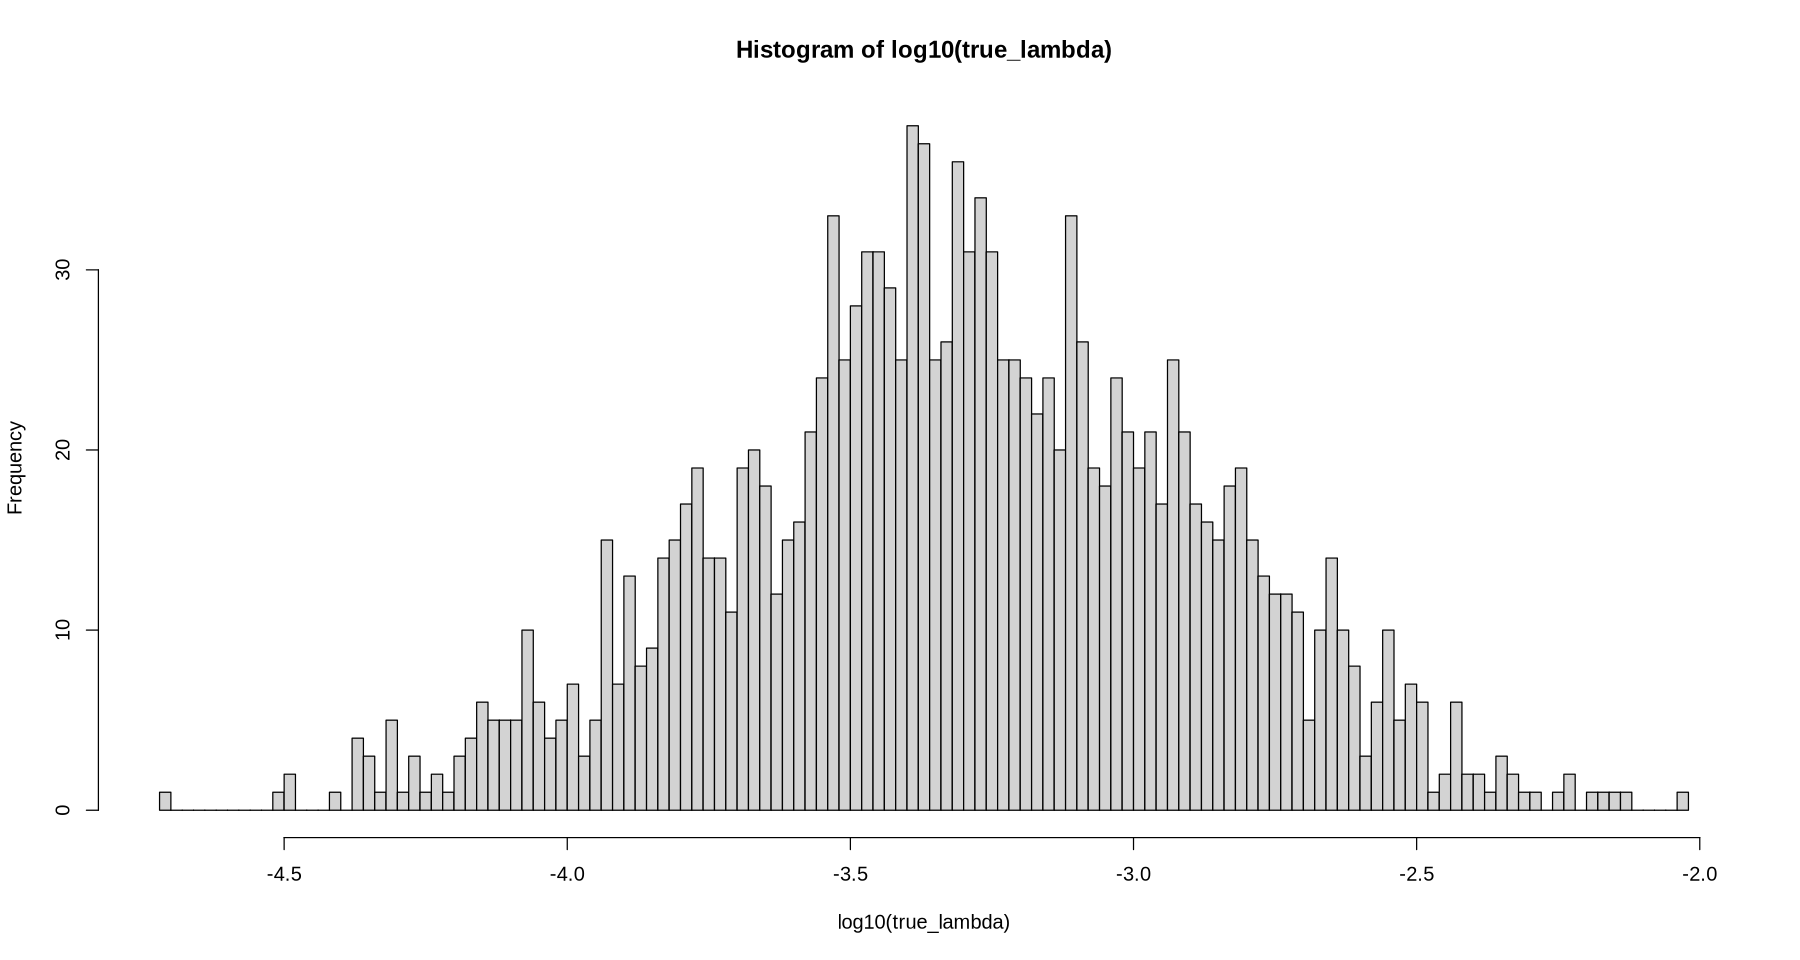

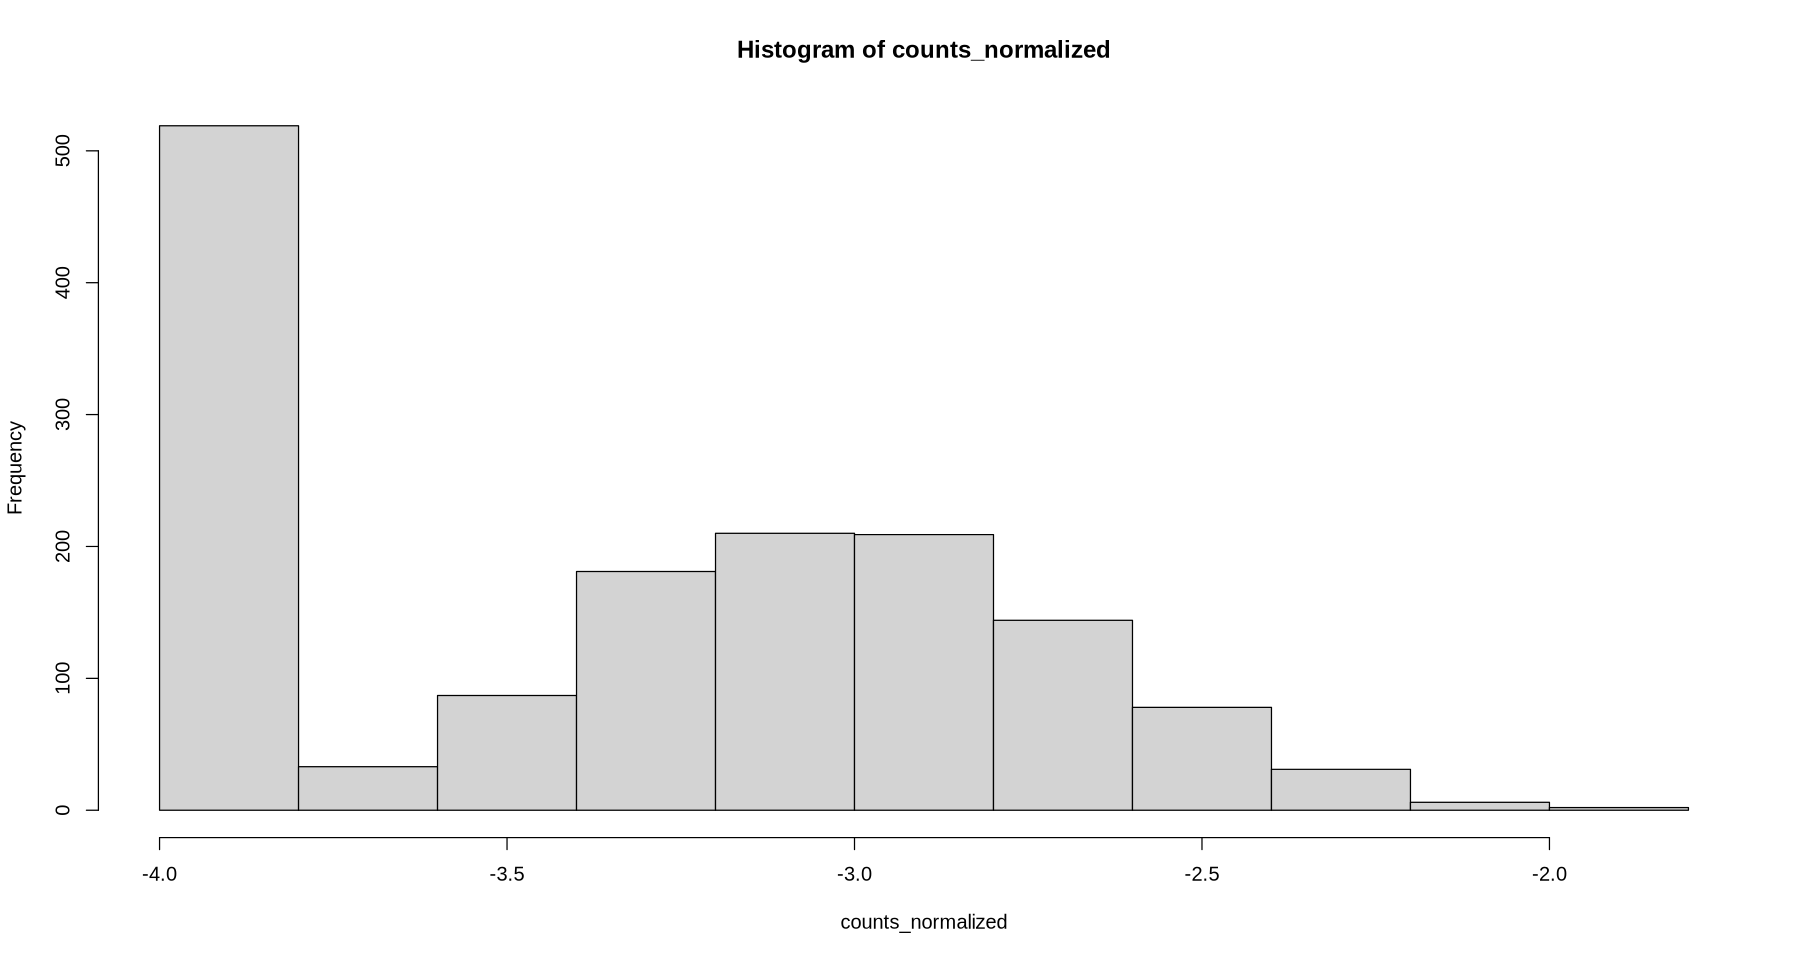

In [2]:
# Number of cells to simulate
n <- 1500

# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n, log10(mean_size), std_size))
hist(log10(sequencing_depth))

# Simulate the true expression rate for each cell
mean_rate <- -3.3 # corresponds to expression rate around 10^(-3.3) = 0.0005
std_rate <- 0.4
true_lambda <- 10^rnorm(n, mean_rate, std_rate)
hist(log10(true_lambda), 100)

# Simulate the observed read counts per cell as a poisson process
# The expected count for each cell is proportional to the true expression rate and the sequencing depth
counts <- rpois(n, true_lambda * sequencing_depth)
# Normalize the expression counts per cell and log-transform them
counts_normalized <- log10(counts / sequencing_depth + 1e-4)
hist(counts_normalized)


### Negative binomial

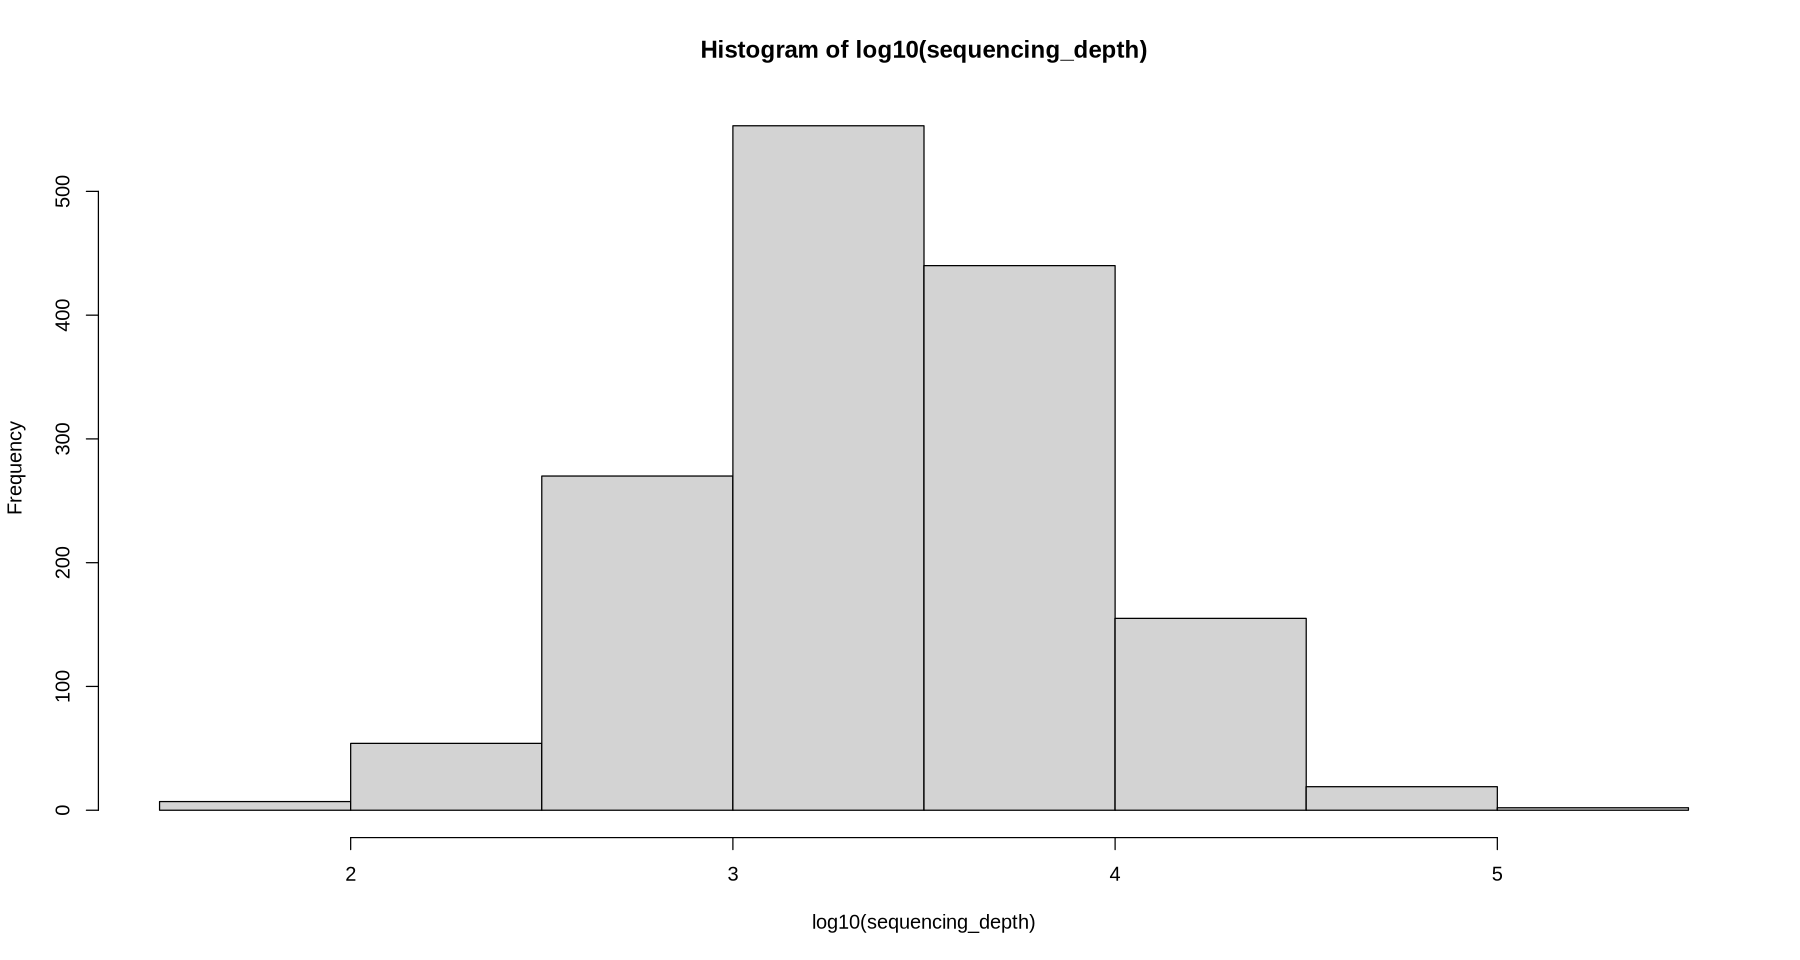

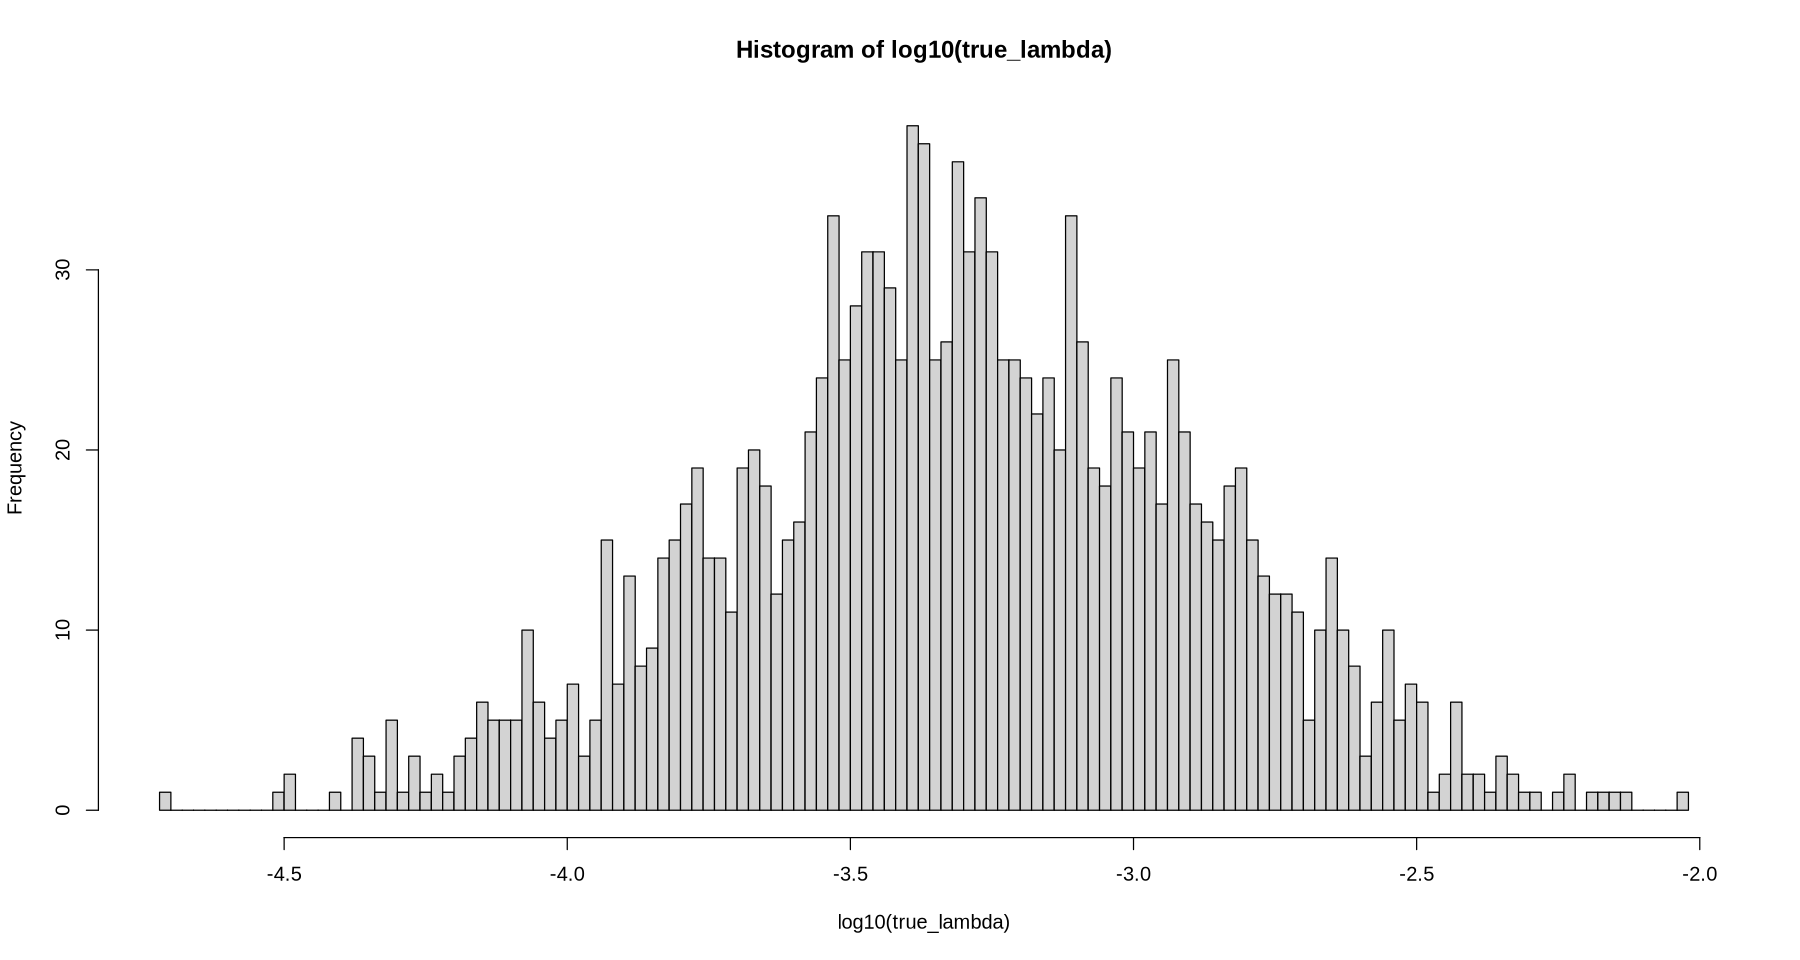

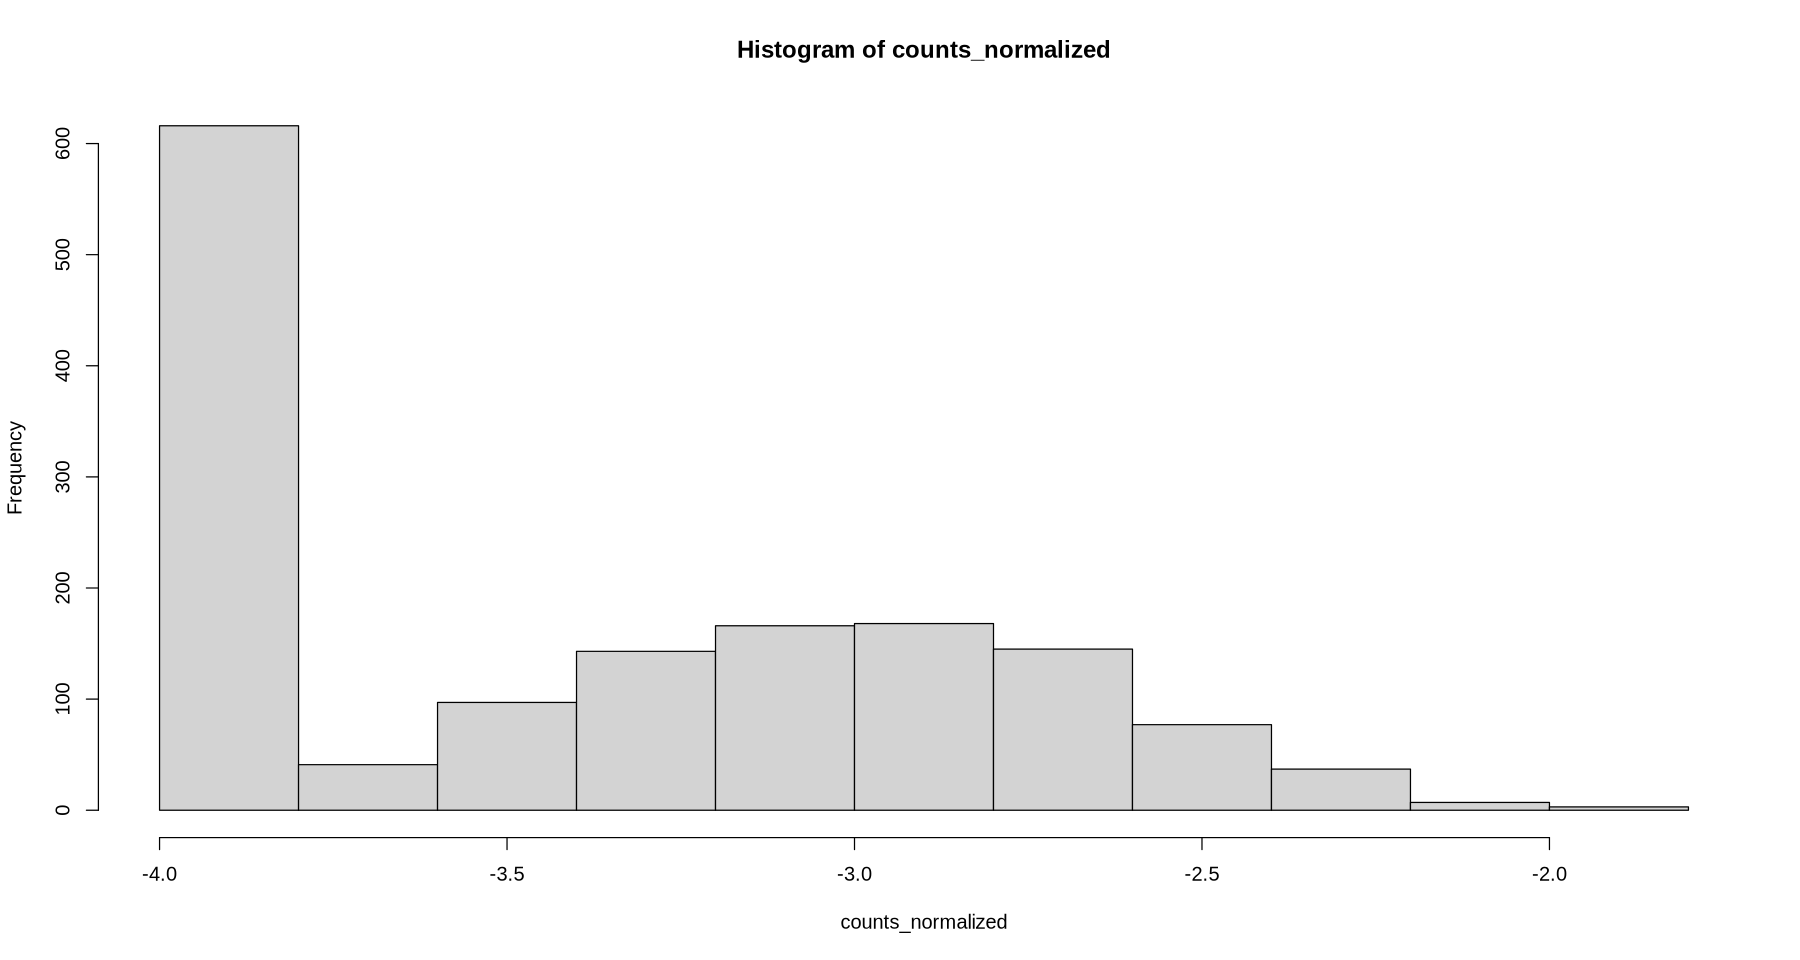

In [5]:
# Number of cells to simulate
n <- 1500

# Dispersion parameter
theta <- 3

# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n, log10(mean_size), std_size))
hist(log10(sequencing_depth))

# Simulate the true expression rate for each cell
mean_rate <- -3.3 # corresponds to expression rate around 10^(-3.3) = 0.0005
std_rate <- 0.4
true_lambda <- 10^rnorm(n, mean_rate, std_rate)
hist(log10(true_lambda), 100)

# Simulate the observed read counts per cell as a poisson process
# The expected count for each cell is proportional to the true expression rate and the sequencing depth
counts <- rnbinom(n, size = theta, mu = true_lambda * sequencing_depth)
# Normalize the expression counts per cell and log-transform them
counts_normalized <- log10(counts / sequencing_depth + 1e-4)
hist(counts_normalized)


## Bimodal data

### Poisson

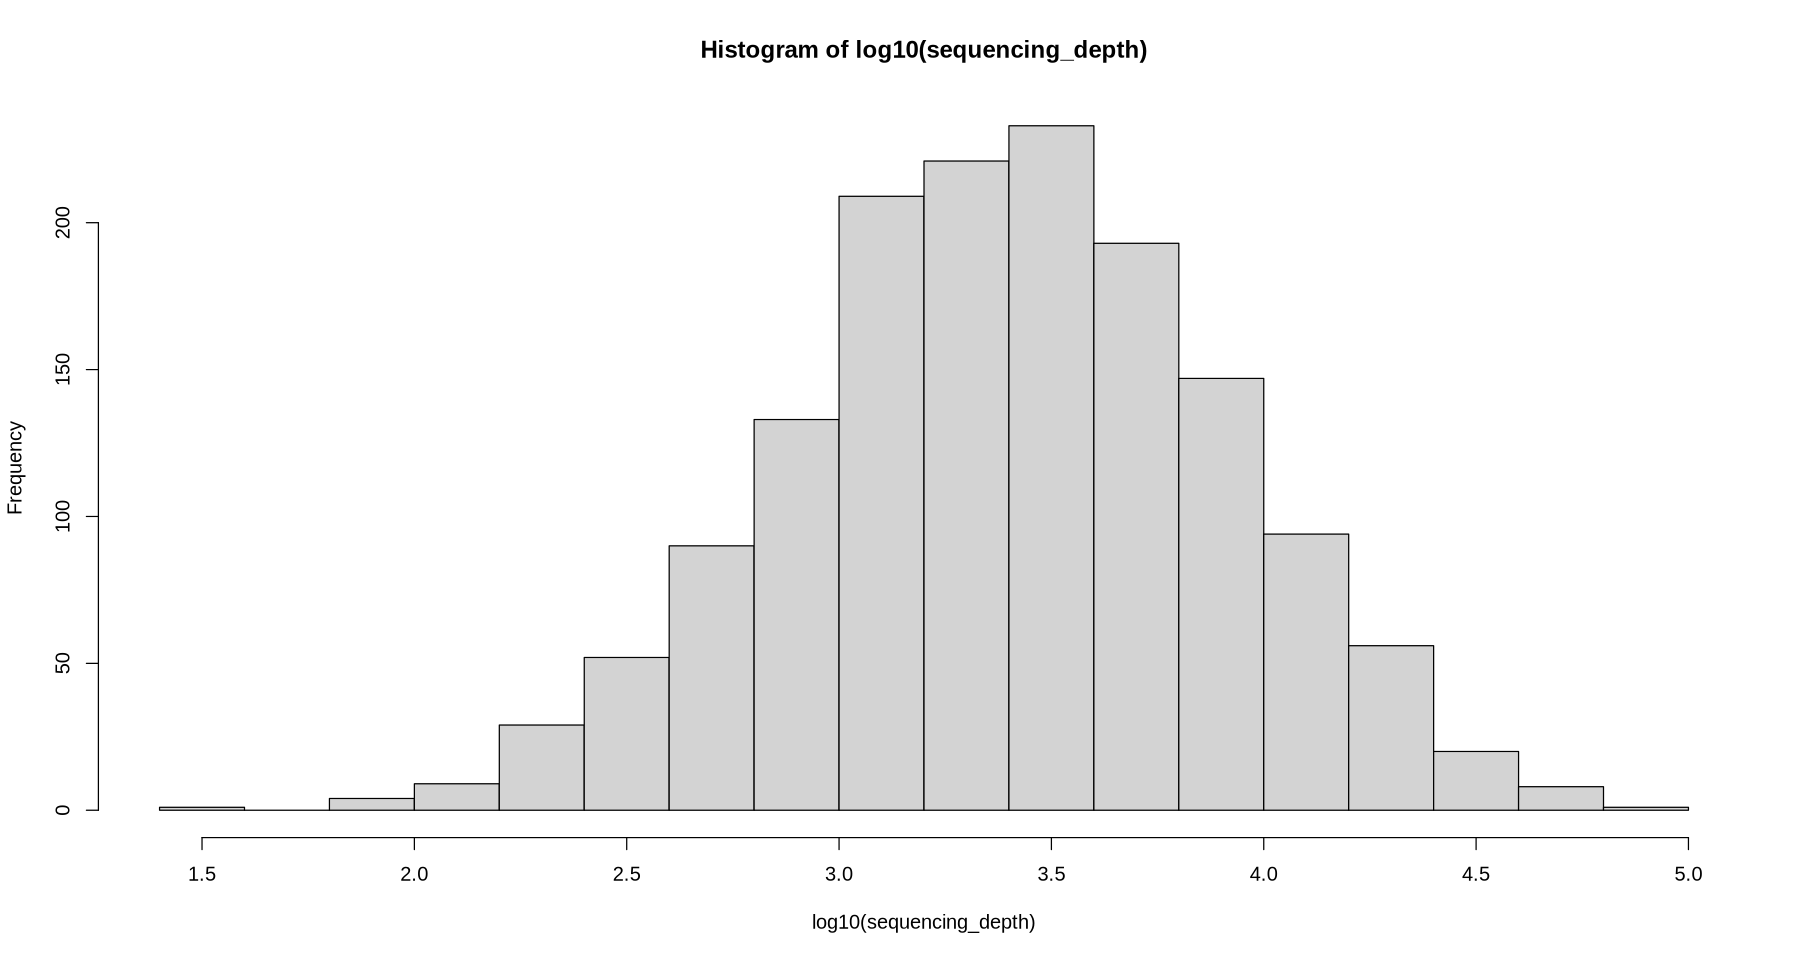

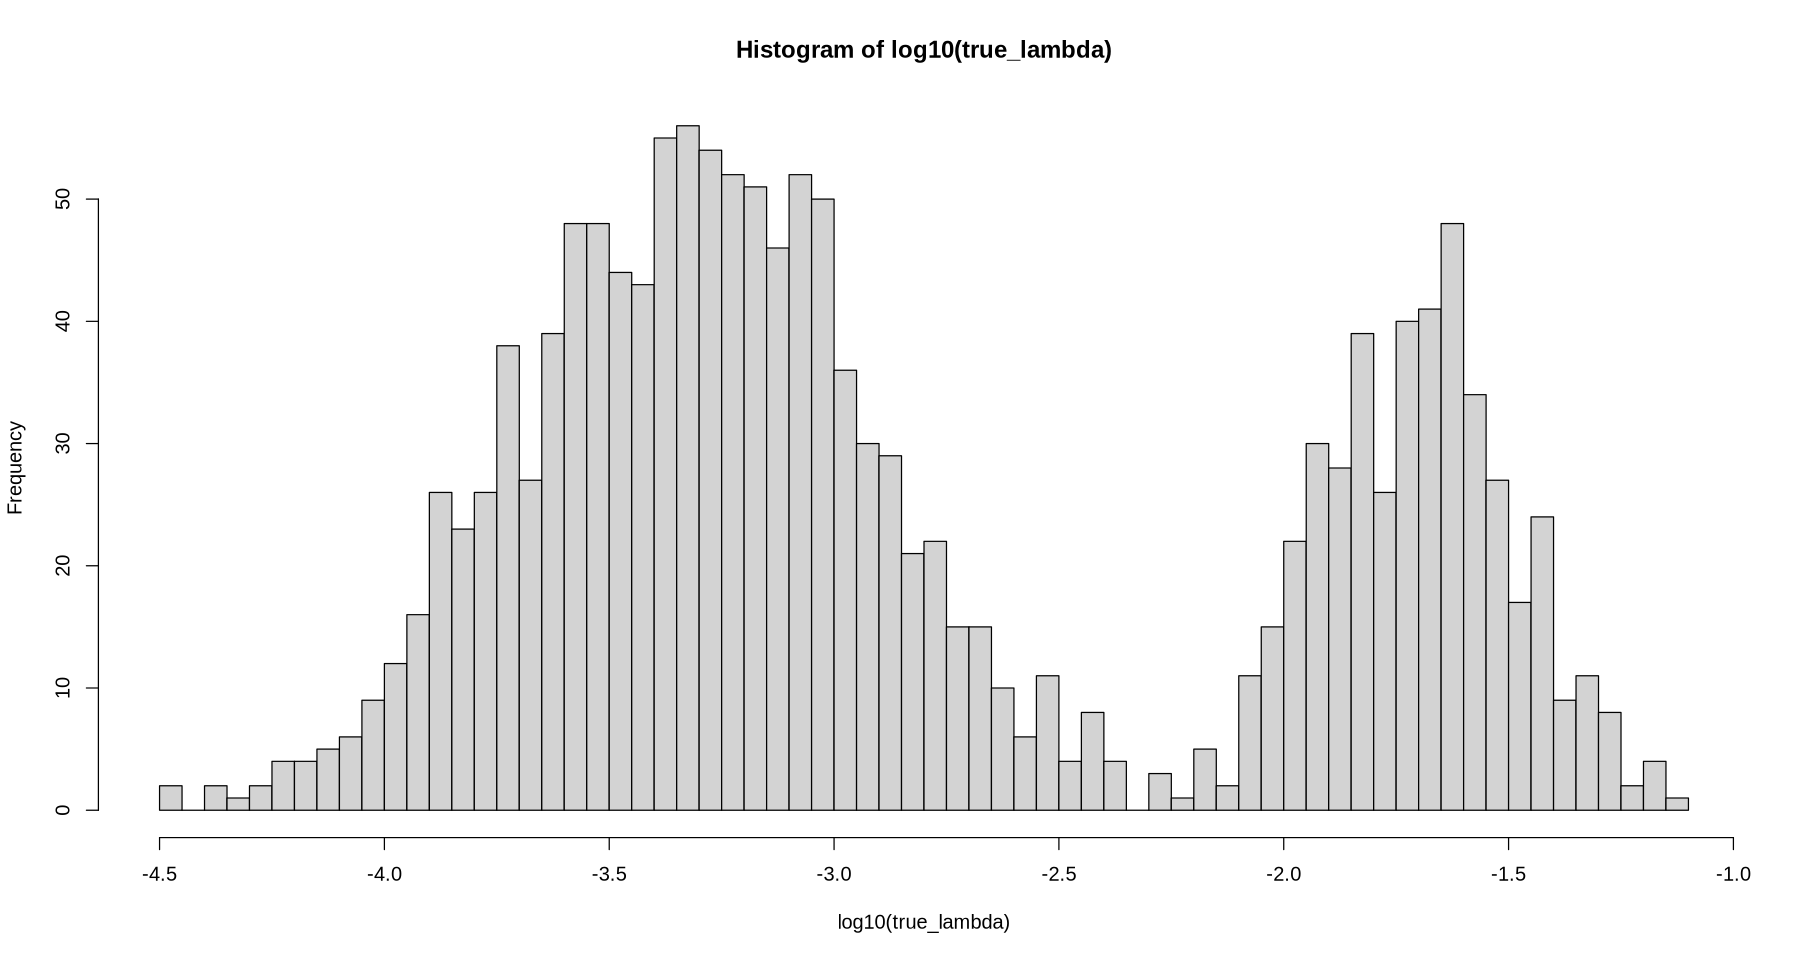

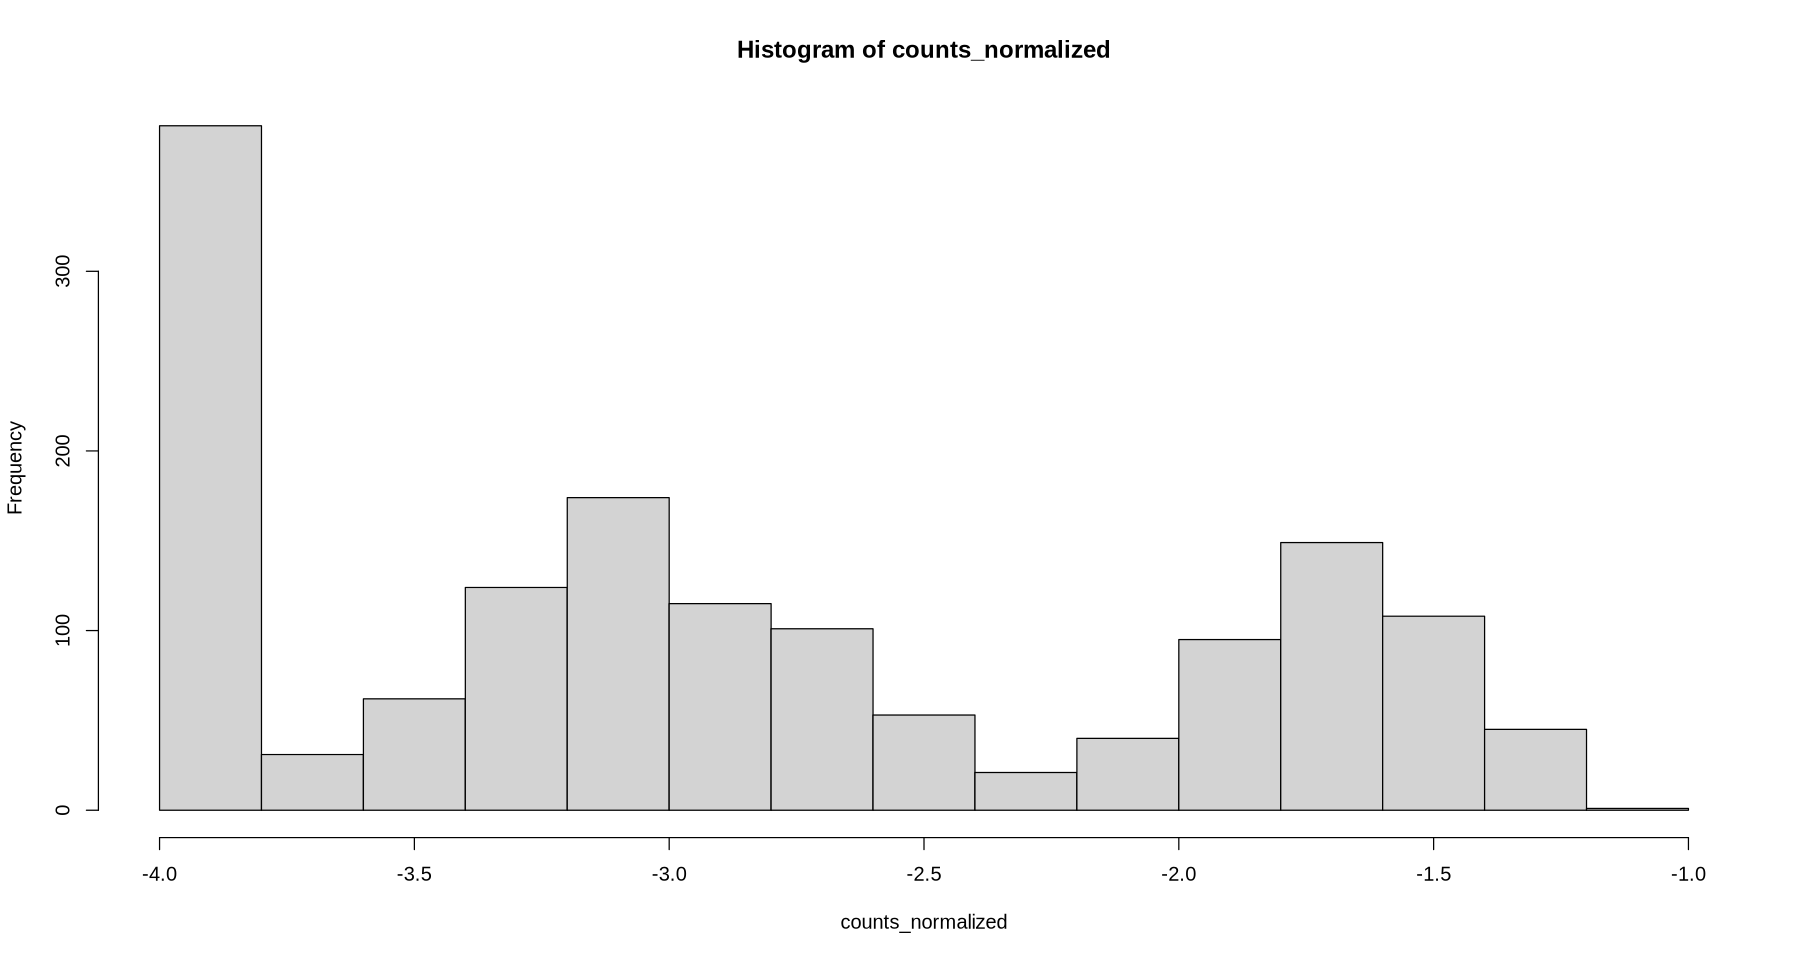

In [5]:
# Number of cells to simulate
n <- 1500

# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n, log10(mean_size), std_size))
hist(log10(sequencing_depth))

# Simulate the true expression rate for each cell
mean_rate <- -3.3 # corresponds to expression rate around 10^(-3.3) = 0.0005
std_rate <- 0.4
mean_rate_2 <- -1.7
std_rate_2 <- 0.2
true_lambda <- 10^ifelse(runif(n) < .7, rnorm(n, mean_rate, std_rate), rnorm(n, mean_rate_2, std_rate_2))
hist(log10(true_lambda), 100)

# Simulate the observed read counts per cell as a poisson process
# The expected count for each cell is proportional to the true expression rate and the sequencing depth
counts <- rpois(n, true_lambda * sequencing_depth)
# Normalize the expression counts per cell and log-transform them
counts_normalized <- log10(counts / sequencing_depth + 1e-4)
hist(counts_normalized)


### Negative binomial

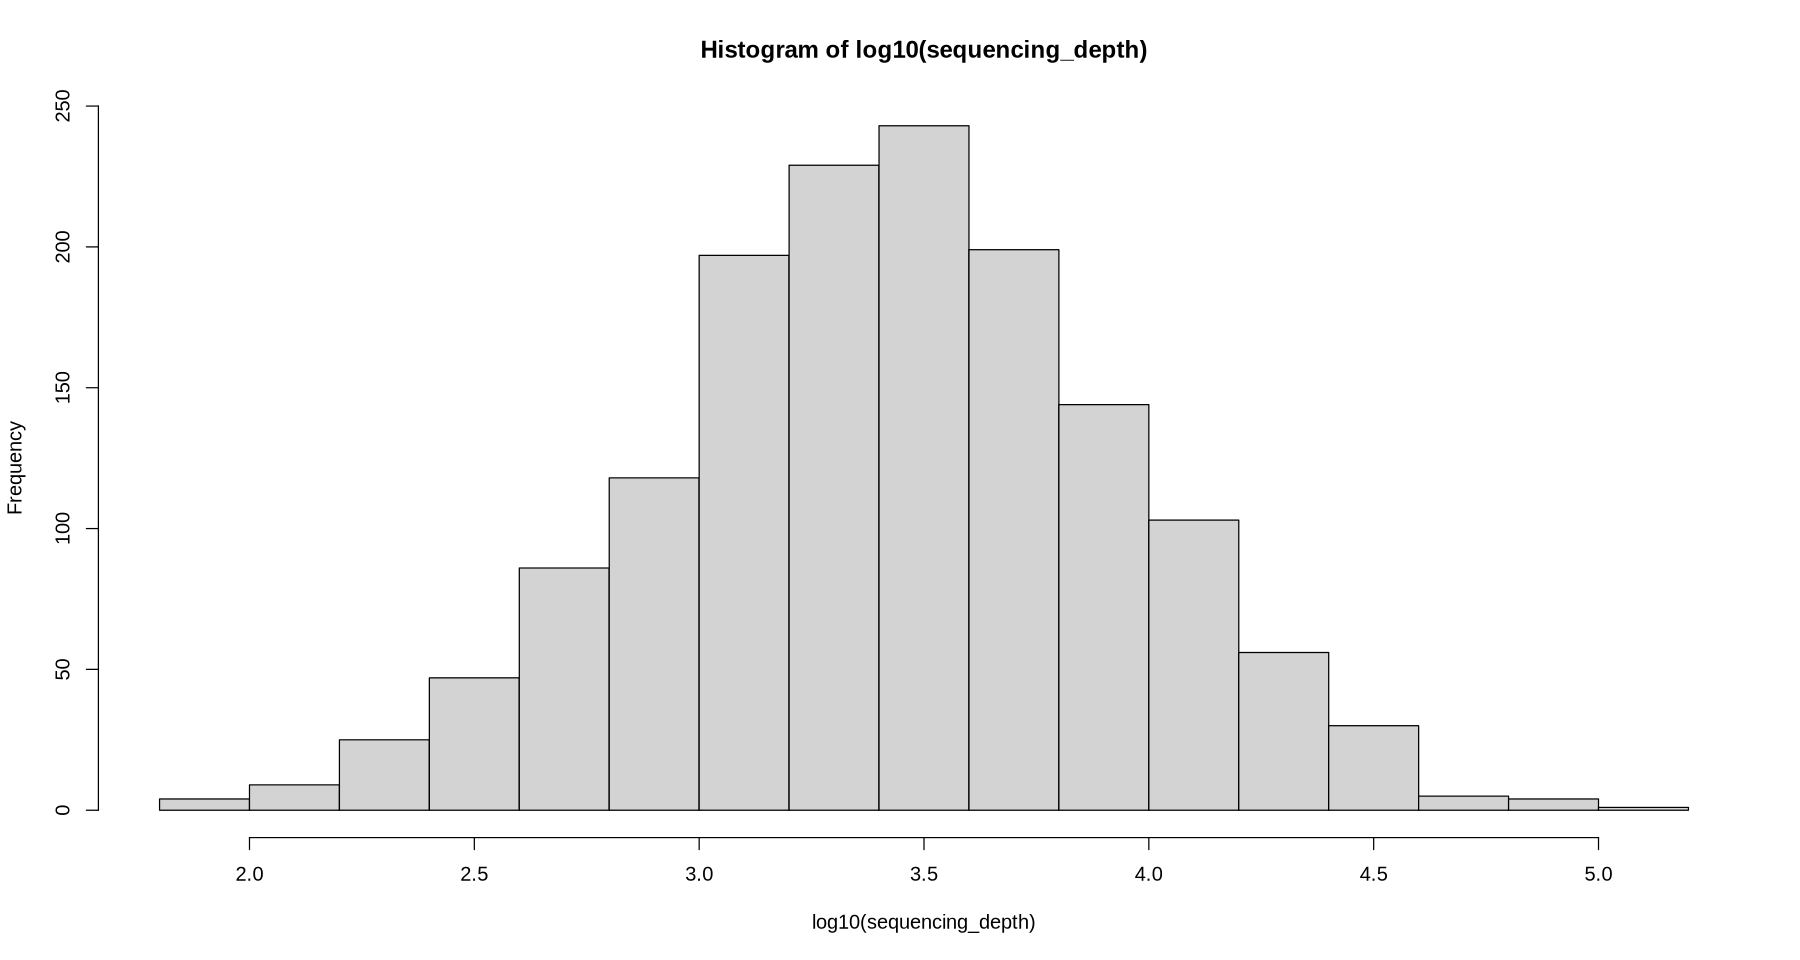

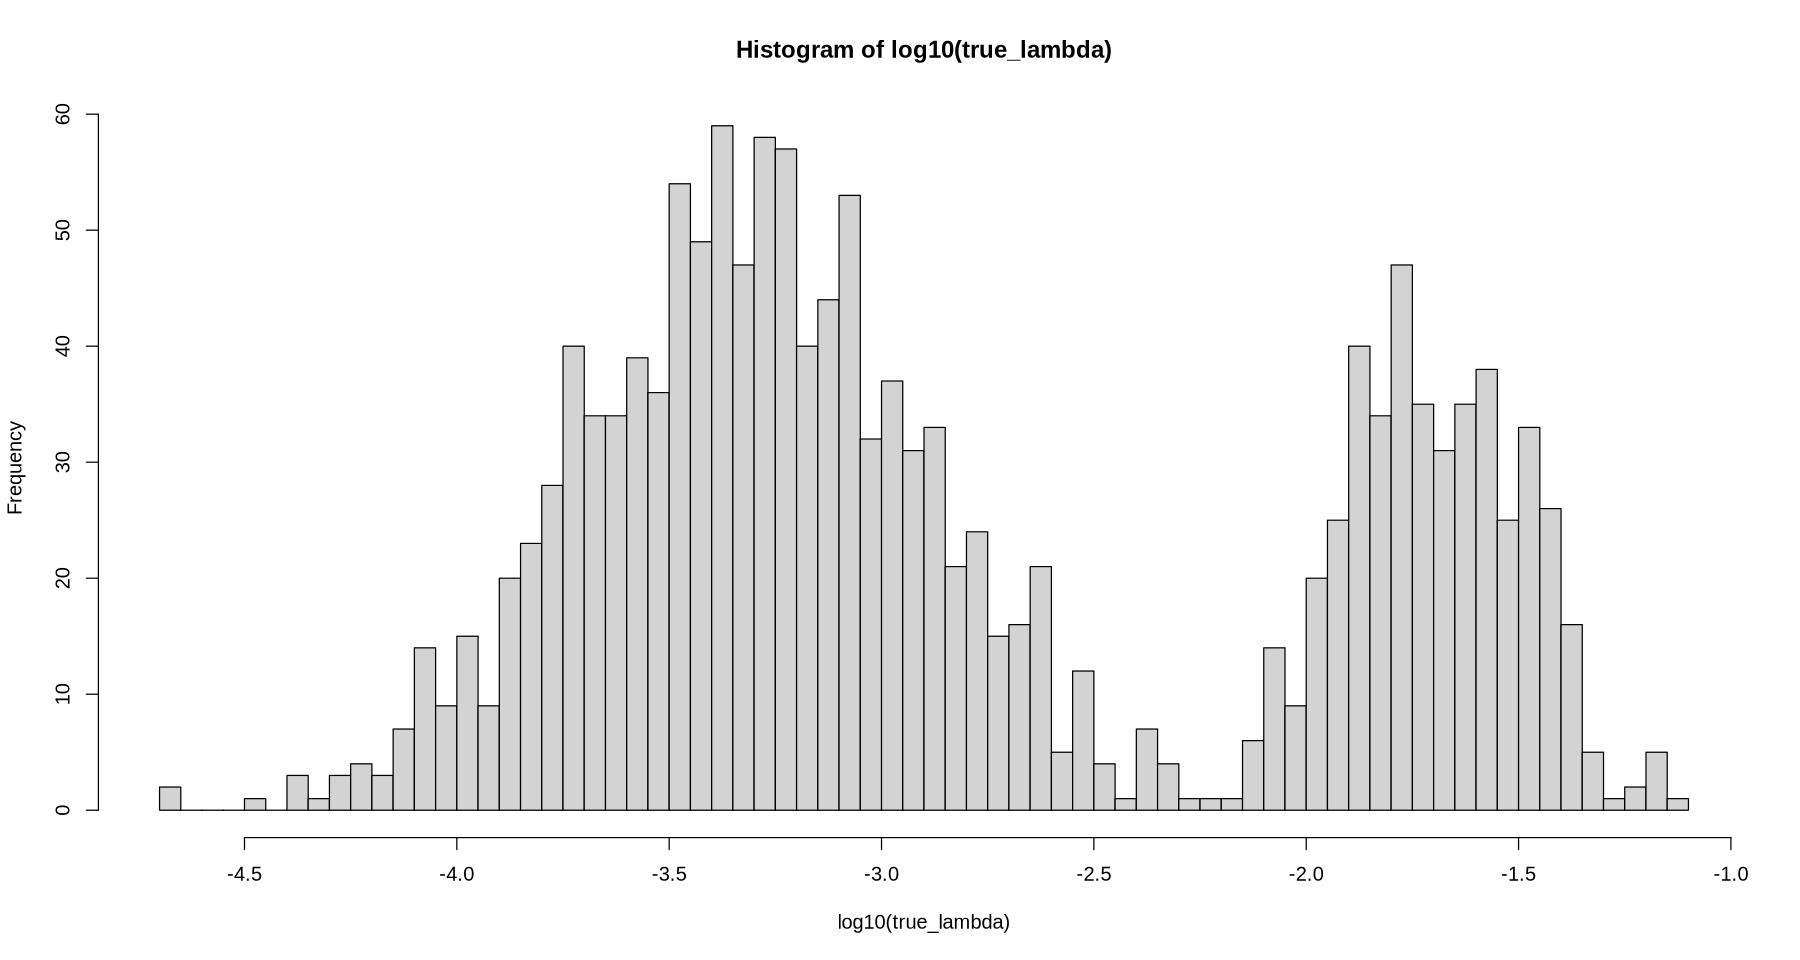

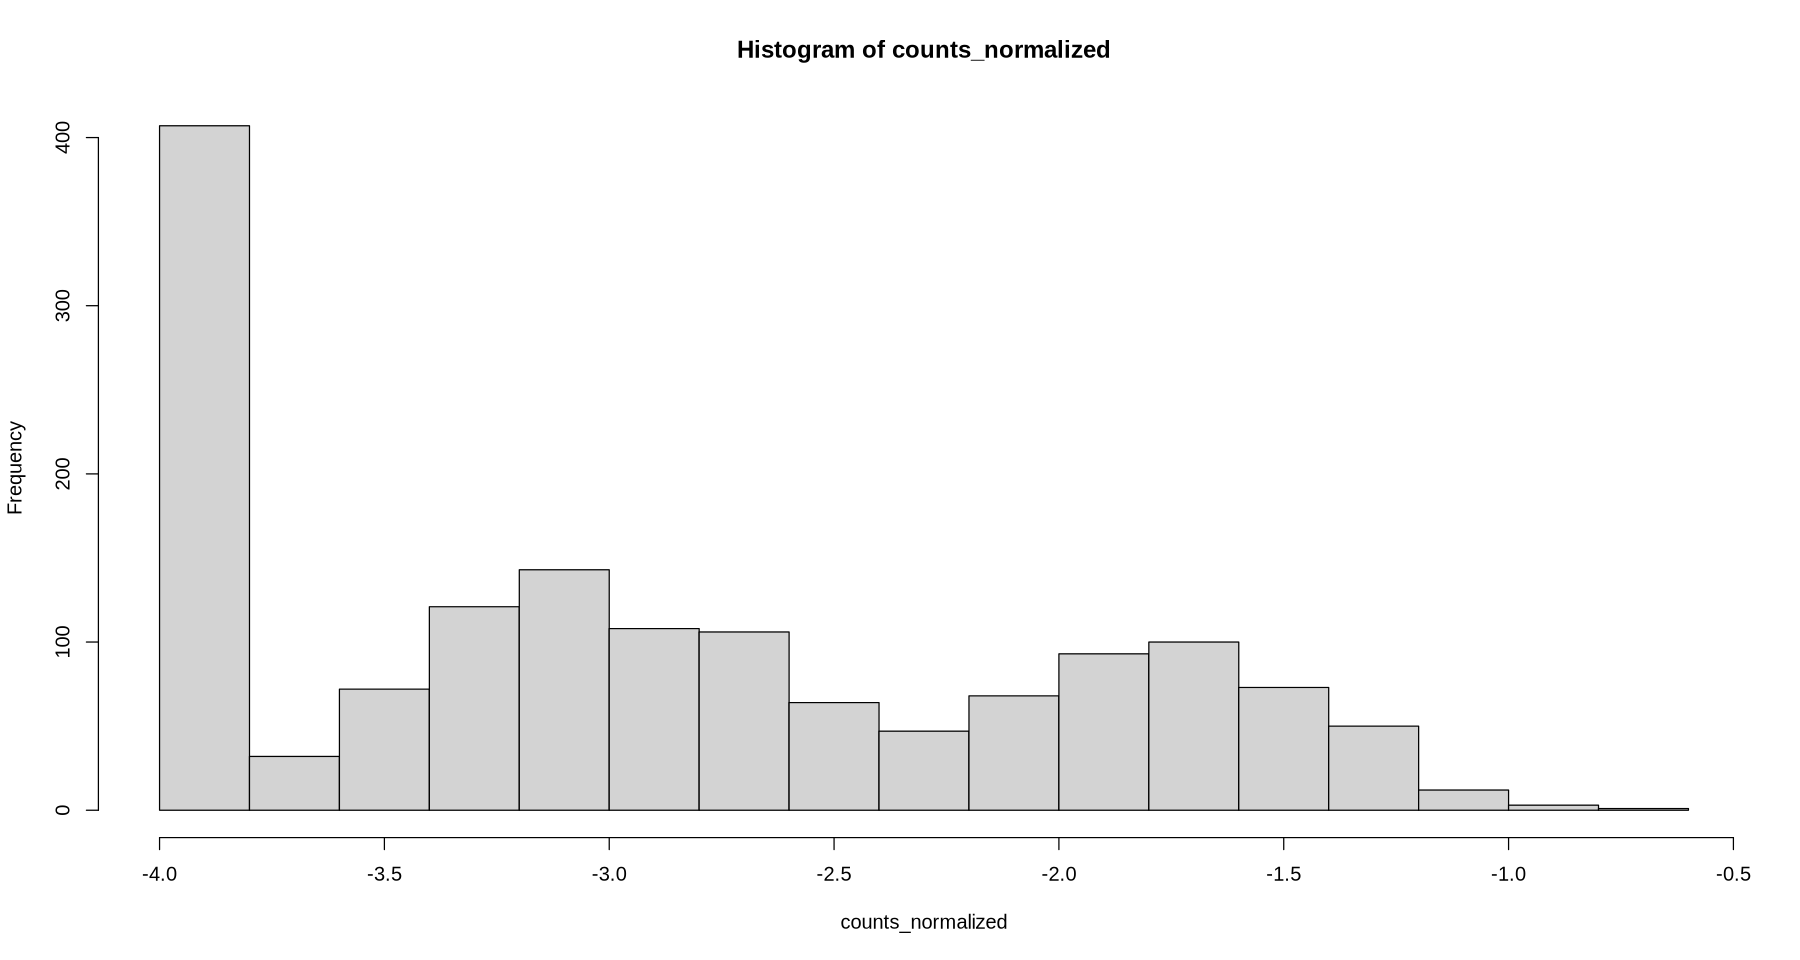

In [8]:
# Number of cells to simulate
n <- 1500

# Dispersion parameter
theta <- 3

# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n, log10(mean_size), std_size))
hist(log10(sequencing_depth))

# Simulate the true expression rate for each cell
mean_rate <- -3.3 # corresponds to expression rate around 10^(-3.3) = 0.0005
std_rate <- 0.4
mean_rate_2 <- -1.7
std_rate_2 <- 0.2
true_lambda <- 10^ifelse(runif(n) < .7, rnorm(n, mean_rate, std_rate), rnorm(n, mean_rate_2, std_rate_2))
hist(log10(true_lambda), 100)

# Simulate the observed read counts per cell as a poisson process
# The expected count for each cell is proportional to the true expression rate and the sequencing depth
counts <- rnbinom(n, size = theta, mu = true_lambda * sequencing_depth)
# Normalize the expression counts per cell and log-transform them
counts_normalized <- log10(counts / sequencing_depth + 1e-4)
hist(counts_normalized)


# Simulating multiple genes

## Estimate dispersion parameter

In [90]:
adata_raw <- adata$raw$to_adata()
adata_raw <- adata_raw[, rownames(adata$var)]
adata_raw


View of AnnData object with n_obs × n_vars = 8799 × 2500
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'cell_barcode', 'genotype', 'tissue', 'mouse', 'sample', 'hto_success', 'percent.mt', 'Sample', 'Genotype', 'Age', 'Region', 'HTO', 'batch', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'S_score', 'G2M_score', 'phase', 'age_global'
    var: 'gene_ids', 'feature_types', 'n_cells'
    uns: 'Age_colors', 'Genotype_colors', 'HTO_classification.global_colors', 'HTO_colors', 'Region_colors', 'Sample_colors', 'age_global_colors', 'batch_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'phase_colors', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

In [91]:
y <- adata_raw$X[, 1]
obs <- adata_raw$obs[, c("age_global", "batch", "Genotype")]
fit <- glm.nb(formula = y ~ age_global + batch + Genotype, data = obs)
fit$theta
fit$SE.theta


[1] 0.1141109

[1] 0.004406558

Warning message in glm.nb(formula = y ~ age_global + batch + Genotype, data = obs):
“alternation limit reached”
Warning message:
“glm.fit: fitted rates numerically 0 occurred”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message:
“glm.fit: algorithm did not converge”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in glm.nb(formula = y ~ age

[1] 500

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   0.000    0.008    0.065   20.526    0.245 4415.776 

[1] 0.20047189 0.16773706 0.42928397 0.09036761 0.15050576 0.28397966

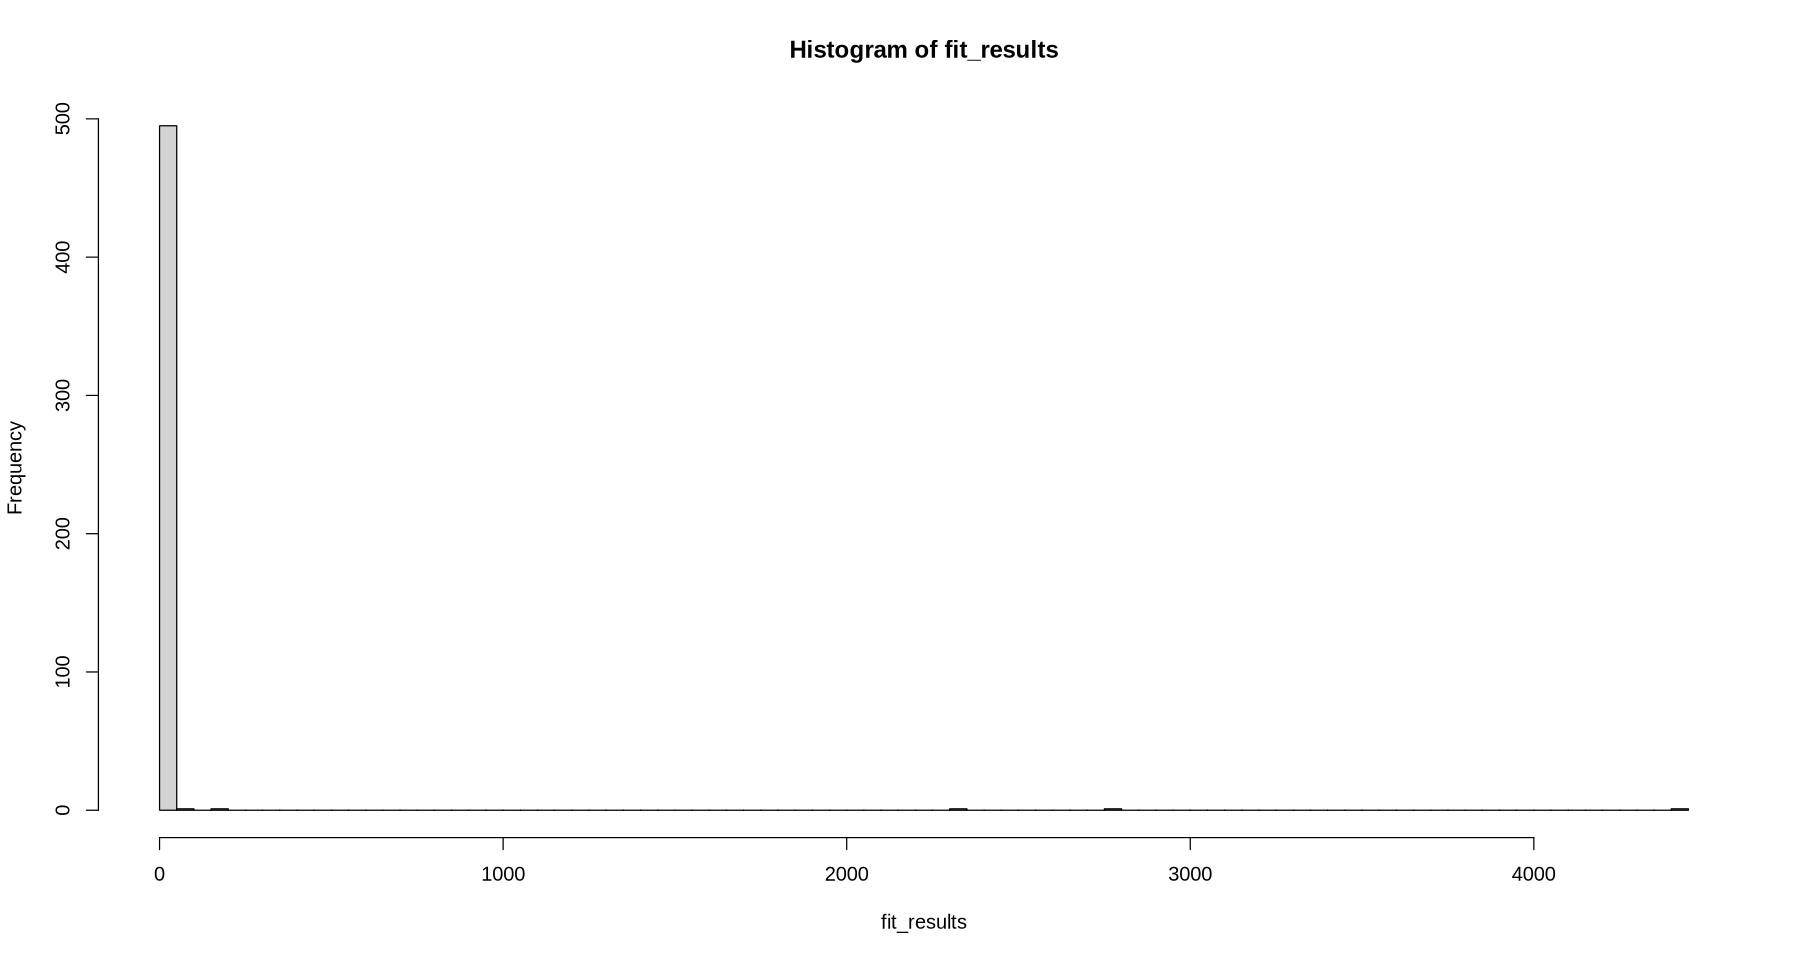

In [105]:
# THIS TAKES 3 MINUTES, DO NOT RUN AGAIN IF YOU DON'T NEED
# Randomly select 100 columns from adata_raw
selected_columns <- sample(1:ncol(adata_raw$X), 500)
data <- adata_raw[, selected_columns]

# Initialize an array to store the results
fit_results <- numeric(ncol(data$X))

# Loop through each gene and store the results in the array
fit_results <- pbsapply(1:ncol(data$X), function(i) {
    y <- data$X[, i]
    obs <- data$obs[, c("age_global", "batch", "Genotype")]
    fit <- glm.nb(formula = y ~ age_global + batch + Genotype, data = obs)
    return(fit$theta)
})

# The fit_results array now contains the glm.nb results for each column
length(fit_results)
summary(fit_results)
head(fit_results)
hist(fit_results, breaks = 100)


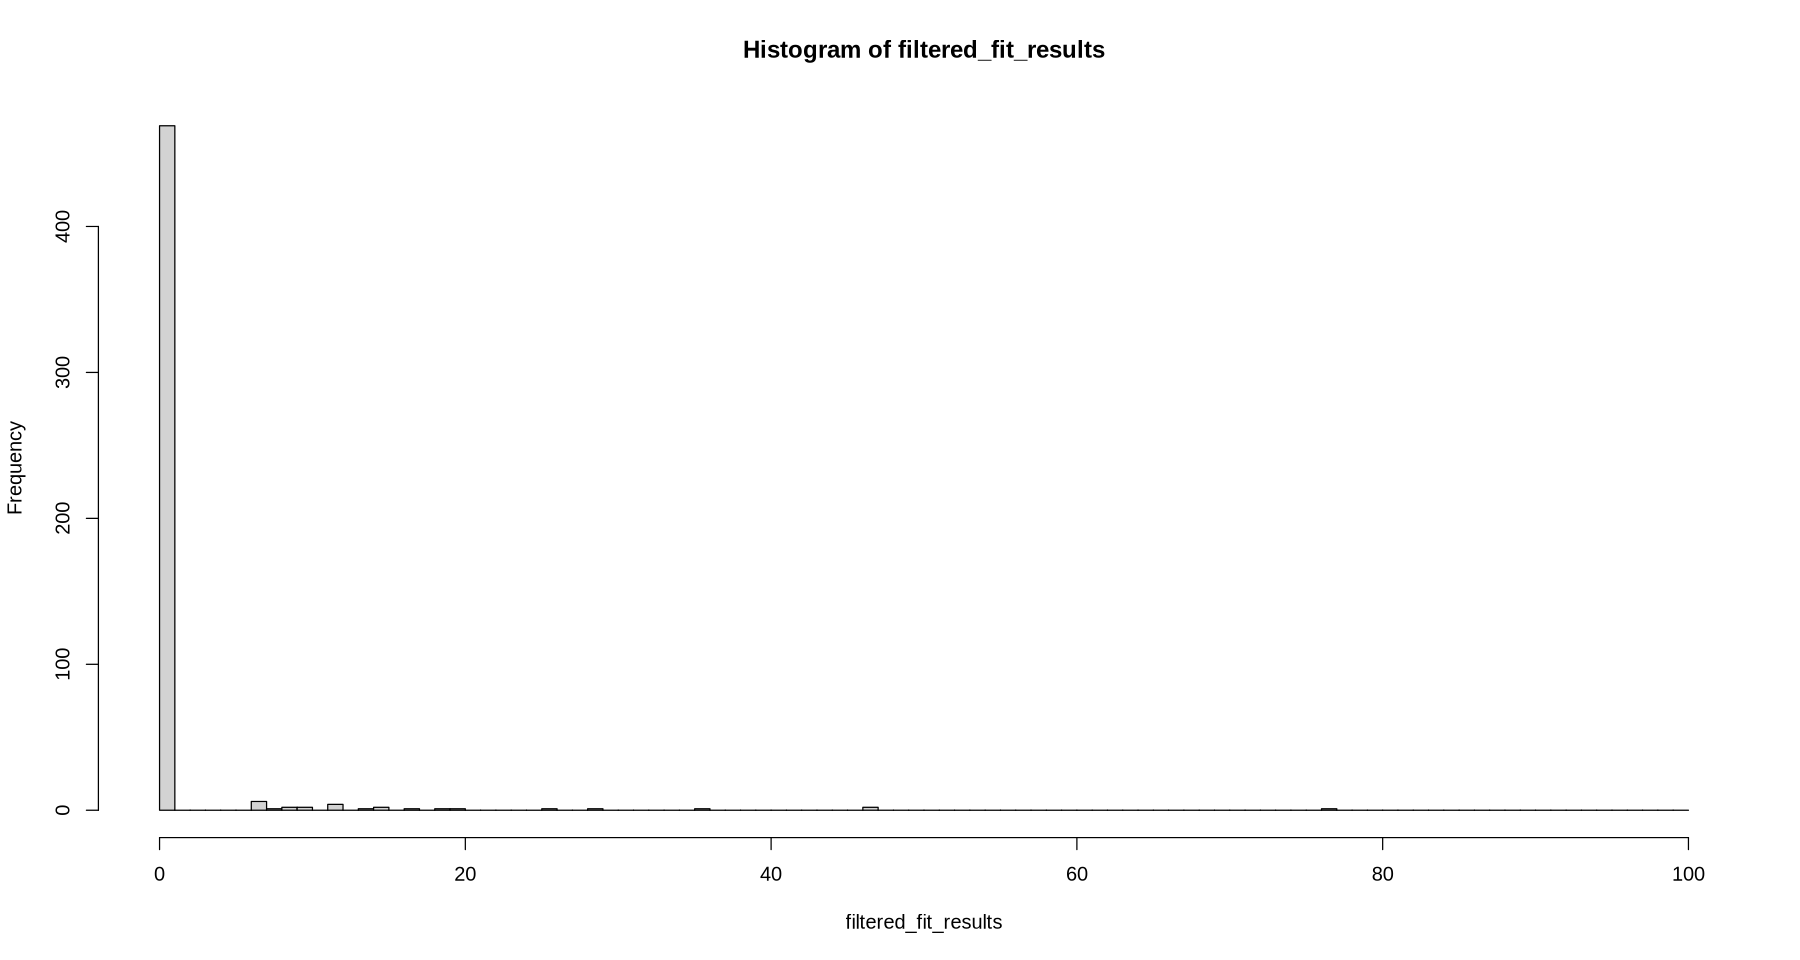

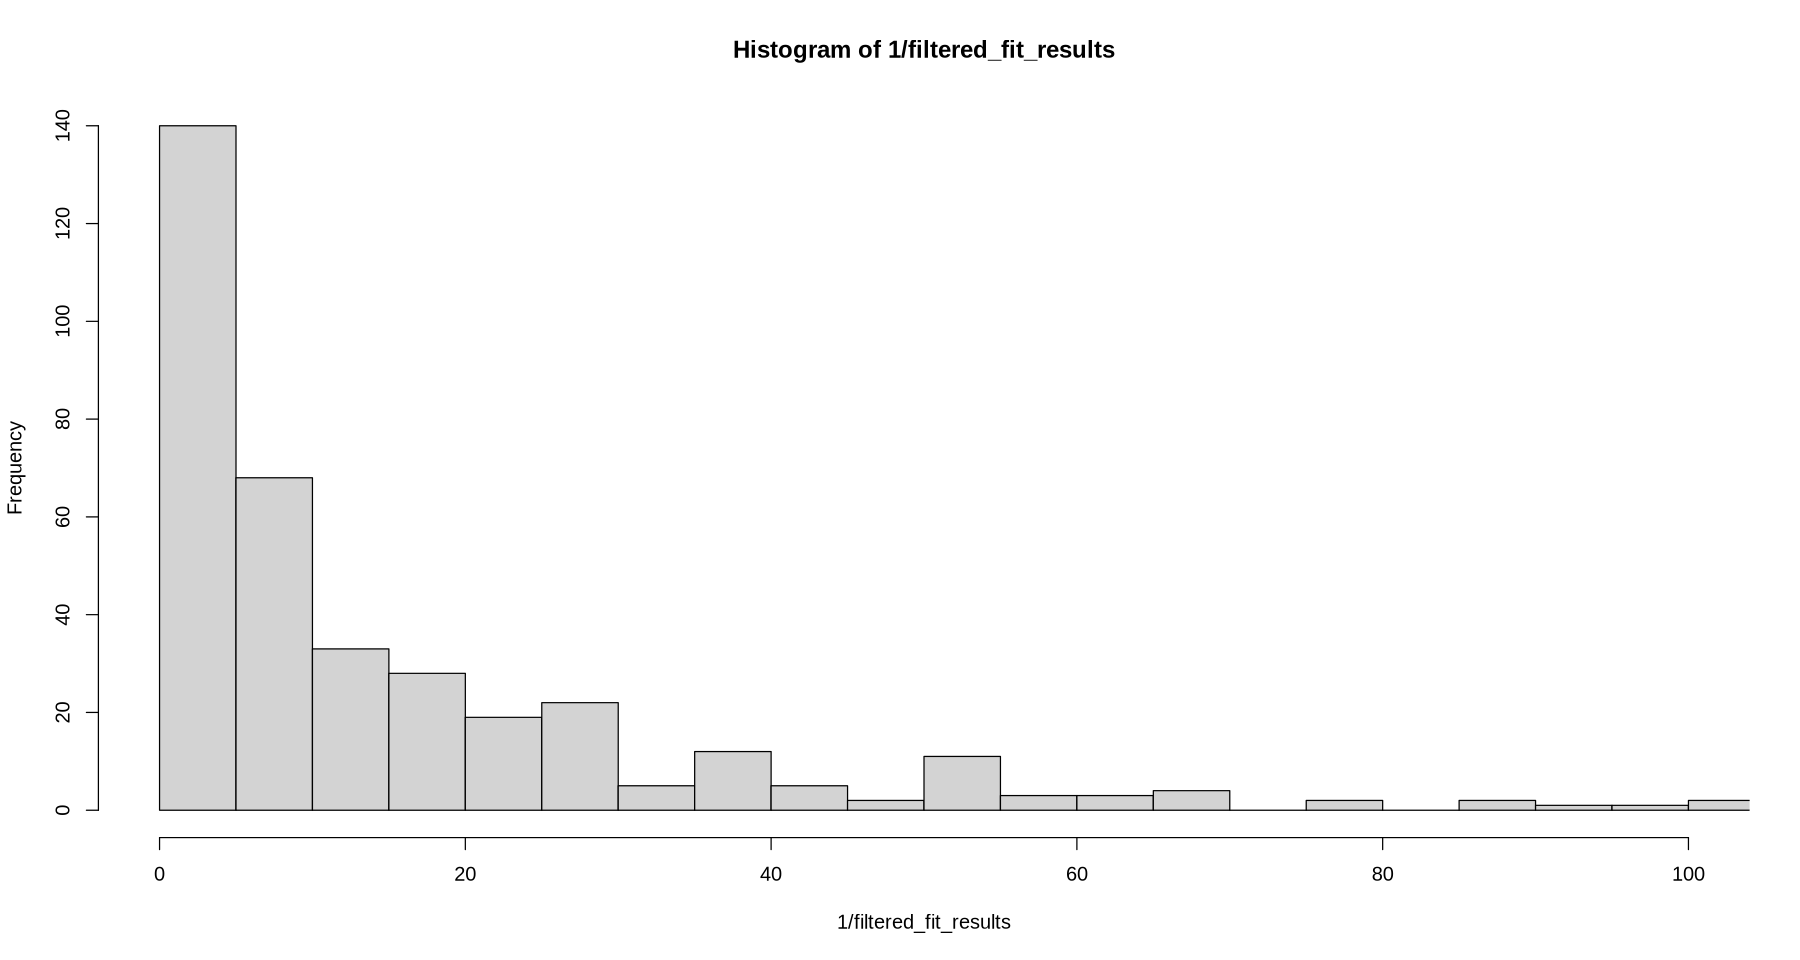

In [139]:
filtered_fit_results <- fit_results[!is.na(fit_results) & fit_results <= 100]
hist(filtered_fit_results, breaks = seq(0, 100, by = 1))
hist(1 / filtered_fit_results, breaks = seq(0, ceiling(max(1 / filtered_fit_results) / 5) * 5, by = 5), xlim = c(0, 100))


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
    0.02     2.46    12.93   426.40    98.40 33432.23 

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
     0.01      4.16     15.75    535.62    128.28 126840.98 

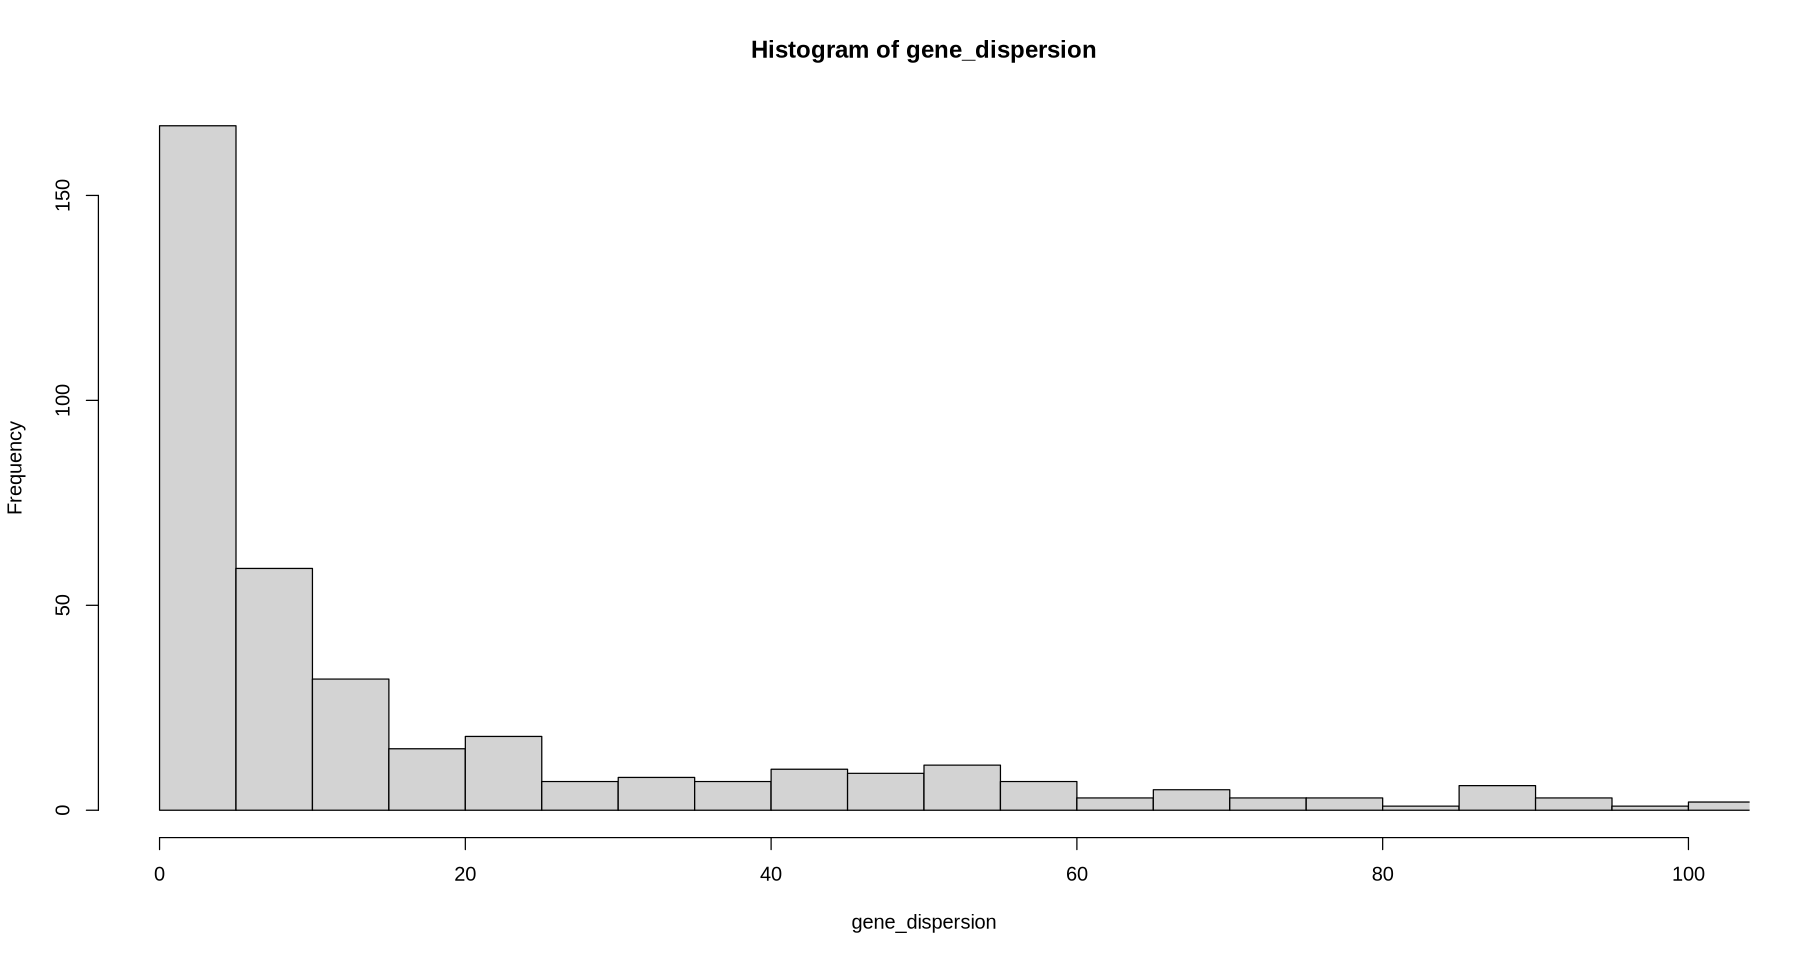

In [268]:
# Simulate a similar distribution
gene_dispersion <- 10^rnorm(500, 1.2, 1.15) # Different dispersions per gene
hist(gene_dispersion, breaks = seq(0, ceiling(max(gene_dispersion) / 5) * 5, by = 5), xlim = c(0, 100))
summary(gene_dispersion)
summary(1 / filtered_fit_results)


     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
  0.00013   0.01022   0.05811   1.77819   0.30249 307.09923 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
 0.00001  0.00780  0.06348  1.10925  0.24018 76.29236 

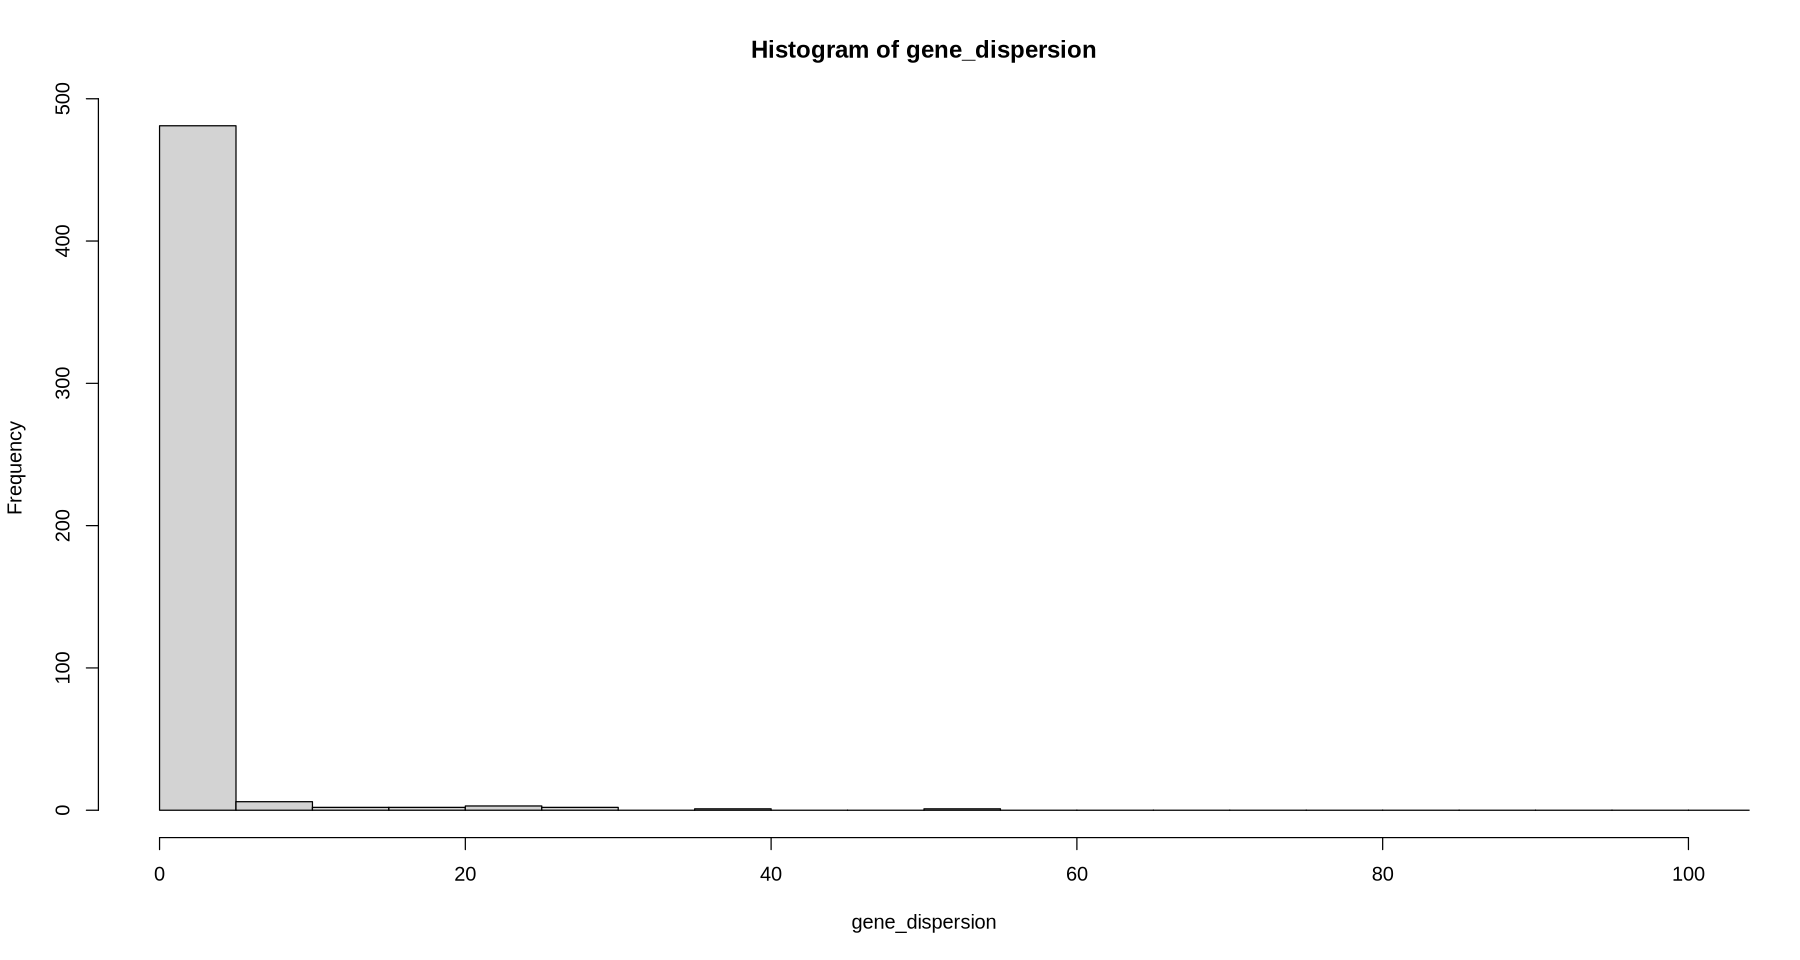

In [267]:
# Simulate a similar distribution
gene_dispersion <- 1 / (10^rnorm(500, 1.2, 1.15)) # Different dispersions per gene
hist(gene_dispersion, breaks = seq(0, ceiling(max(gene_dispersion) / 5) * 5, by = 5), xlim = c(0, 100))
summary(gene_dispersion)
summary(filtered_fit_results)


In [269]:
# Fit a log-normal distribution to the sample "fit_results"
lognorm_fit <- fitdistr(filtered_fit_results, densfun = "lognormal")

# Extract the estimated parameters
meanlog <- lognorm_fit$estimate["meanlog"]
sdlog <- lognorm_fit$estimate["sdlog"]

# Print the estimated parameters
cat("Estimated meanlog:", meanlog, "\n")
cat("Estimated sdlog:", sdlog, "\n")


Estimated meanlog: -3.012836 
Estimated sdlog: 2.468317 


     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.000e+00 2.300e+01 1.324e+03 6.434e+07 8.103e+04 1.259e+10 

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
     0.00      4.09     15.37    531.34    126.51 126840.98 

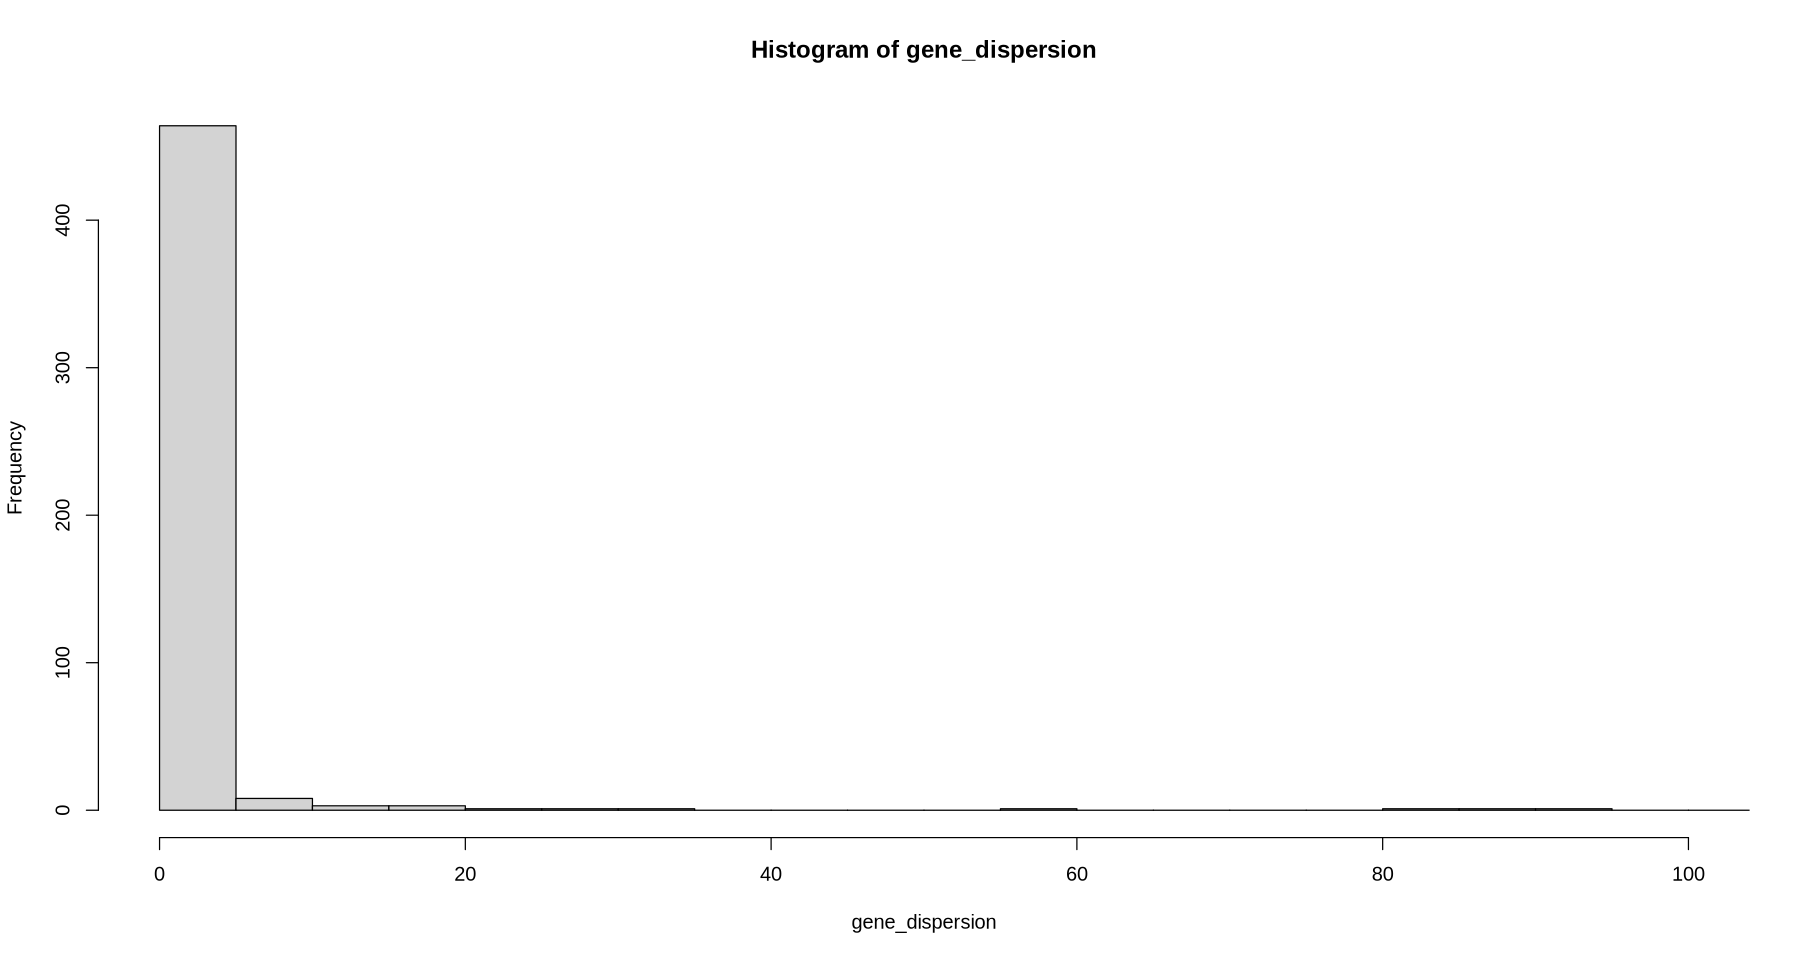

In [280]:
# Simulate a similar distribution
gene_dispersion <- 10^rnorm(500, -3, 2.5) # Different dispersions per gene
hist(gene_dispersion, breaks = seq(0, ceiling(max(gene_dispersion) / 5) * 5, by = 5), xlim = c(0, 100))
summary(1 / gene_dispersion)
summary(1 / fit_results)


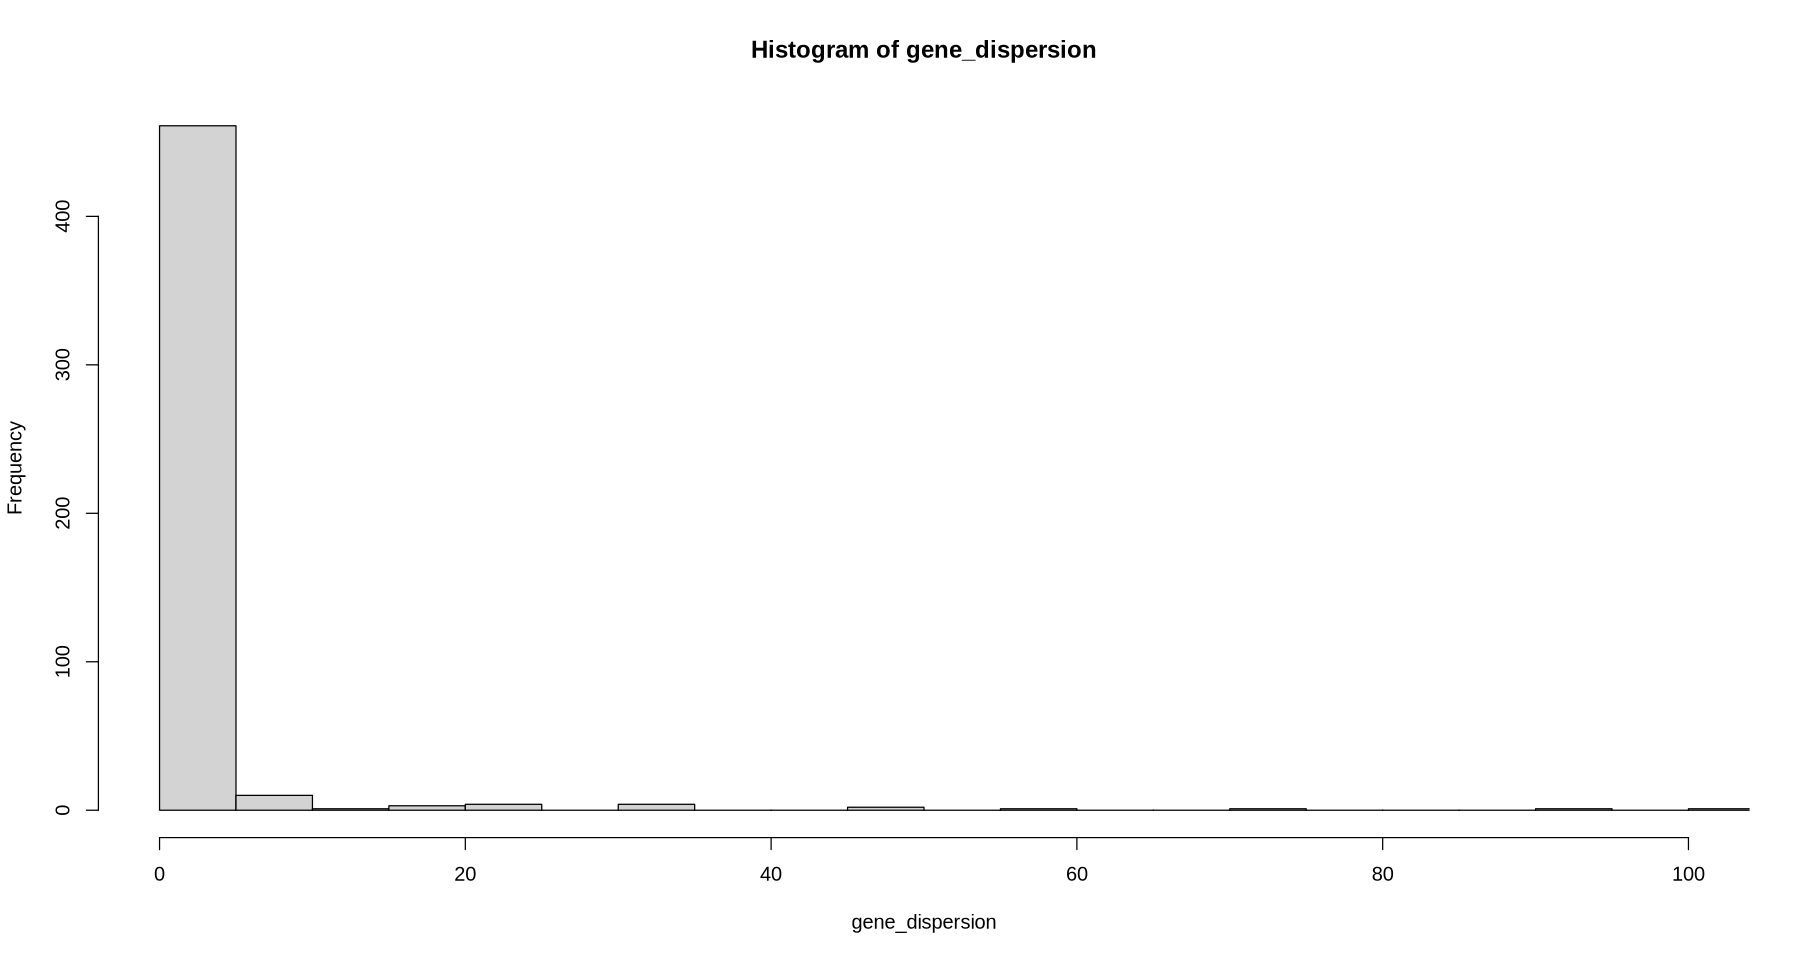

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
    0.000     0.000     0.001   102.809     0.054 25873.283 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   0.000    0.008    0.065   20.526    0.245 4415.776 

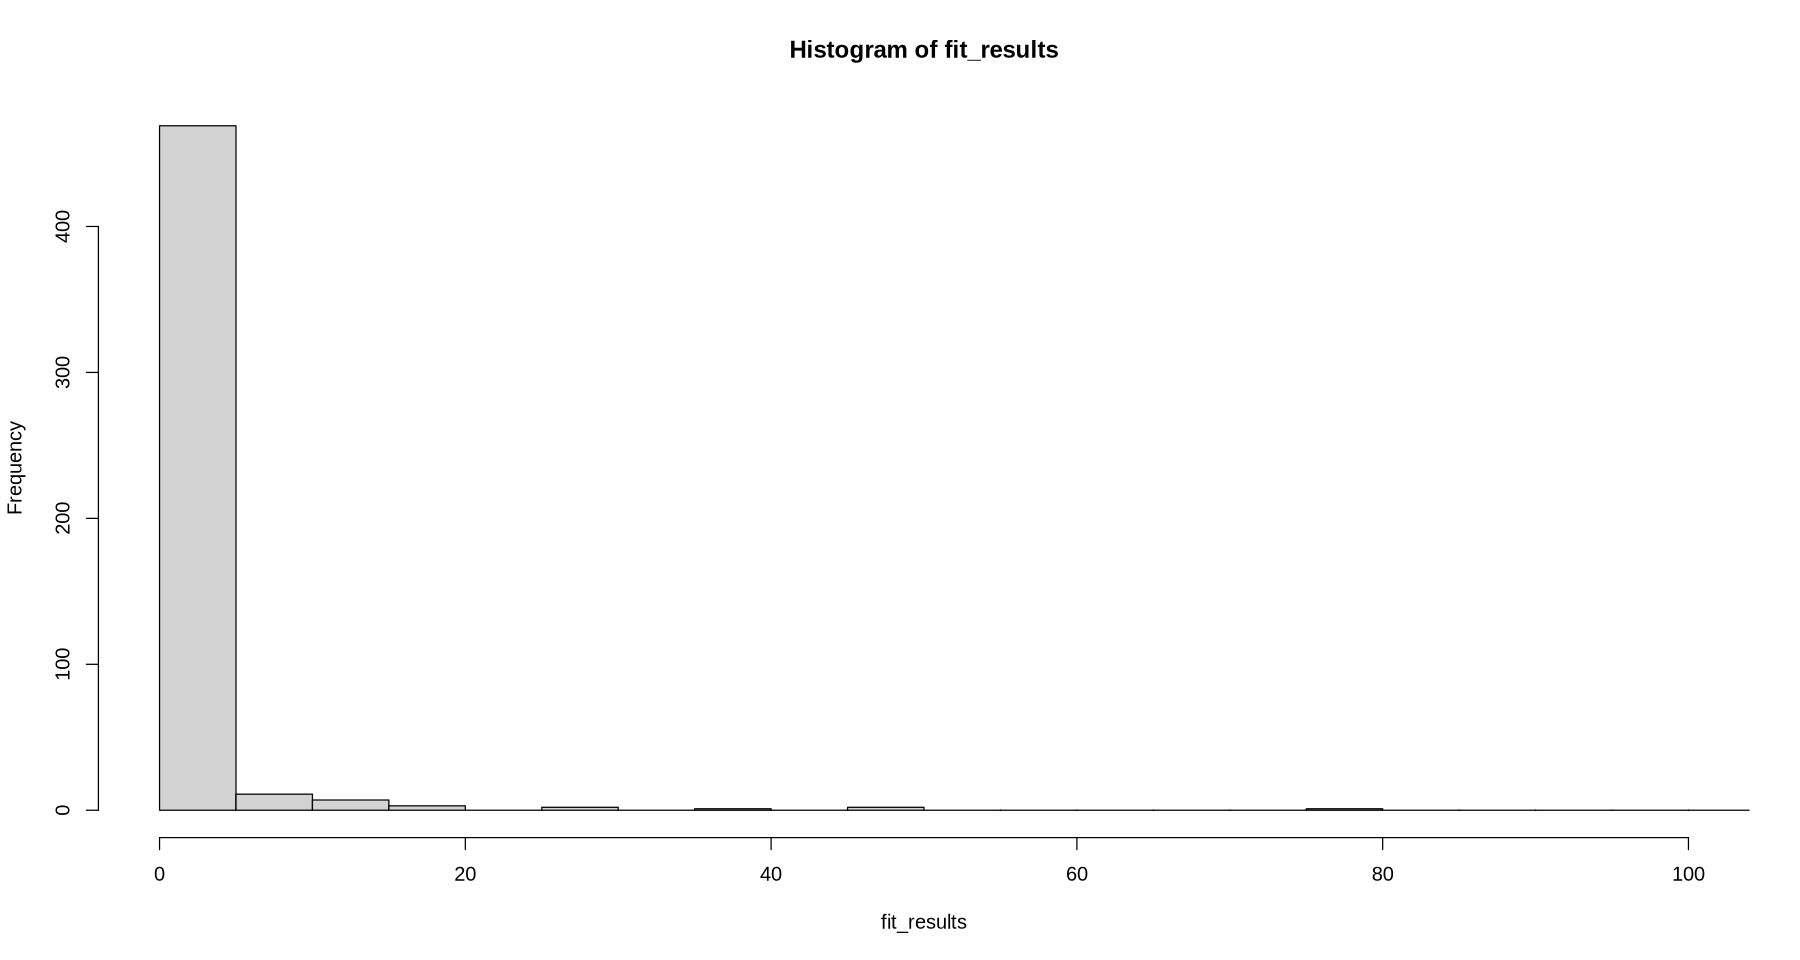

In [292]:
# Simulate a similar distribution
gene_dispersion <- 10^rnorm(500, -3, 2.5) # Different dispersions per gene
hist(gene_dispersion, breaks = seq(0, ceiling(max(gene_dispersion) / 5) * 5, by = 5), xlim = c(0, 100))
hist(fit_results, breaks = seq(0, ceiling(max(fit_results) / 5) * 5, by = 5), xlim = c(0, 100))
summary(gene_dispersion)
summary(fit_results)


In [281]:
# Fit a gamma distribution to the sample "fit_results"
gamma_fit <- fitdistr(filtered_fit_results, densfun = "gamma")

# Extract the estimated parameters
shape <- gamma_fit$estimate["shape"]
rate <- gamma_fit$estimate["rate"]

# Print the estimated parameters
cat("Estimated shape:", shape, "\n")
cat("Estimated rate:", rate, "\n")


Warning message in densfun(x, parm[1], parm[2], ...):
“NaNs produced”


Estimated shape: 0.2308617 
Estimated rate: 0.2081828 


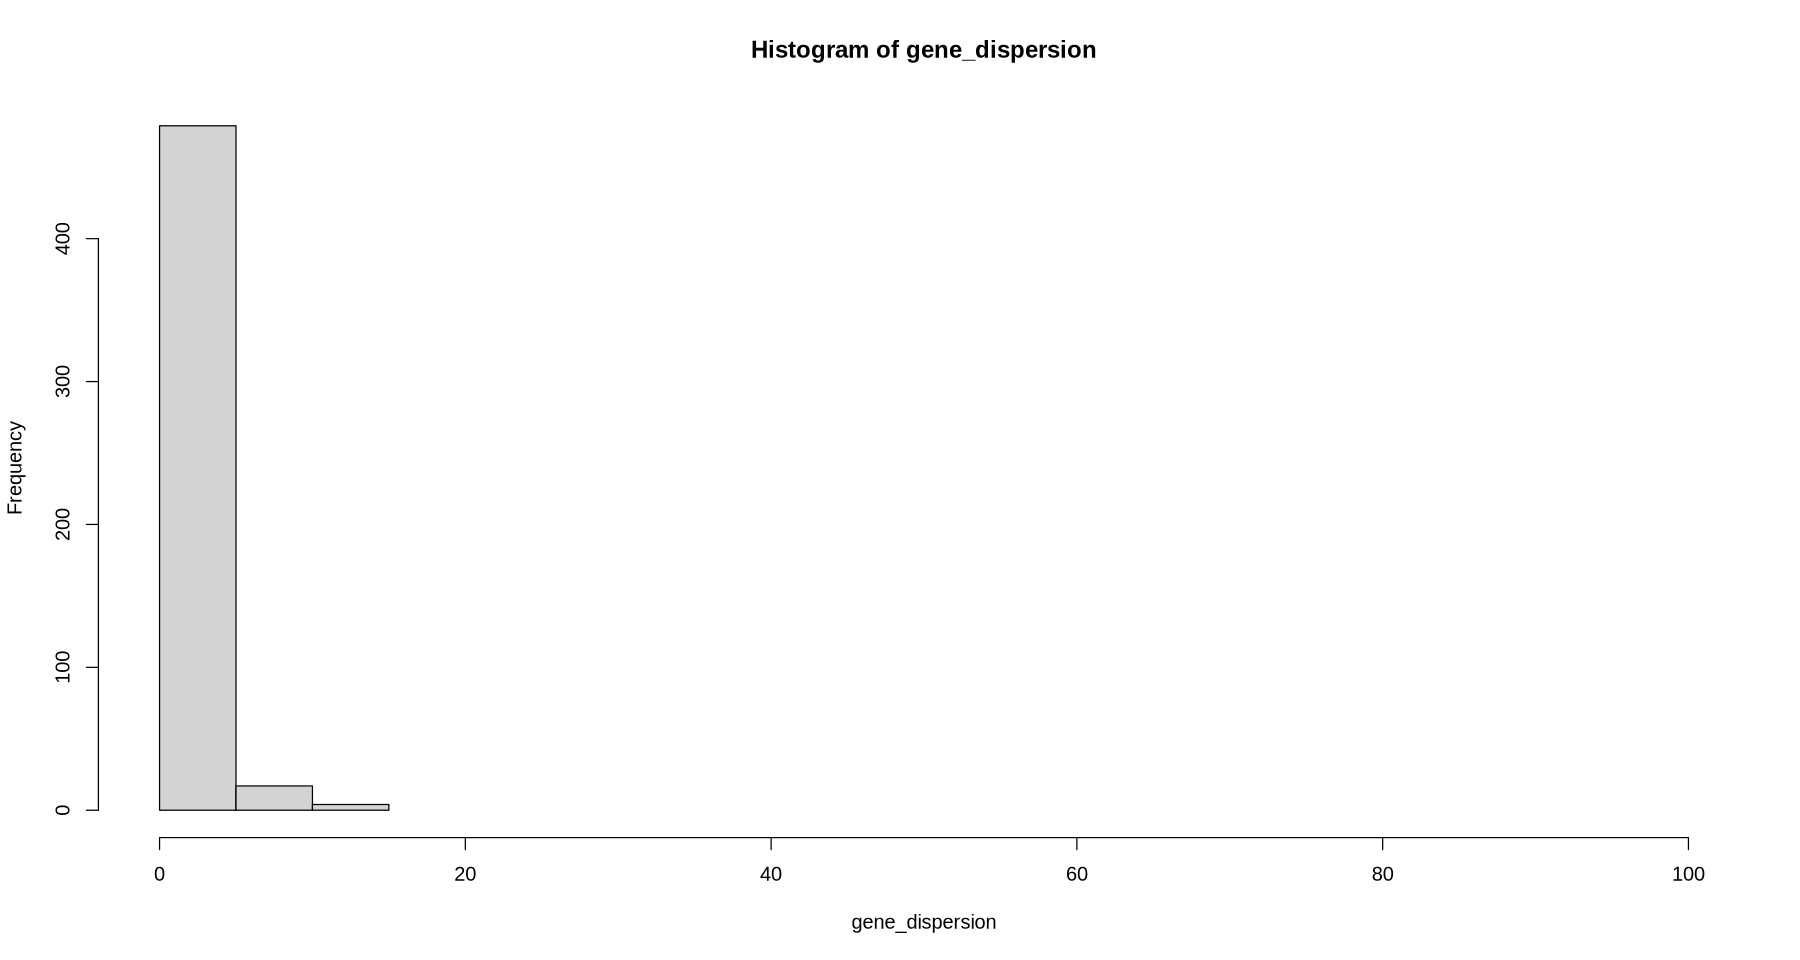

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
 0.000000  0.005919  0.142057  0.950147  0.859651 14.940977 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   0.000    0.008    0.065   20.526    0.245 4415.776 

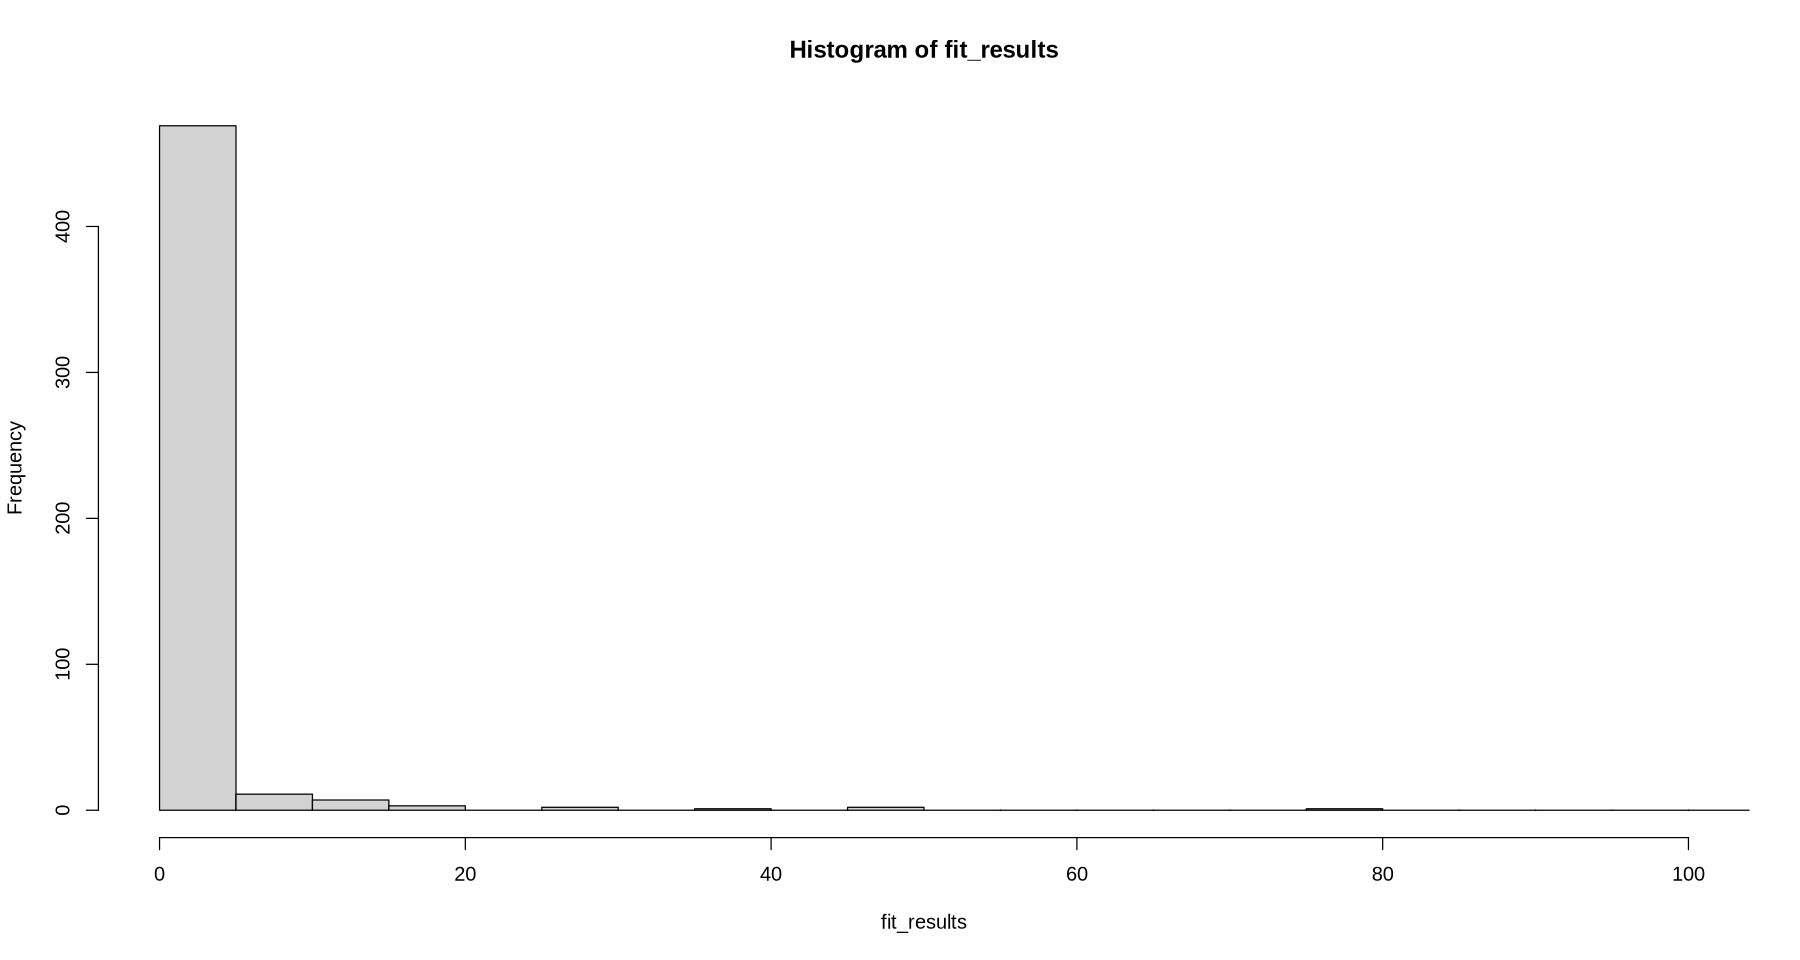

In [293]:
# Simulate a similar distribution
gene_dispersion <- rgamma(500, shape = 0.23, rate = 0.21) # Different dispersions per gene
hist(gene_dispersion, breaks = seq(0, ceiling(max(gene_dispersion) / 5) * 5, by = 5), xlim = c(0, 100))
hist(fit_results, breaks = seq(0, ceiling(max(fit_results) / 5) * 5, by = 5), xlim = c(0, 100))
summary(gene_dispersion)
summary(fit_results)


- The first approach led to the best results

## Estimate gene mean expression

NULL

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
 0.00023  0.00977  0.16684  1.07463  0.69747 54.50267 

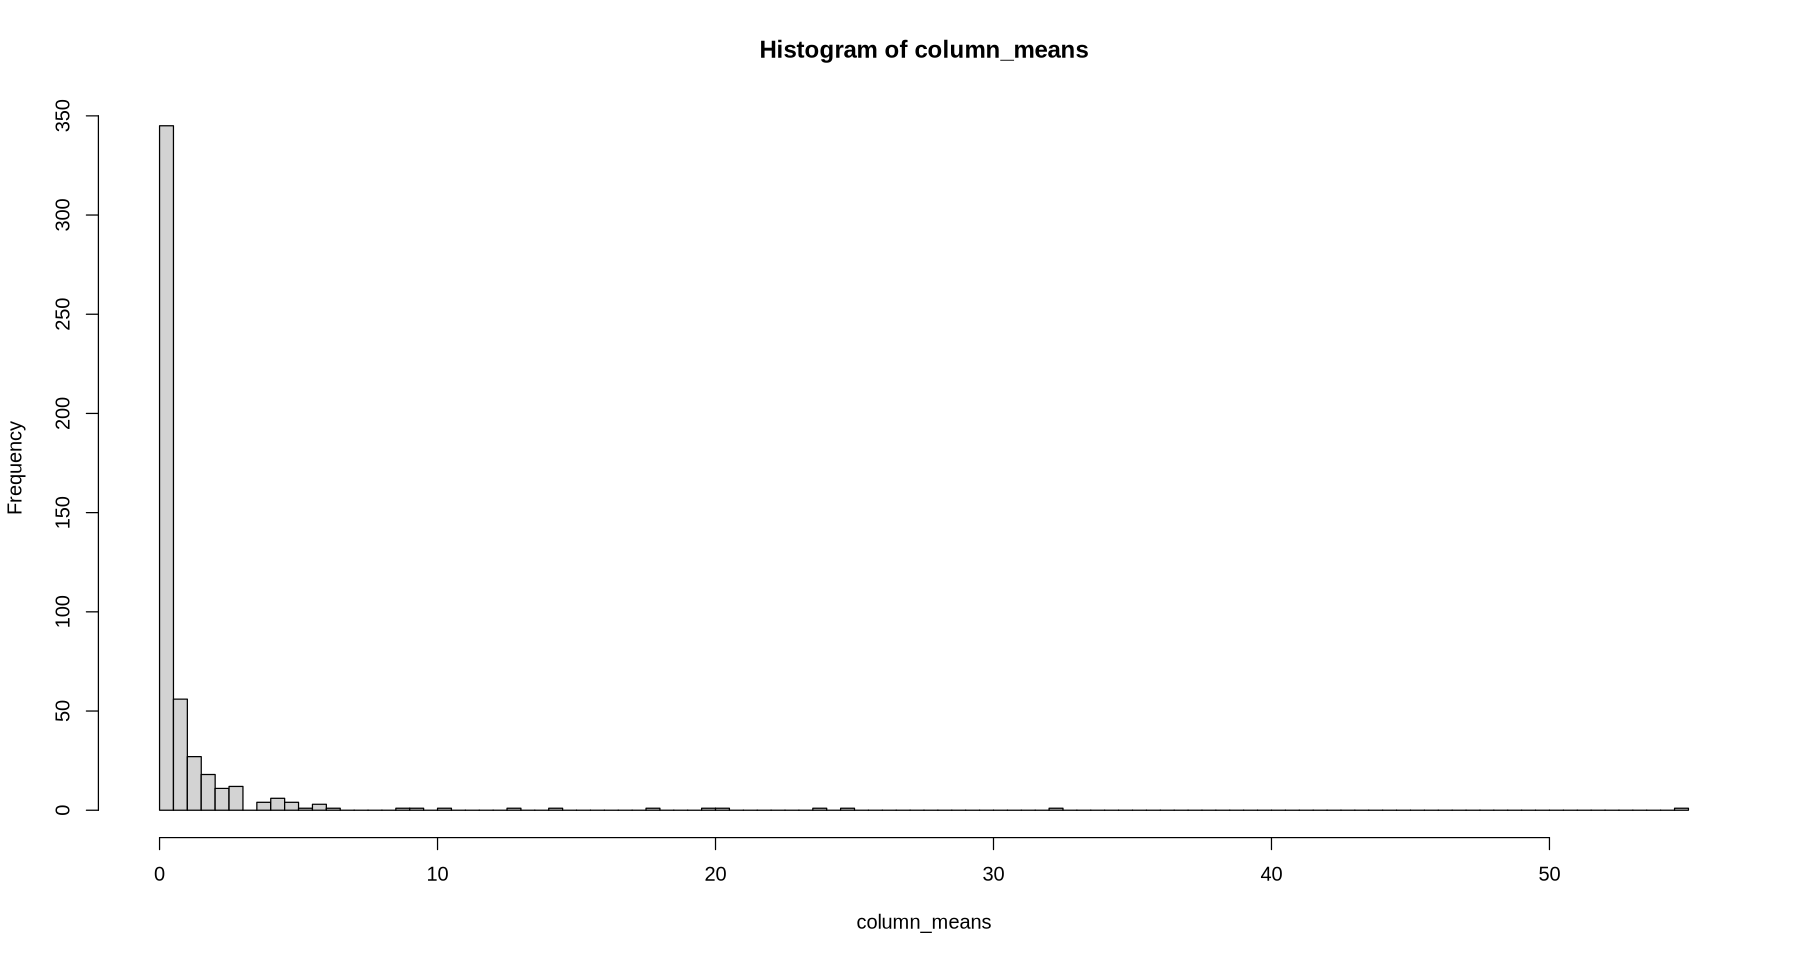

In [242]:
# Randomly select 100 columns from adata_raw
selected_columns <- sample(1:ncol(adata_raw$X), 500)
data <- adata_raw[, selected_columns]

column_means <- colMeans(as.matrix(data$X))
dim(column_means)
summary(column_means)
hist(column_means, breaks = 100)


In [261]:
# Estimate the parameters of a gamma distribution
gamma_fit <- fitdistr(column_means, densfun = "gamma")
gamma_fit

# Extract the shape and rate parameters
shape <- gamma_fit$estimate["shape"]
rate <- gamma_fit$estimate["rate"]

# Print the estimated parameters
cat("Estimated shape:", shape, "\n")
cat("Estimated rate:", rate, "\n")


Warning message in densfun(x, parm[1], parm[2], ...):
“NaNs produced”
Warning message in densfun(x, parm[1], parm[2], ...):
“NaNs produced”
Warning message in densfun(x, parm[1], parm[2], ...):
“NaNs produced”
Warning message in densfun(x, parm[1], parm[2], ...):
“NaNs produced”


     shape         rate   
  0.27660624   0.25739334 
 (0.01372434) (0.02534005)

Estimated shape: 0.2766062 
Estimated rate: 0.2573933 


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
 0.00000  0.02006  0.23661  1.10298  1.21968 21.18993 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
 0.00023  0.00977  0.16684  1.07463  0.69747 54.50267 

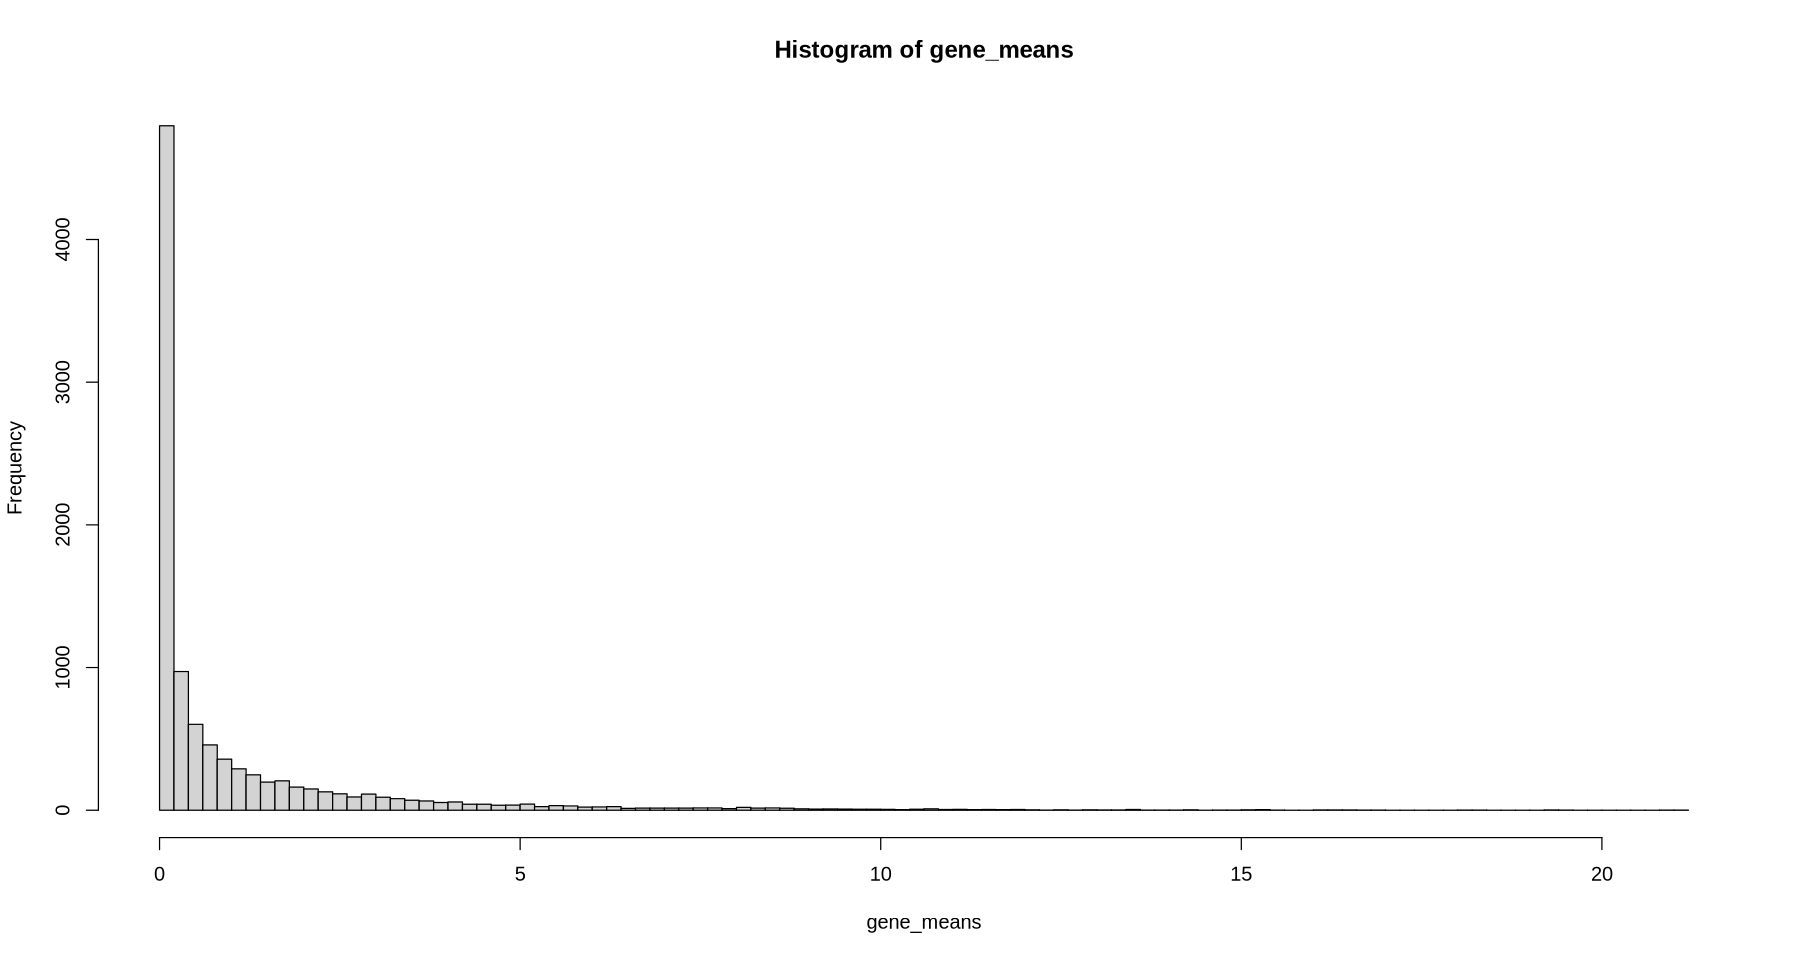

In [263]:
gene_means <- rgamma(10000, shape = 0.28, rate = 0.26)
hist(gene_means, breaks = 100)
summary(gene_means)
summary(column_means)


## Unimodal data

### Negative binomial


====

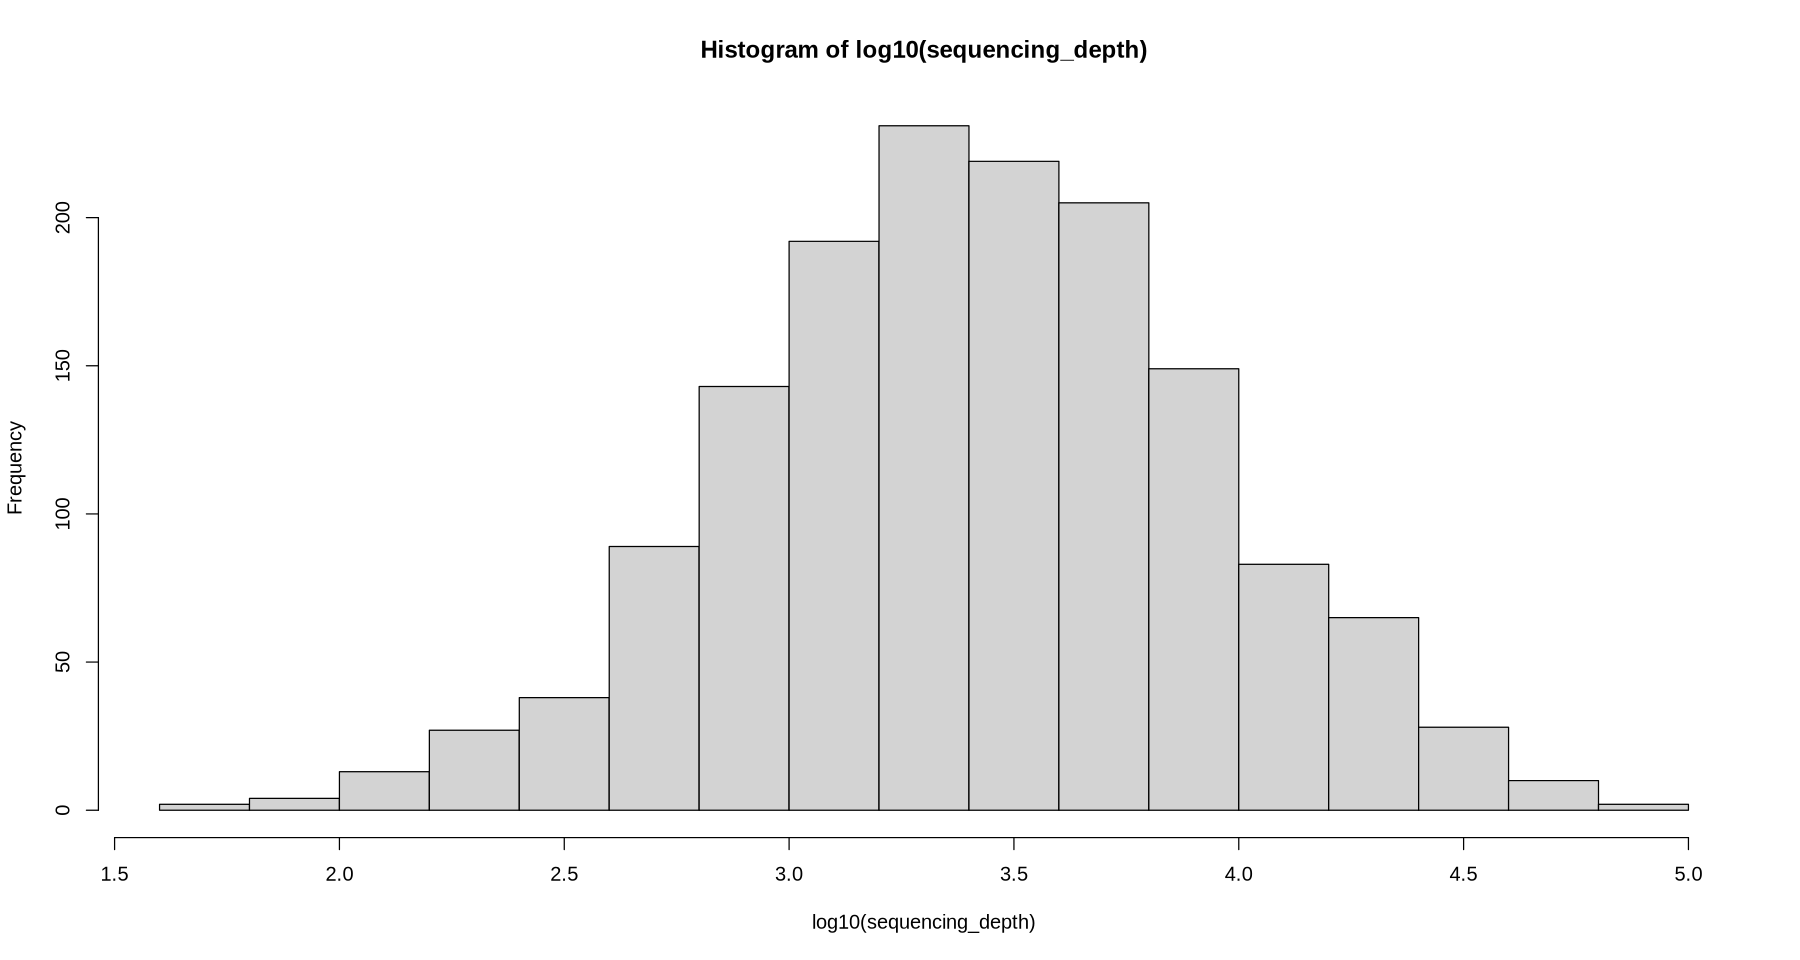

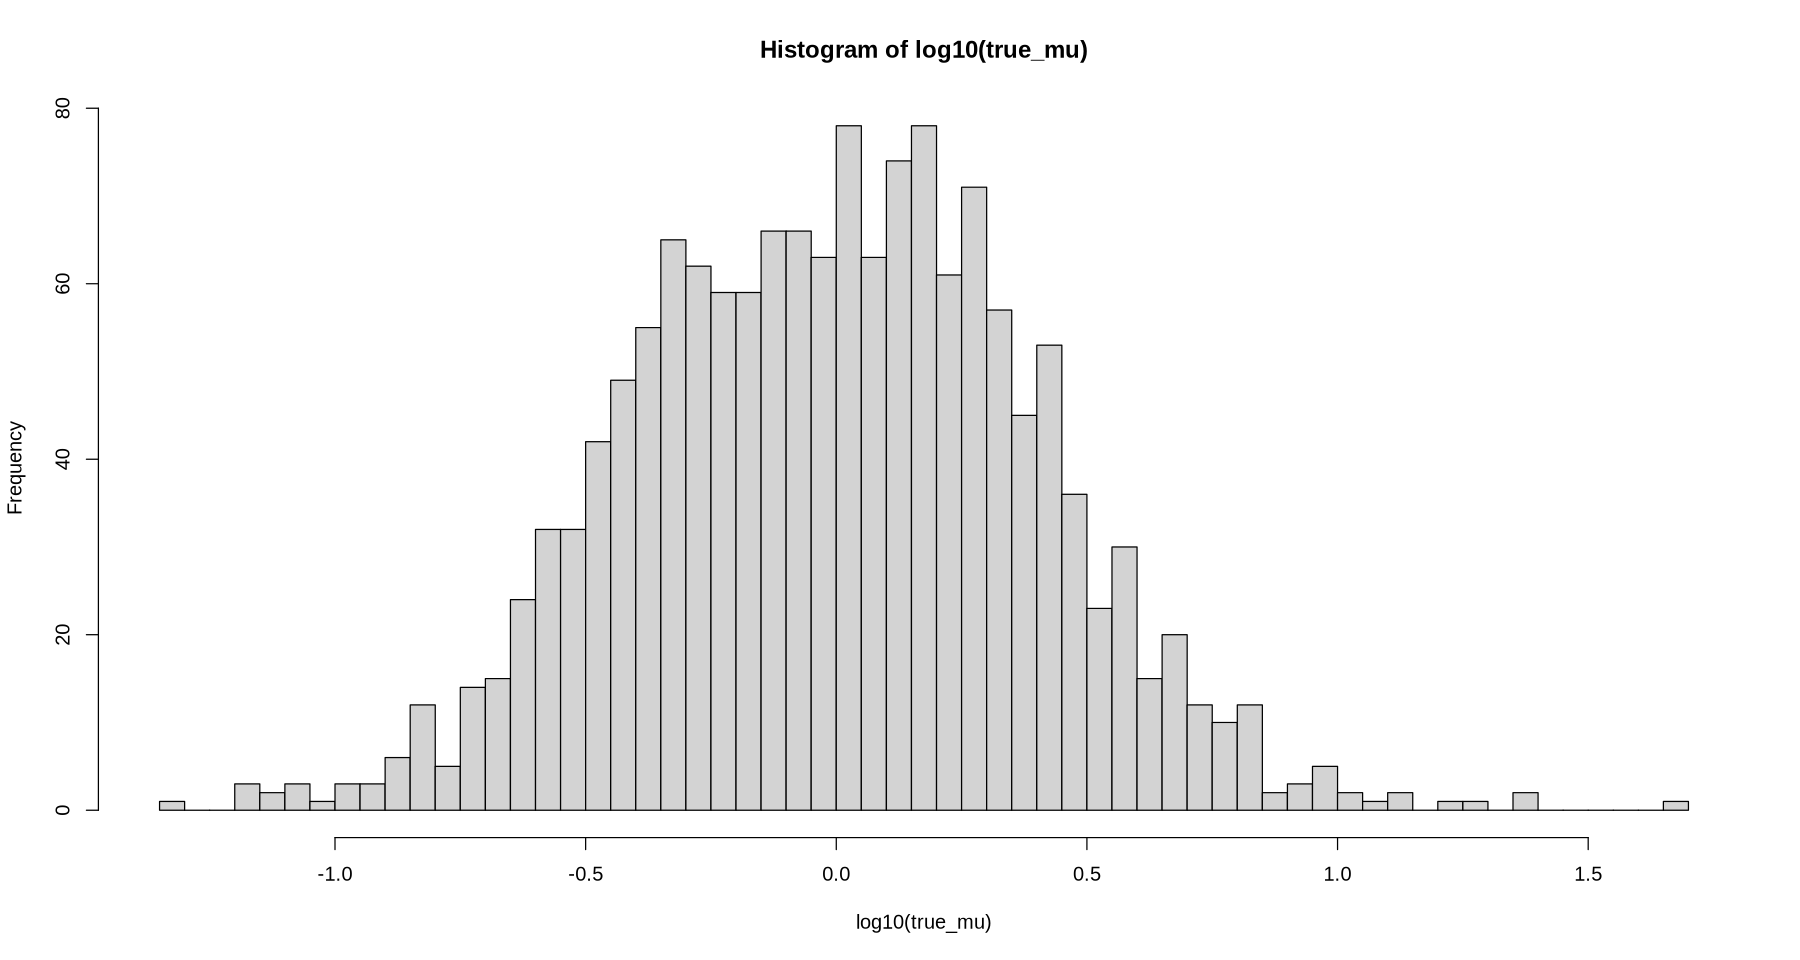

[1] 1500 1000

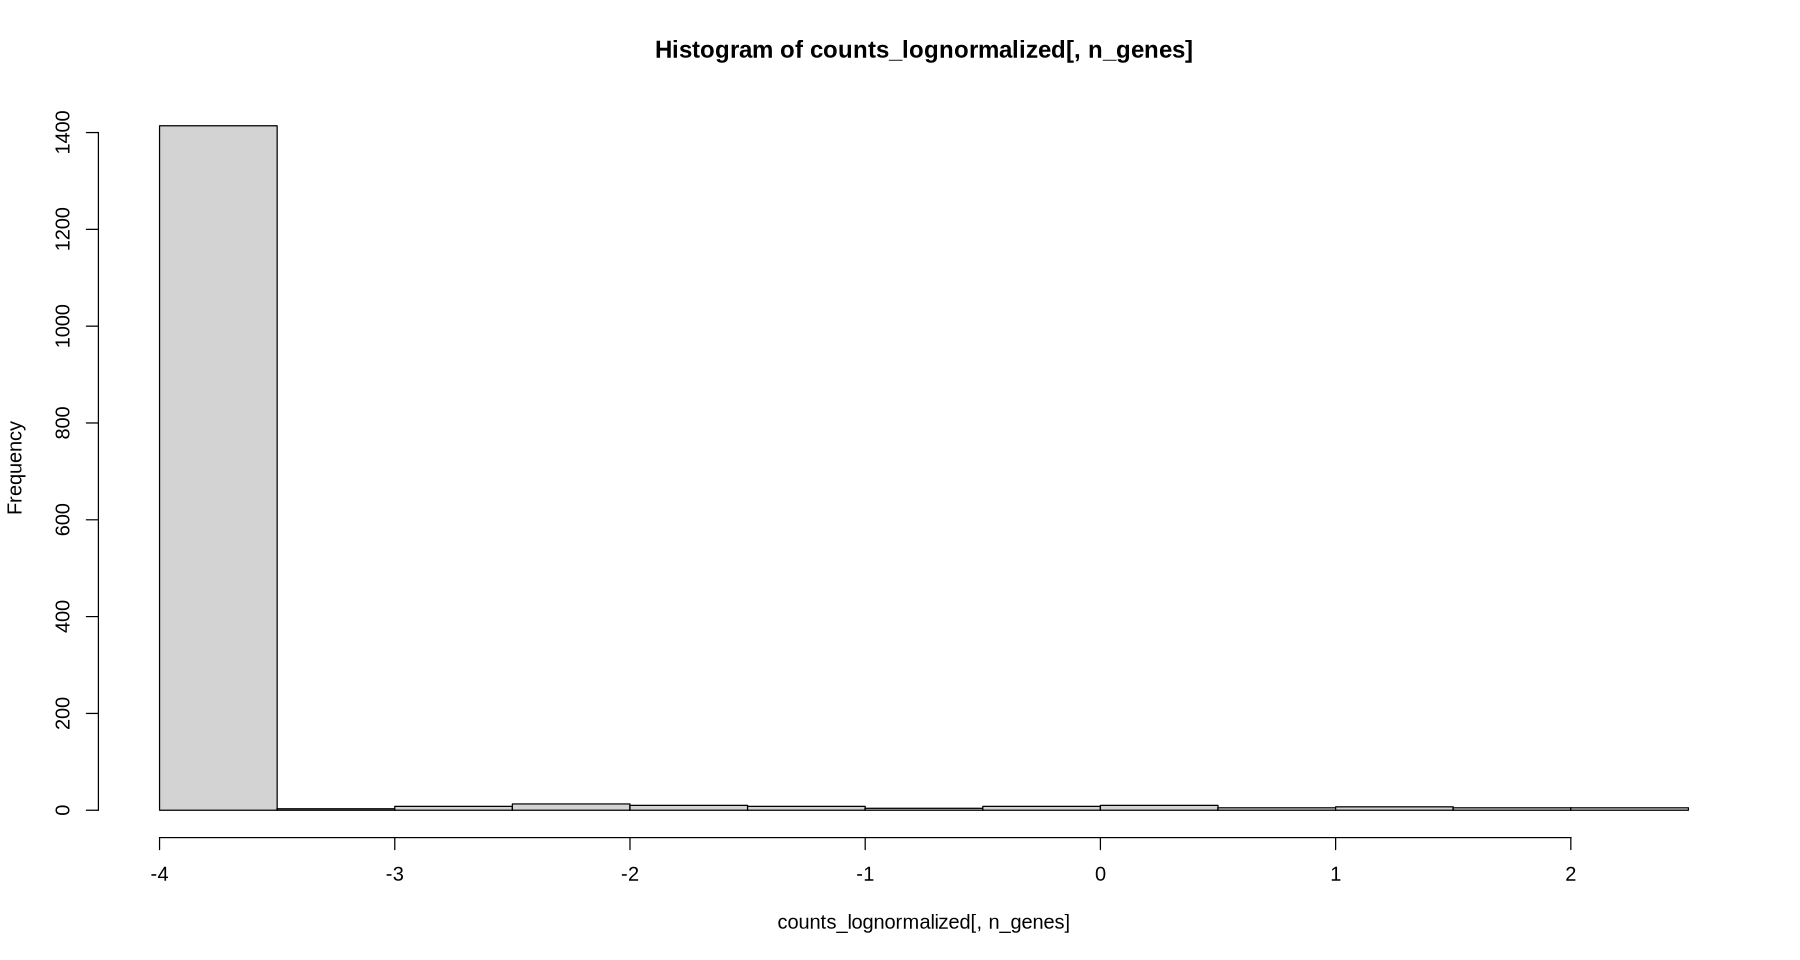

In [3]:
# Number of genes to simulate
n_genes <- 1000

# Create gene-specific mean expressions and dispersions
gene_means <- rgamma(n_genes, shape = 0.28, rate = 0.26)
gene_dispersion <- 1 / (10^rnorm(n_genes, 1.2, 1.15)) # Different dispersions per gene

# Number of cells to simulate
n_cells <- 1500


# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n_cells, log10(mean_size), std_size))
hist(log10(sequencing_depth))

counts <- matrix(0, nrow = n_cells, ncol = n_genes)
pb <- txtProgressBar(min = 0, max = n_genes, initial = 0)
for (gene in 1:n_genes) {
    setTxtProgressBar(pb, gene) # Set a progress bar
    # Simulate the true expression rate for each cell
    mean_rate <- gene_means[gene] # corresponds to expression rate around 10^(mean_rate)
    std_rate <- 0.4
    true_mu <- 10^rnorm(n_cells, mean_rate, std_rate)


    # Simulate the observed read counts per cell as a poisson process
    # The expected count for each cell is proportional to the true expression rate and the sequencing depth
    counts[, gene] <- rnbinom(n_cells, size = gene_dispersion[gene], mu = true_mu * sequencing_depth)
    close(pb) # Close the progress bar
}

# Normalize the expression counts per cell and log-transform them
counts_lognormalized <- log10(counts / sequencing_depth + 1e-4)

# Check some variables
hist(log10(true_mu), 100) # biological mean expression rate of the last gene
hist(counts_lognormalized[, n_genes]) # Check the last gene expression profile for all cells
dim(counts_lognormalized)


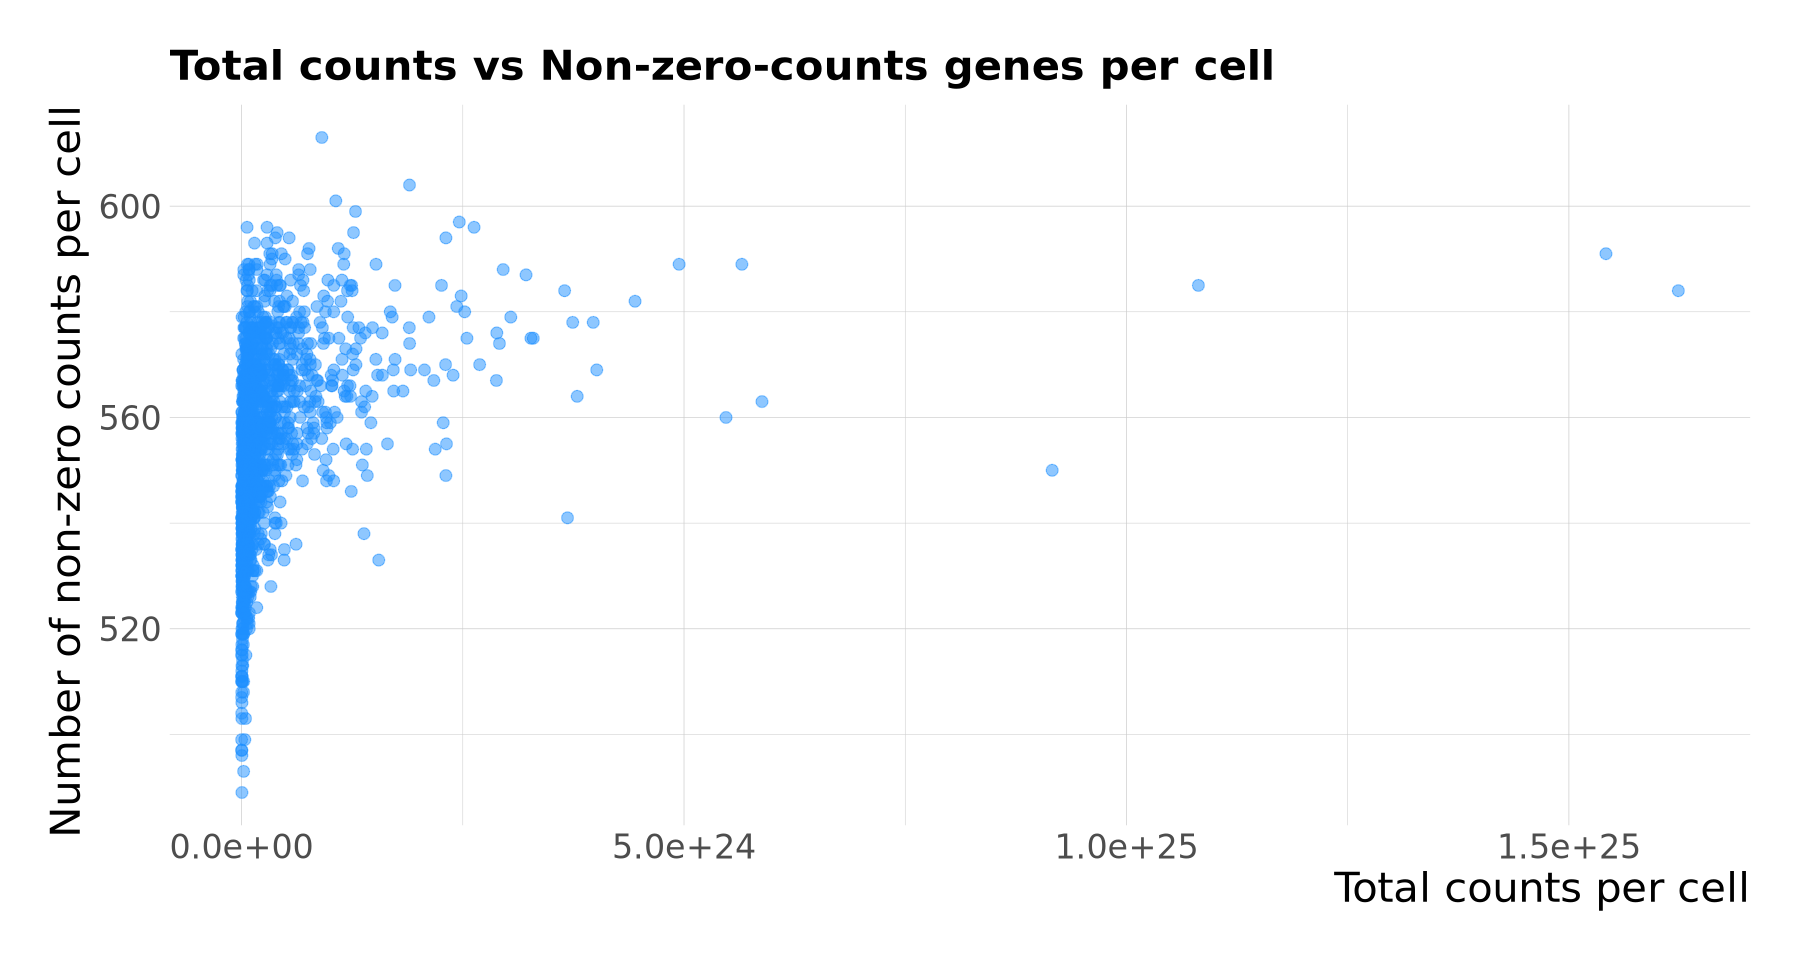

In [39]:
# Calculate the number of rows where sum(counts) > 0
non_zero_counts <- rowSums(counts > 0)

# Create a data frame for plotting
plot_data <- data.frame(Counts = rowSums(counts), NonZeroCounts = non_zero_counts)

# Plot using ggplot2
ggplot(plot_data, aes(x = Counts, y = NonZeroCounts)) +
    geom_point(alpha = 0.5, color = "dodgerblue", size = 3) +
    labs(
        title = "Total counts vs Non-zero-counts genes per cell",
        x = "Total counts per cell",
        y = "Number of non-zero counts per cell"
    ) +
    theme_ipsum_rc(base_size = 20, plot_title_size = 25, axis_title_size = 25)


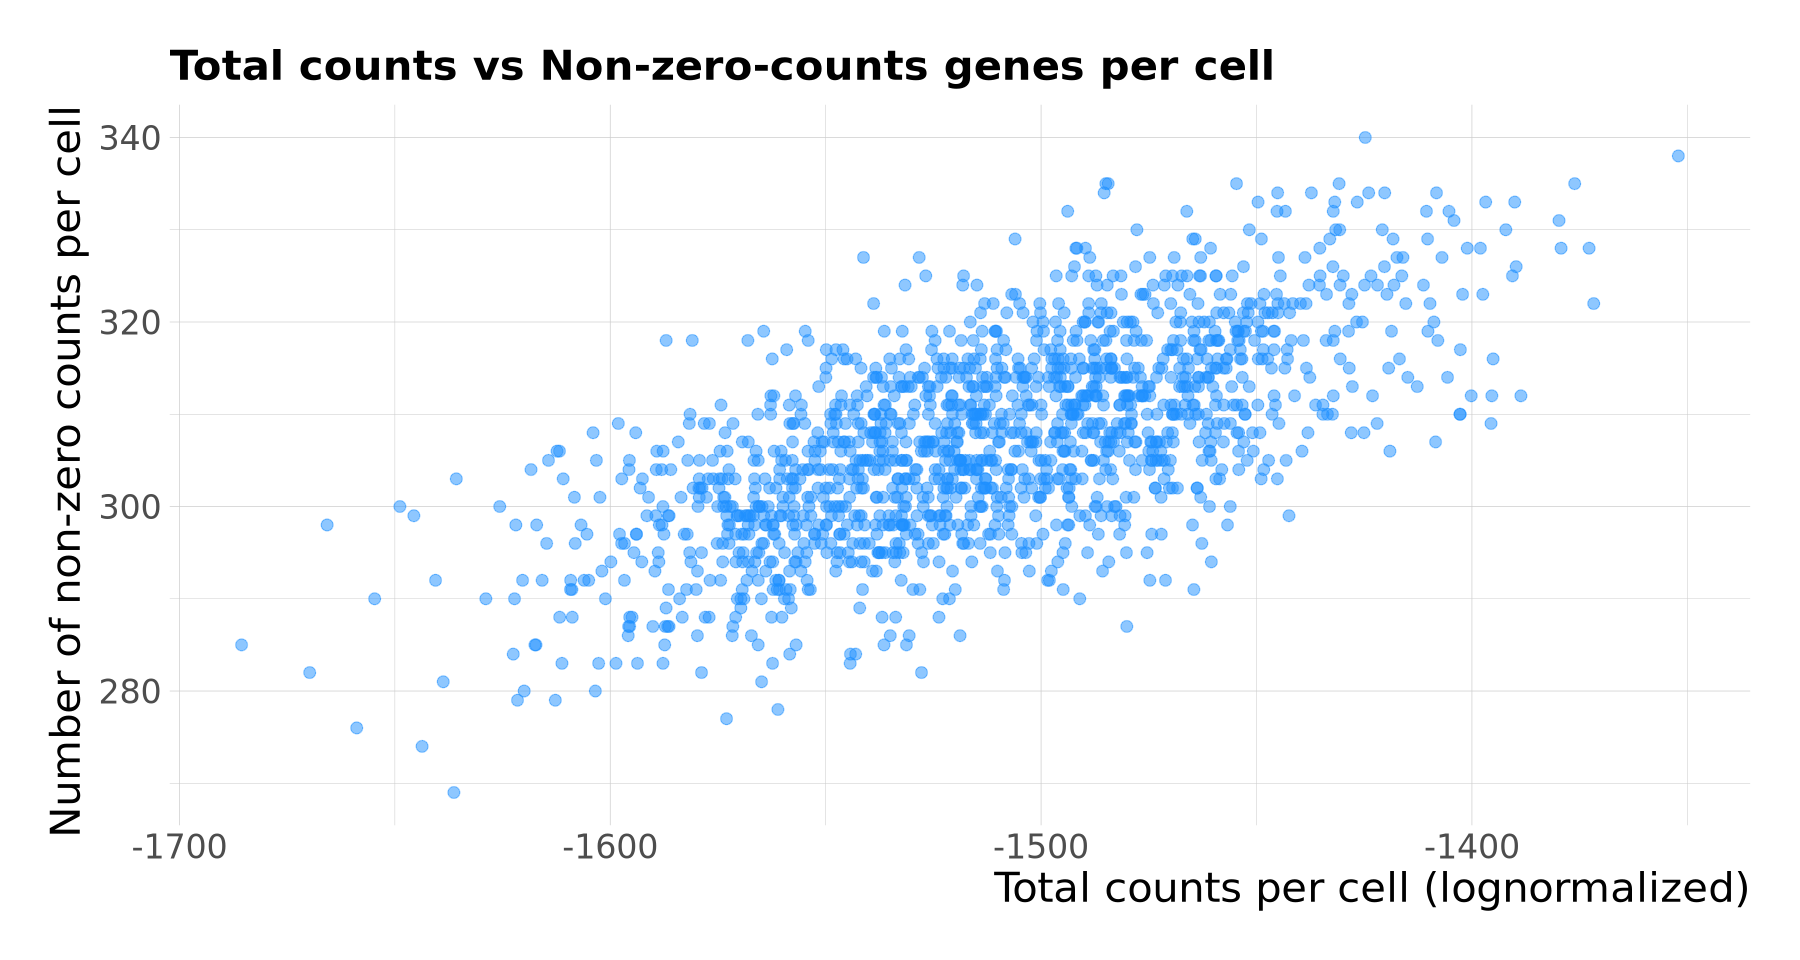

In [41]:
# Calculate the number of rows where sum(counts) > 0
non_zero_counts <- rowSums(counts_lognormalized > 0)

# Create a data frame for plotting
plot_data <- data.frame(Counts = rowSums(counts_lognormalized), NonZeroCounts = non_zero_counts)

# Plot using ggplot2
ggplot(plot_data, aes(x = Counts, y = NonZeroCounts)) +
    geom_point(alpha = 0.5, color = "dodgerblue", size = 3) +
    labs(
        title = "Total counts vs Non-zero-counts genes per cell",
        x = "Total counts per cell (lognormalized)",
        y = "Number of non-zero counts per cell"
    ) +
    theme_ipsum_rc(base_size = 20, plot_title_size = 25, axis_title_size = 25)


## Uni- and bimodal data

### Negative binomial

==

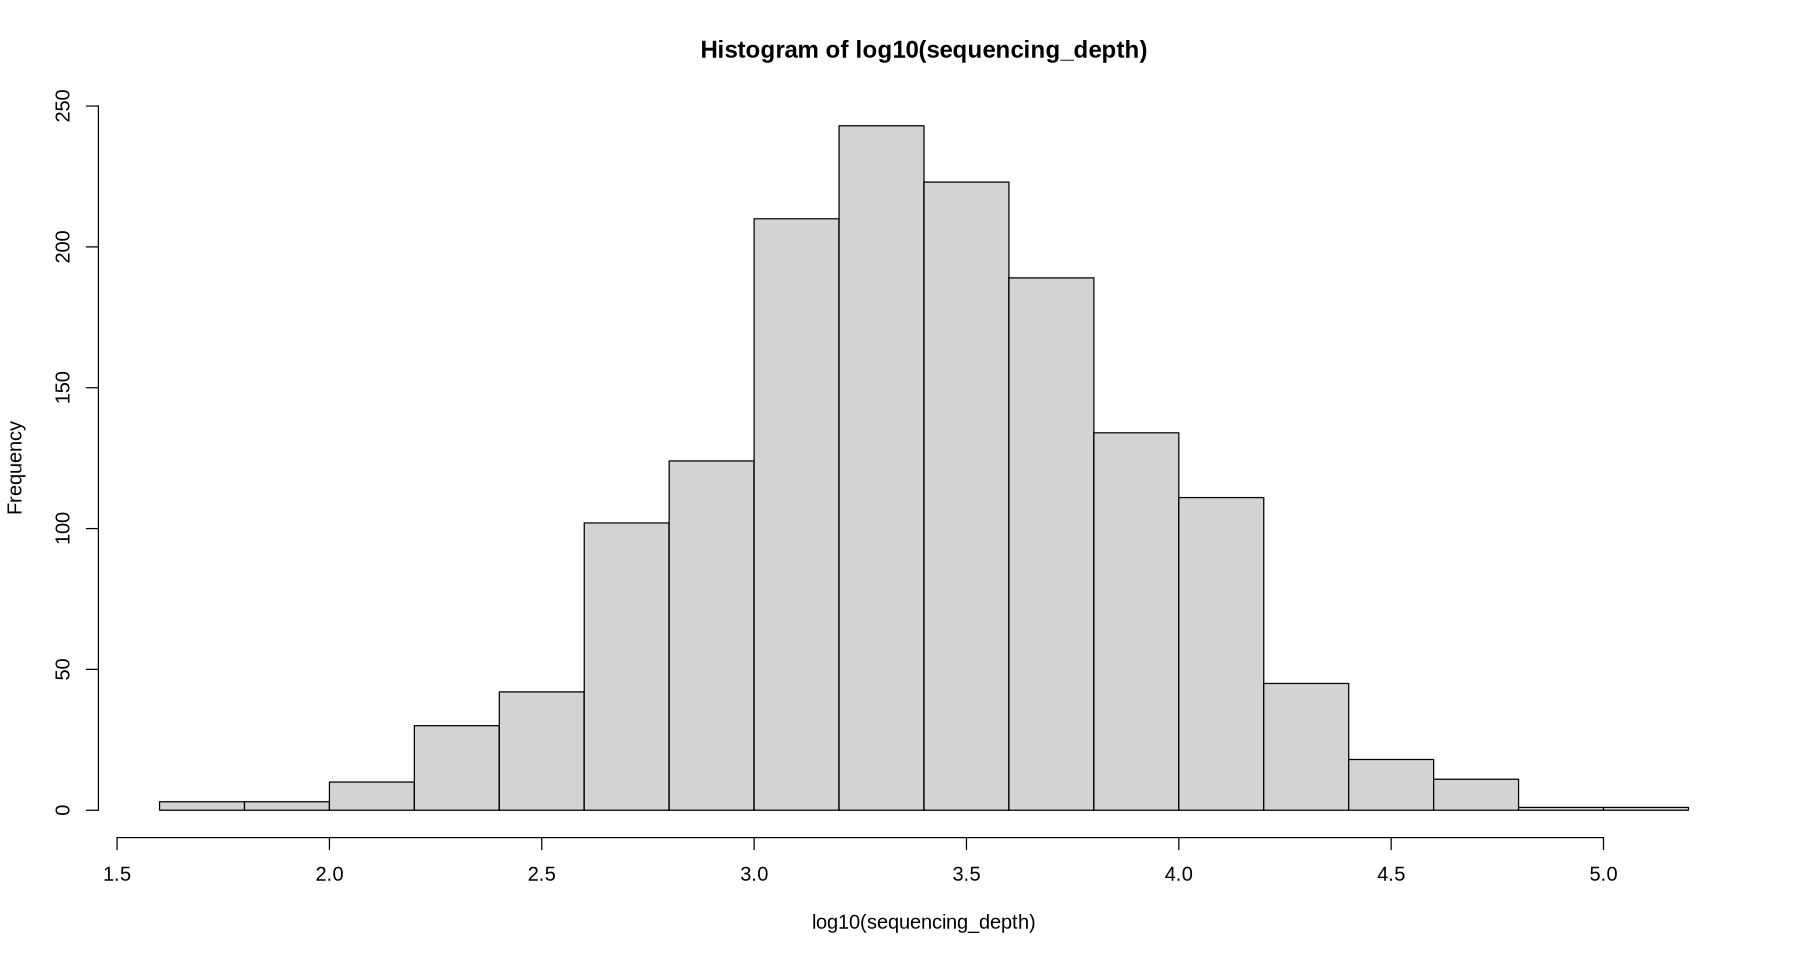

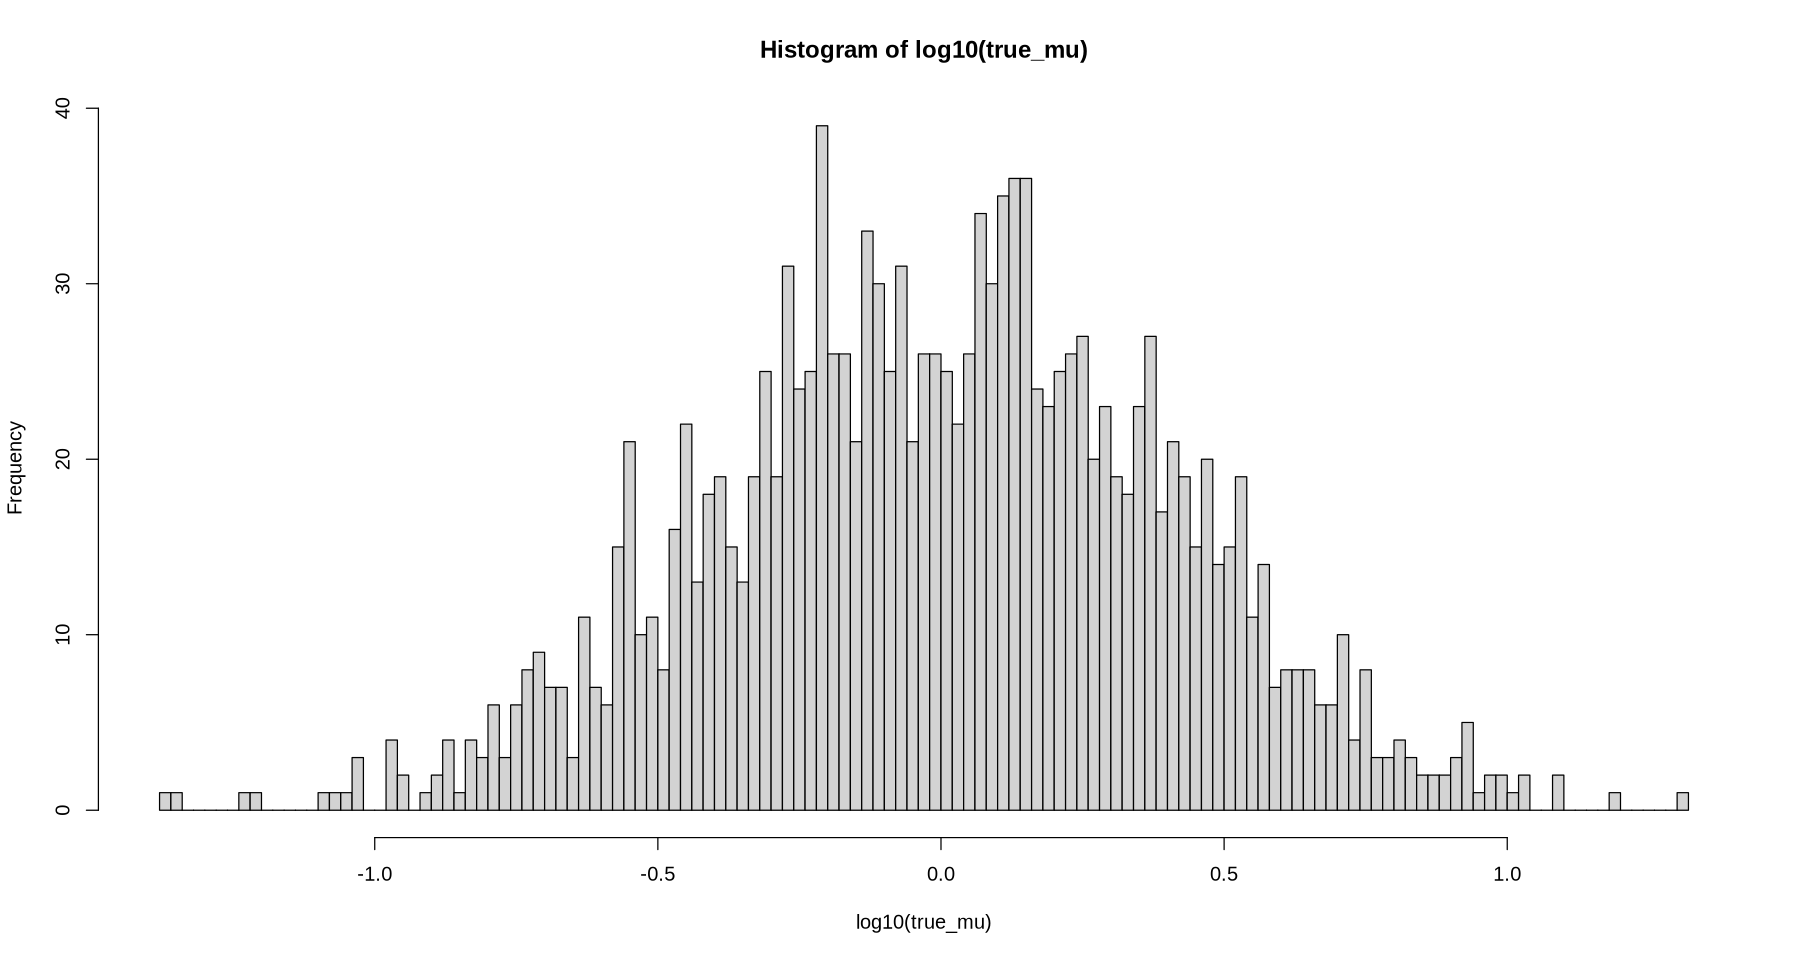

[1] 1500 1000

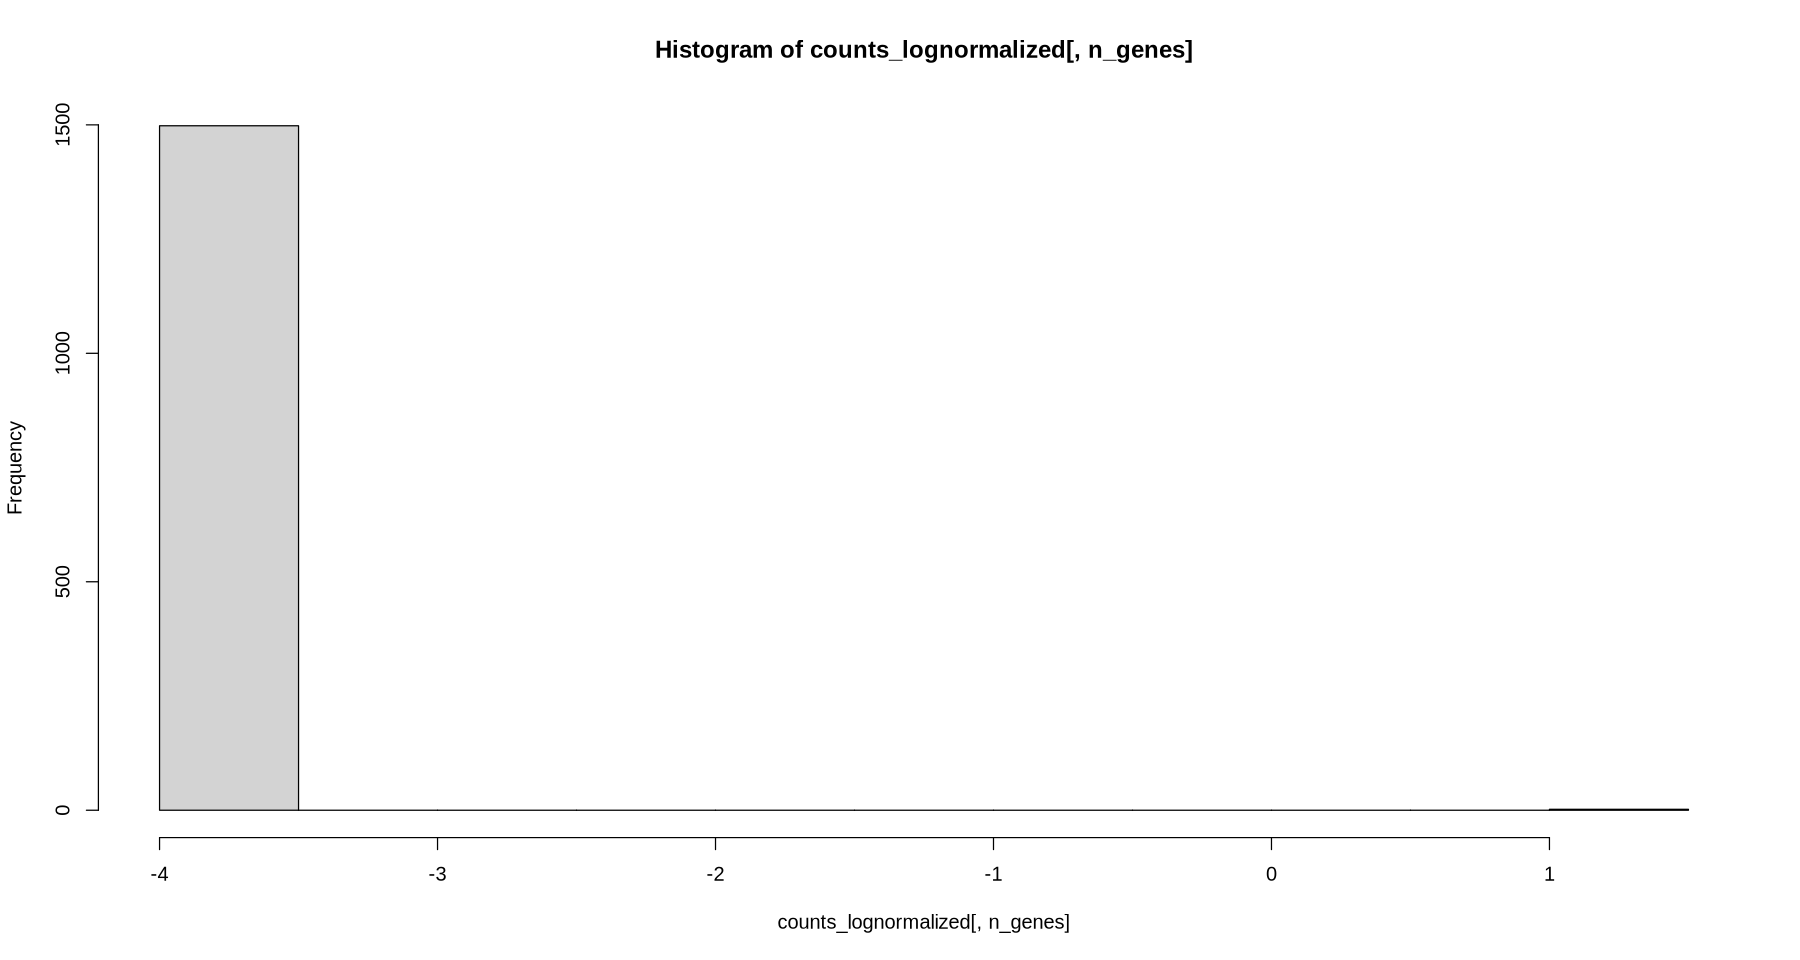

In [14]:
# Number of genes to simulate
n_genes <- 1000

# Create gene-specific mean expressions and dispersions
gene_means <- rgamma(n_genes, shape = 0.28, rate = 0.26)
gene_means_2 <- rgamma(n_genes, shape = 0.28, rate = 0.26)
gene_dispersion <- 1 / (10^rnorm(n_genes, 1.2, 1.15)) # Different dispersions per gene

# Number of cells to simulate
n_cells <- 1500


# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n_cells, log10(mean_size), std_size))
hist(log10(sequencing_depth))

percent_bimodal <- 10
n_bimodal <- round(n_genes * percent_bimodal / 100) # Calculate the number of bimodal genes

counts <- matrix(0, nrow = n_cells, ncol = n_genes)
pb <- txtProgressBar(min = 0, max = n_genes, initial = 0)
for (gene in 1:n_genes) {
    setTxtProgressBar(pb, gene) # Set a progress bar
    # Simulate the true expression rate for each cell
    if (gene <= n_bimodal) {
        # Create bimodal distribution for the first n_bimodal genes
        bimodal_prob <- runif(1, 0.2, 0.8) # Draw the probability of each cell being from each bimodal from a uniform distribution
        true_mu <- 10^ifelse(runif(n_cells) < bimodal_prob,
            rnorm(n_cells, gene_means[gene], 0.4),
            rnorm(n_cells, gene_means_2[gene], 0.4)
        )
    } else {
        # Create unimodal distribution for the remaining genes
        true_mu <- 10^rnorm(n_cells, gene_means[gene], 0.4)
    }

    # Simulate the observed read counts per cell as a negative binomial process
    # The expected count for each cell is proportional to the true expression rate and the sequencing depth
    counts[, gene] <- rnbinom(n_cells, size = gene_dispersion[gene], mu = true_mu * sequencing_depth)
}
close(pb) # Close the progress bar

# Normalize the expression counts per cell and log-transform them
counts_lognormalized <- log10(counts / sequencing_depth + 1e-4)

# Check some variables
hist(log10(true_mu), 100) # biological mean expression rate of the last gene
hist(counts_lognormalized[, n_genes]) # Check the last gene expression profile for all cells
dim(counts_lognormalized)


No id variables; using all as measure variables



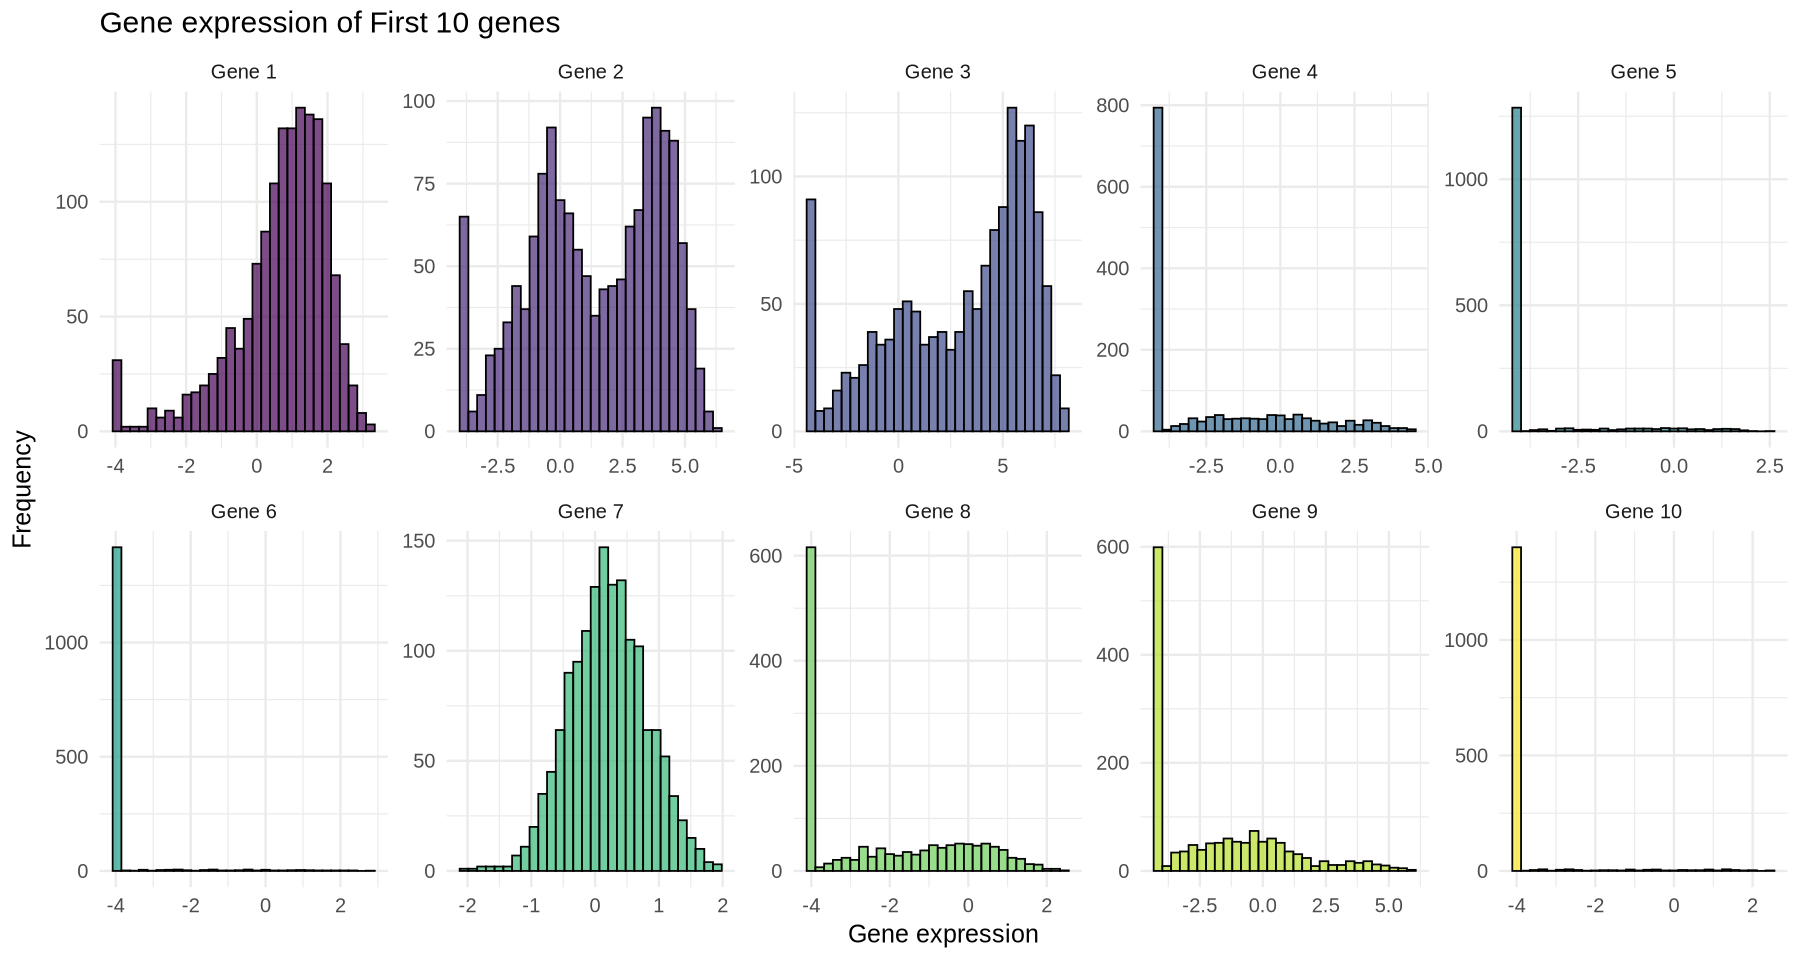

In [27]:
# Convert the first 10 columns of counts_lognormalized to a data frame for ggplot2
plot_data <- as.data.frame(counts_lognormalized[, 1:10])

# Rename the columns as "Gene 1", "Gene 2", ...
colnames(plot_data) <- paste0("Gene ", 1:10)

# Melt the data frame for ggplot2
plot_data <- melt(plot_data, variable.name = "Gene", value.name = "Values")

# Create the ggplot
ggplot(plot_data, aes(x = Values)) +
    geom_histogram(aes(fill = Gene), bins = 30, color = "black", alpha = 0.7) +
    scale_fill_viridis_d() +
    facet_wrap(~Gene, ncol = 5, scales = "free") +
    labs(
        title = "Gene expression of First 10 genes",
        x = "Gene expression",
        y = "Frequency"
    ) +
    theme_minimal(base_size = 15) +
    theme(legend.position = "none")


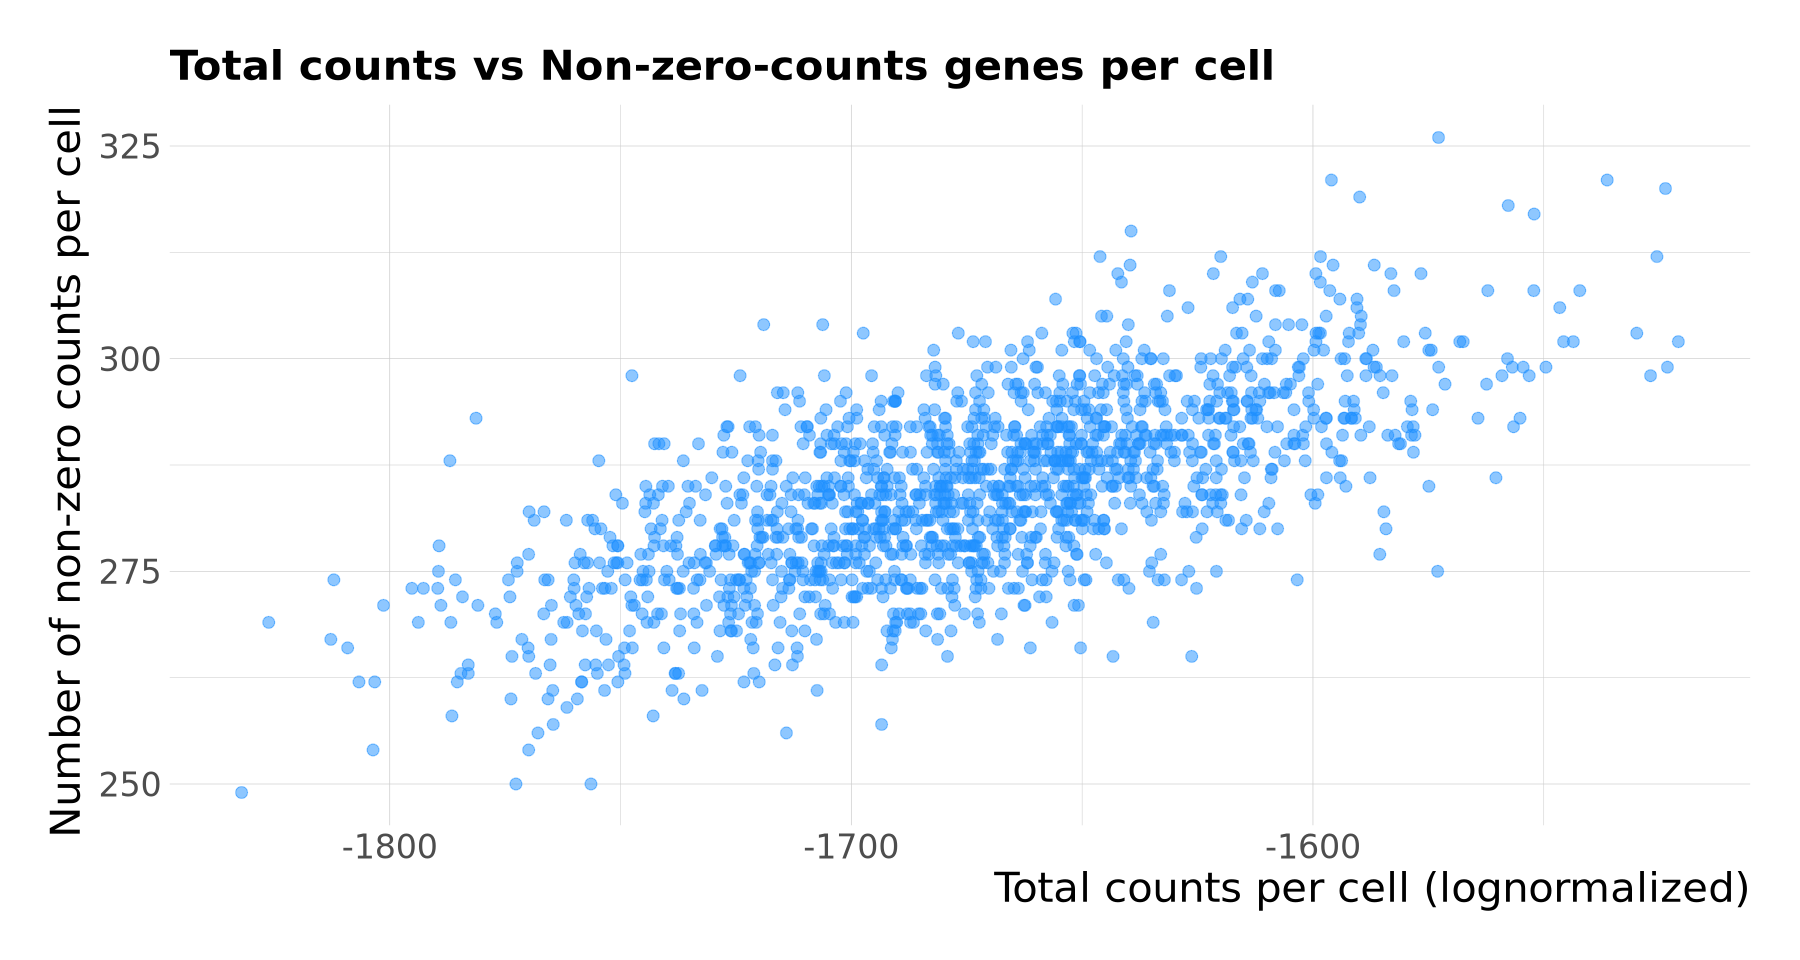

In [23]:
# Calculate the number of rows where sum(counts) > 0
non_zero_counts <- rowSums(counts_lognormalized > 0)

# Create a data frame for plotting
plot_data <- data.frame(Counts = rowSums(counts_lognormalized), NonZeroCounts = non_zero_counts)

# Plot using ggplot2
ggplot(plot_data, aes(x = Counts, y = NonZeroCounts)) +
    geom_point(alpha = 0.5, color = "dodgerblue", size = 3) +
    labs(
        title = "Total counts vs Non-zero-counts genes per cell",
        x = "Total counts per cell (lognormalized)",
        y = "Number of non-zero counts per cell"
    ) +
    theme_ipsum_rc(base_size = 20, plot_title_size = 25, axis_title_size = 25)


===

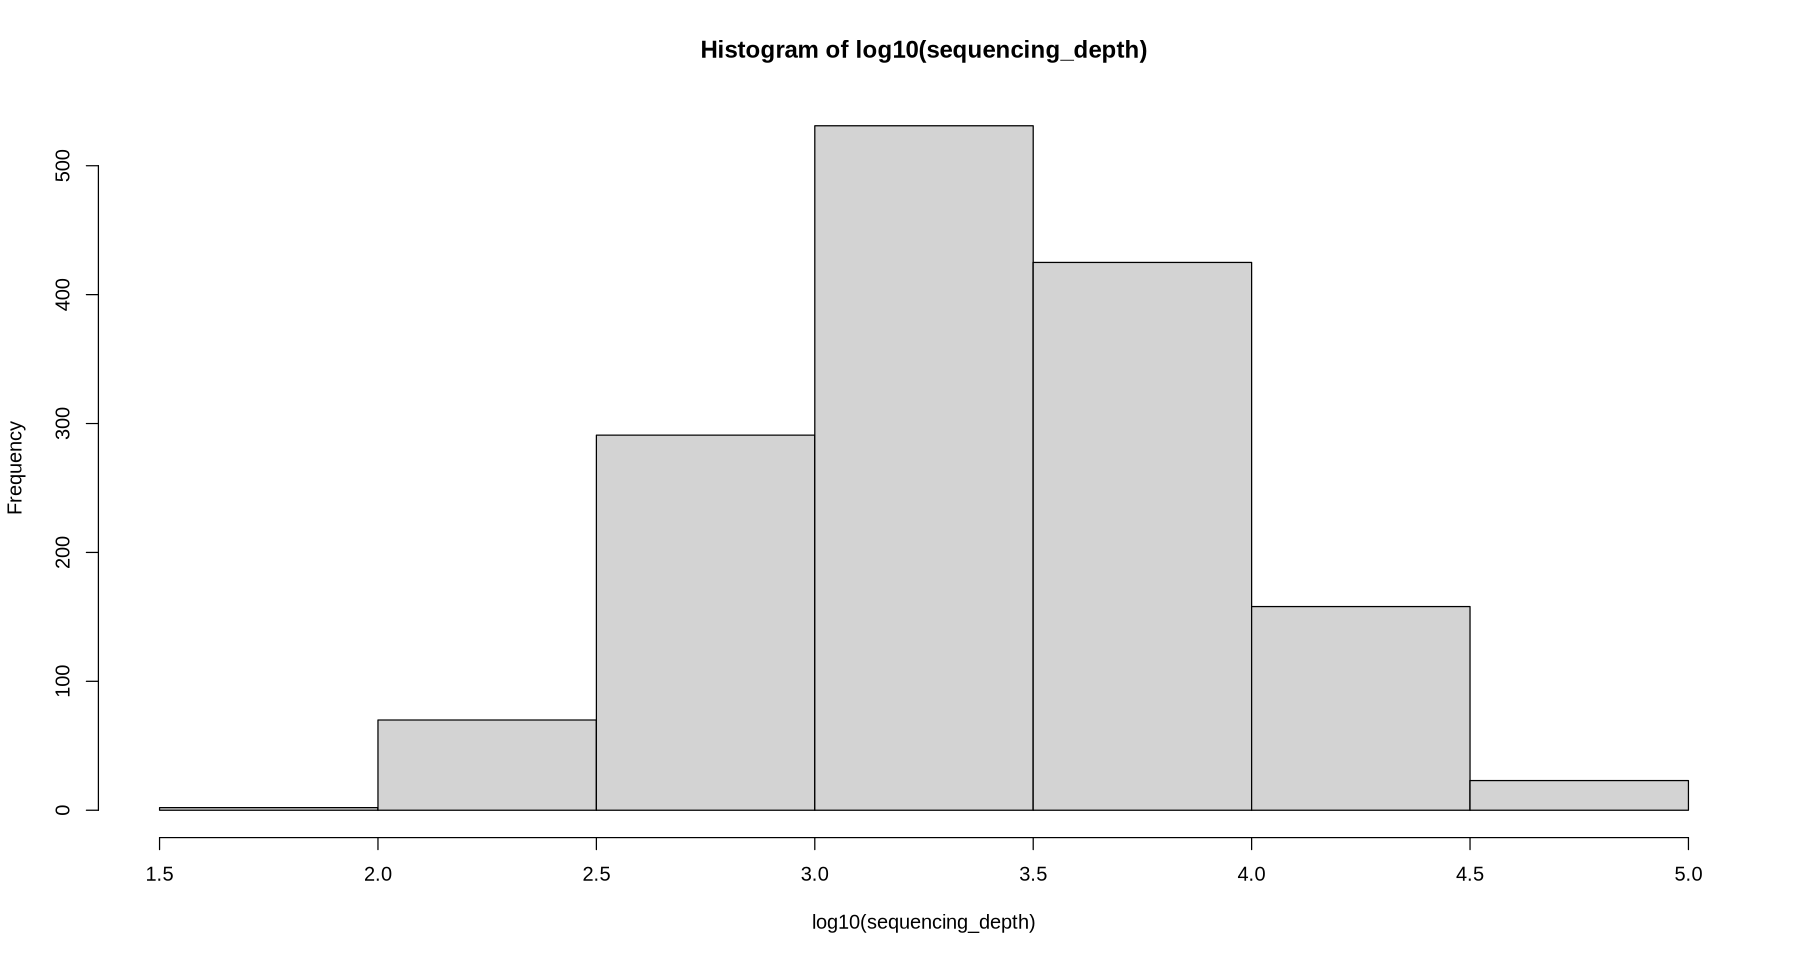

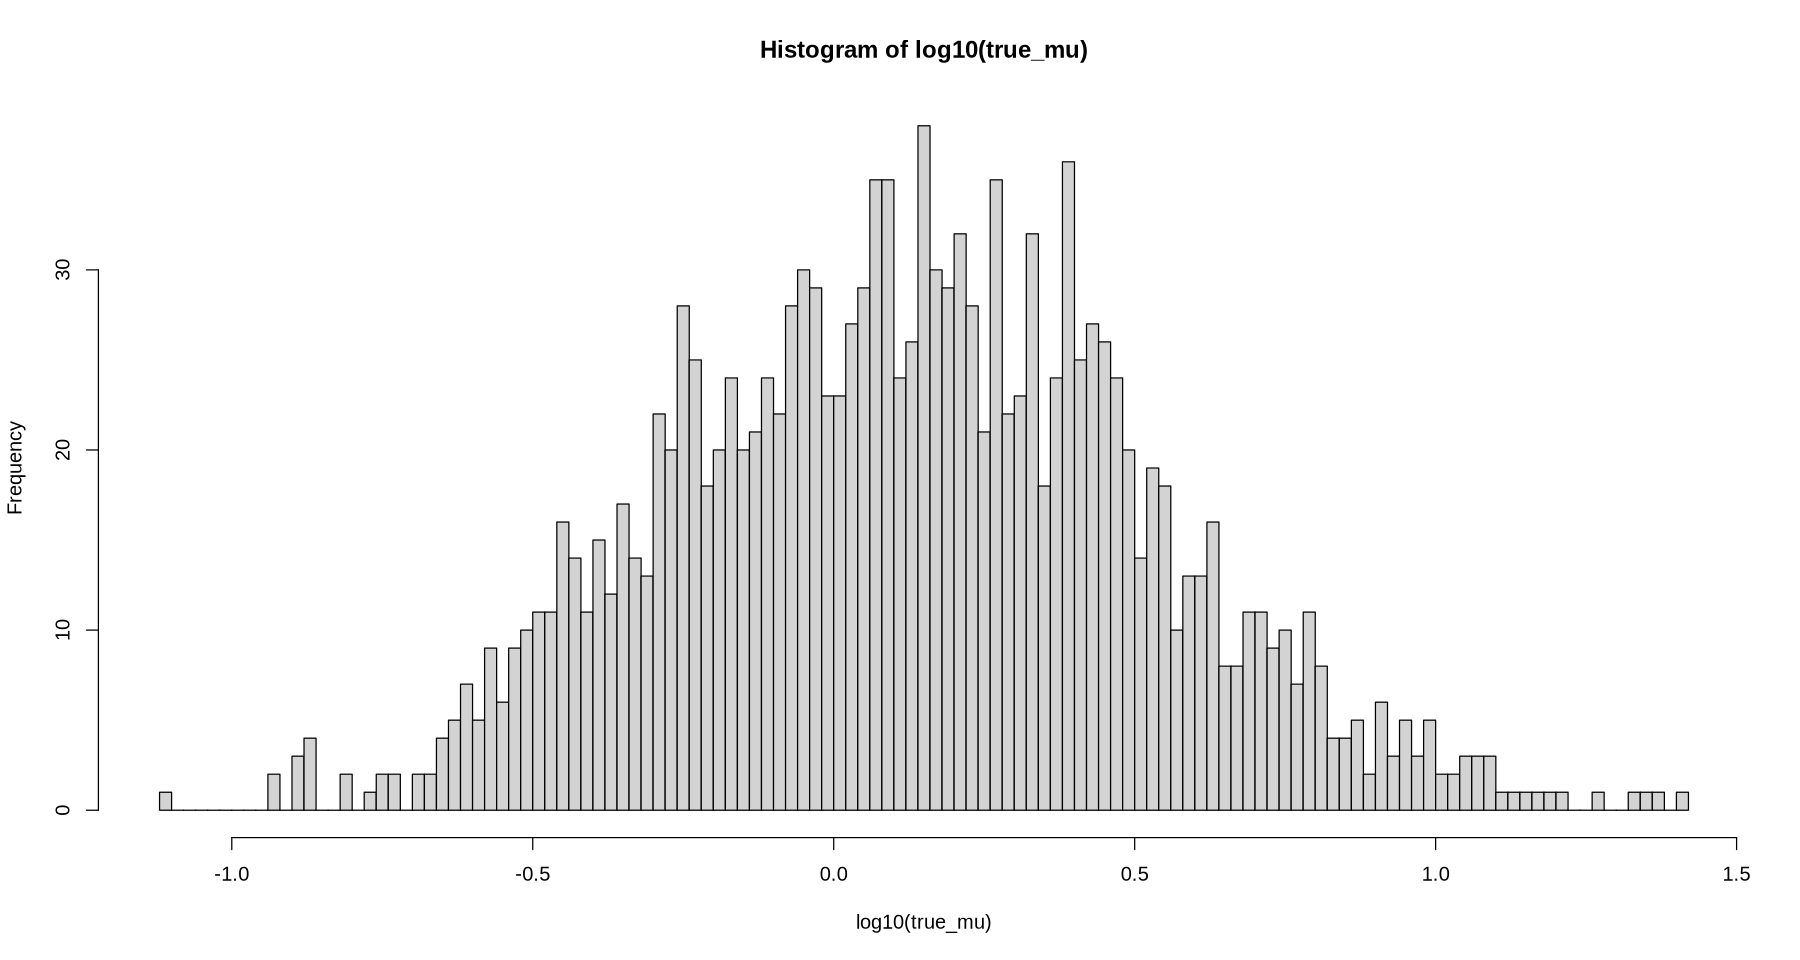

[1] 1500 1000

,Gene,GeneDispersion,GeneMean,GeneMean2,BimodalProb,TrueMuSequencingDepth
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<I<list>>
1,1,0.0002114781,4.8800912473,6.998039e-04,0.7402318,50514283....
2,2,0.0246476912,0.0000242984,1.207841e-01,0.6058360,30022.13....
3,3,0.0446153886,1.8347024453,2.454116e-02,0.4672668,87863.07....
4,4,0.0022373142,0.0215425654,8.512802e-03,0.7798421,2325.179....
5,5,0.3328072665,0.0653075916,5.801037e-01,0.6354112,13284.15....
6,6,0.0077263717,0.1619673305,1.713926e-05,0.3385307,5648.174....


,Gene,GeneDispersion,GeneMean,GeneMean2,BimodalProb,TrueMuSequencingDepth
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<I<list>>
995,995,0.21496910,0.1029259,0,0,2711.516....
996,996,0.02457041,3.9055643,0,0,61360112....
997,997,0.50570830,1.0048833,0,0,67760.23....
998,998,0.03557372,2.6320094,0,0,478713.7....
999,999,0.86042599,0.4031266,0,0,8827.301....
1000,1000,0.15579568,0.1401788,0,0,2225.423....


,Cell,SequencingDepth,SumCounts,SumCountsNormalized,NonZeroCounts
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,4145,4.429169e+27,1.068557e+24,536
2,2,2751,2.613368e+27,9.499703e+23,533
3,3,8974,1.054545e+29,1.175112e+25,533
4,4,517,4.480113e+27,8.665597e+24,509
5,5,6079,5.337461e+28,8.780162e+24,533
6,6,42596,4.767608e+28,1.119262e+24,564


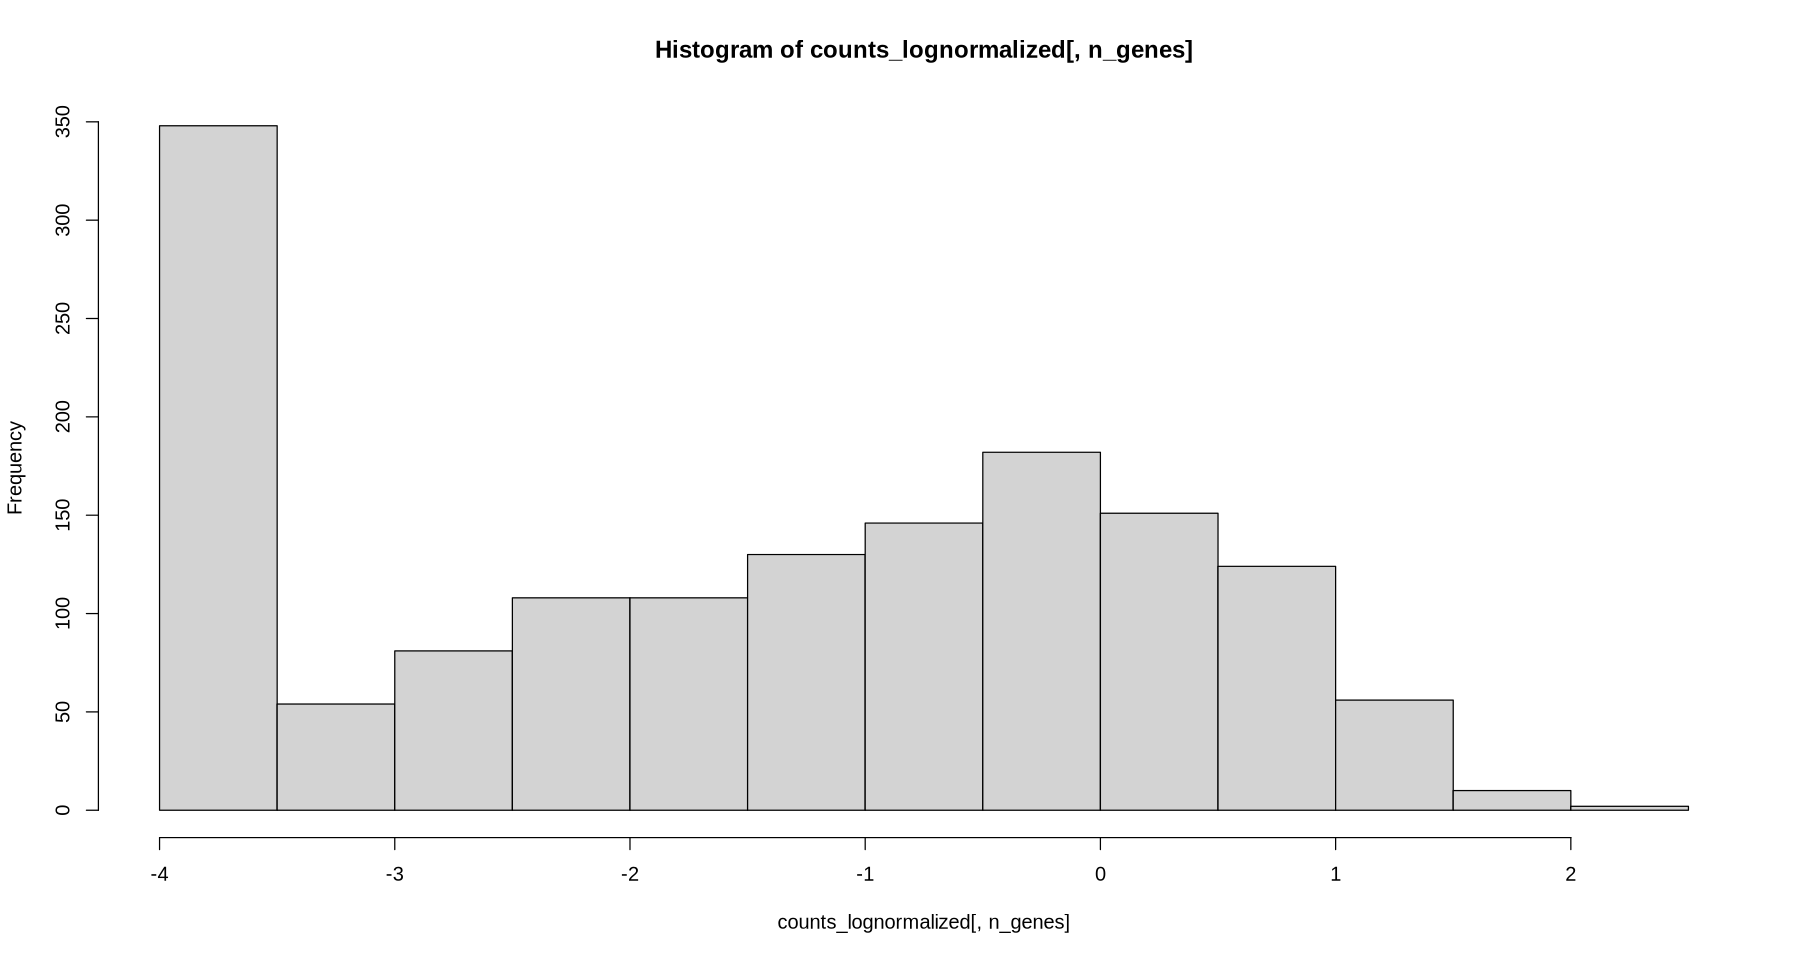

In [36]:
# Number of genes to simulate
n_genes <- 1000

# Create gene-specific mean expressions and dispersions
gene_means <- rgamma(n_genes, shape = 0.28, rate = 0.26)
gene_means_2 <- rgamma(n_genes, shape = 0.28, rate = 0.26)
gene_dispersion <- 1 / (10^rnorm(n_genes, 1.2, 1.15)) # Different dispersions per gene

# Number of cells to simulate
n_cells <- 1500

# Get log-normally distributed total number of RNA molecules sequenced per cell (library size or sequencing depth)
# Log-normal guarantees non-negative counts and a tapering down in density for higher counts
# We first set average library size and standard deviation
mean_size <- 2500
std_size <- 0.5
sequencing_depth <- round(10^rnorm(n_cells, log10(mean_size), std_size))
hist(log10(sequencing_depth))

percent_bimodal <- 10
n_bimodal <- round(n_genes * percent_bimodal / 100) # Calculate the number of bimodal genes

counts <- matrix(0, nrow = n_cells, ncol = n_genes)

# Initialize a data frame to store important variables for each gene
gene_data <- data.frame(
    Gene = 1:n_genes,
    GeneDispersion = rep(0, n_genes),
    GeneMean = rep(0, n_genes),
    GeneMean2 = rep(0, n_genes),
    BimodalProb = rep(0, n_genes),
    TrueMuSequencingDepth = I(vector("list", n_genes))
)

pb <- txtProgressBar(min = 0, max = n_genes, initial = 0)
for (gene in 1:n_genes) {
    setTxtProgressBar(pb, gene) # Set a progress bar
    # Simulate the true expression rate for each cell
    if (gene <= n_bimodal) {
        # Create bimodal distribution for the first n_bimodal genes
        bimodal_prob <- runif(1, 0.2, 0.8) # Draw the probability of each cell being from each bimodal from a uniform distribution
        true_mu <- 10^ifelse(runif(n_cells) < bimodal_prob,
            rnorm(n_cells, gene_means[gene], 0.4),
            rnorm(n_cells, gene_means_2[gene], 0.4)
        )
        gene_data$GeneMean2[gene] <- gene_means_2[gene]
        gene_data$BimodalProb[gene] <- bimodal_prob
    } else {
        # Create unimodal distribution for the remaining genes
        true_mu <- 10^rnorm(n_cells, gene_means[gene], 0.4)
    }

    # Simulate the observed read counts per cell as a negative binomial process
    # The expected count for each cell is proportional to the true expression rate and the sequencing depth
    counts[, gene] <- rnbinom(n_cells, size = gene_dispersion[gene], mu = true_mu * sequencing_depth)

    # Store important variables for the current gene
    gene_data$GeneMean[gene] <- gene_means[gene]
    gene_data$GeneDispersion[gene] <- gene_dispersion[gene]
    gene_data$TrueMuSequencingDepth[[gene]] <- true_mu * sequencing_depth
}
close(pb) # Close the progress bar

# Normalize the expression counts per cell and log-transform them
counts_normalized <- counts / sequencing_depth + 1e-4
counts_lognormalized <- log10(counts_normalized)

# Check some variables
hist(log10(true_mu), 100) # biological mean expression rate of the last gene
hist(counts_lognormalized[, n_genes]) # Check the last gene expression profile for all cells
dim(counts_lognormalized)

# View the first and last few rows of the gene_data data frame
head(gene_data)
tail(gene_data)

# Initialize a data frame to store important variables for each cell
cell_data <- data.frame(
    Cell = 1:n_cells,
    SequencingDepth = sequencing_depth,
    SumCounts = rowSums(counts),
    SumCountsNormalized = rowSums(counts_normalized),
    NonZeroCounts = rowSums(counts > 0)
)

# View the first few rows of the cell_data data frame
head(cell_data)


No id variables; using all as measure variables



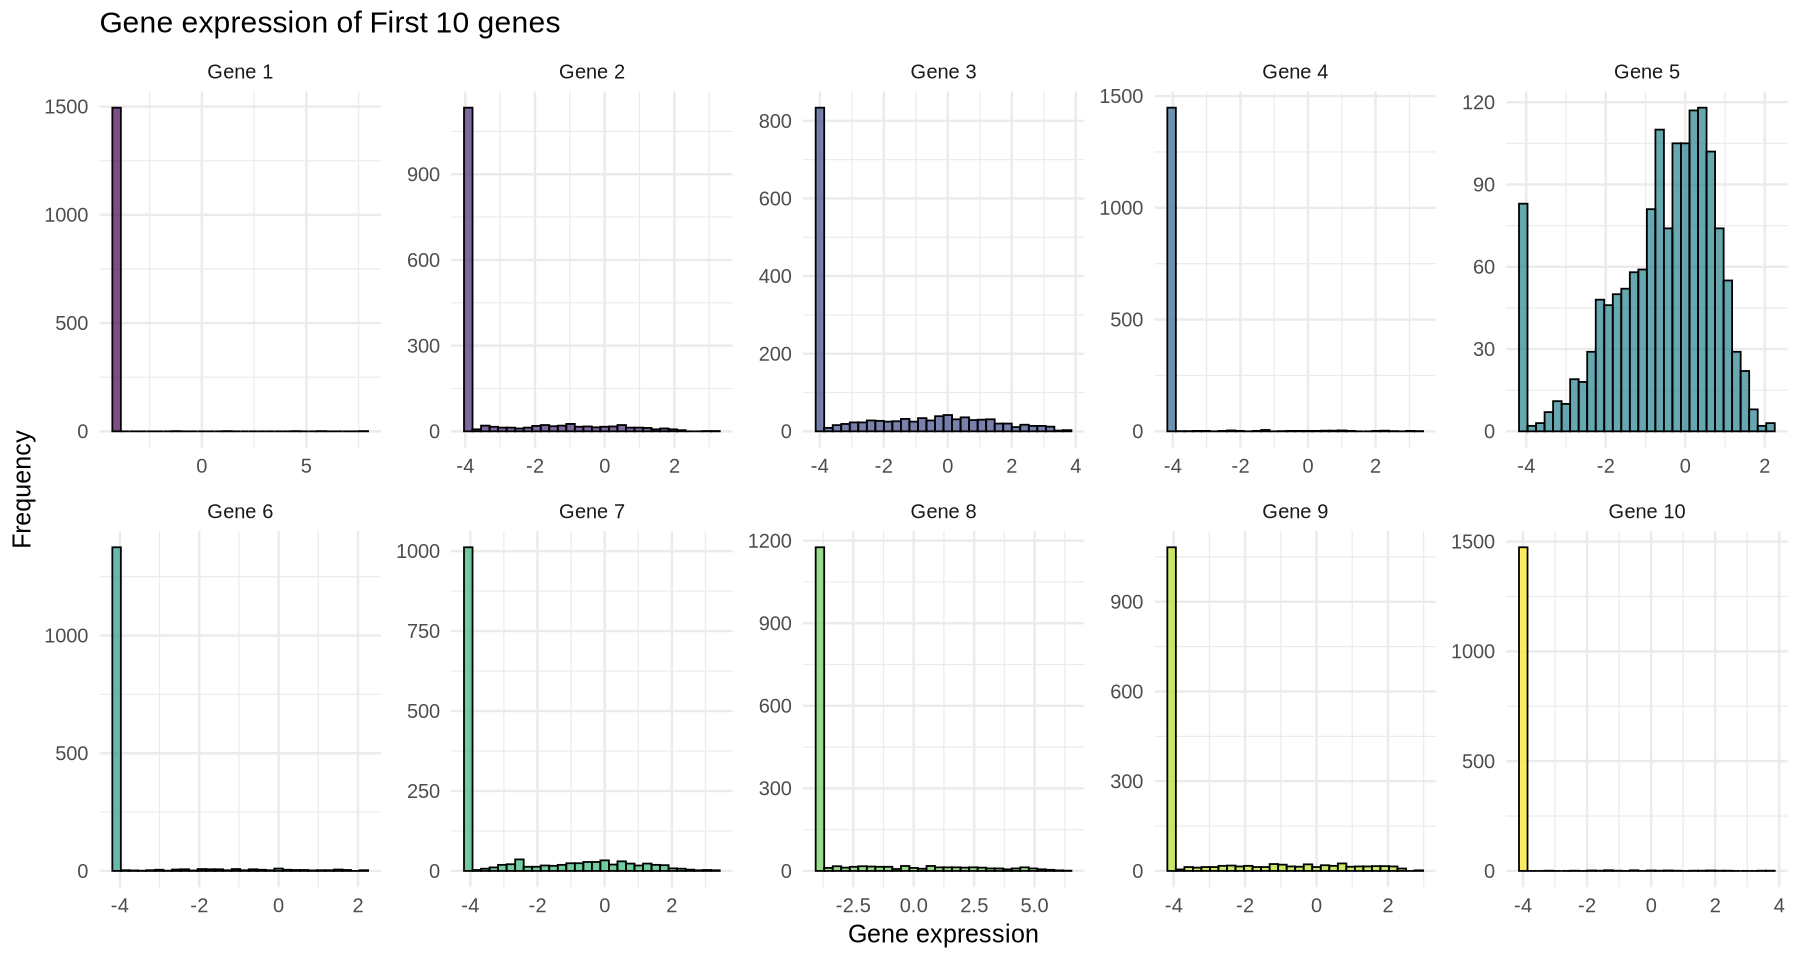

In [37]:
# Convert the first 10 columns of counts_lognormalized to a data frame for ggplot2
plot_data <- as.data.frame(counts_lognormalized[, 1:10])

# Rename the columns as "Gene 1", "Gene 2", ...
colnames(plot_data) <- paste0("Gene ", 1:10)

# Melt the data frame for ggplot2
plot_data <- melt(plot_data, variable.name = "Gene", value.name = "Values")

# Create the ggplot
ggplot(plot_data, aes(x = Values)) +
    geom_histogram(aes(fill = Gene), bins = 30, color = "black", alpha = 0.7) +
    scale_fill_viridis_d() +
    facet_wrap(~Gene, ncol = 5, scales = "free") +
    labs(
        title = "Gene expression of First 10 genes",
        x = "Gene expression",
        y = "Frequency"
    ) +
    theme_minimal(base_size = 15) +
    theme(legend.position = "none")


#### Check that total counts per cell correlate with the number of genes with non-zero counts

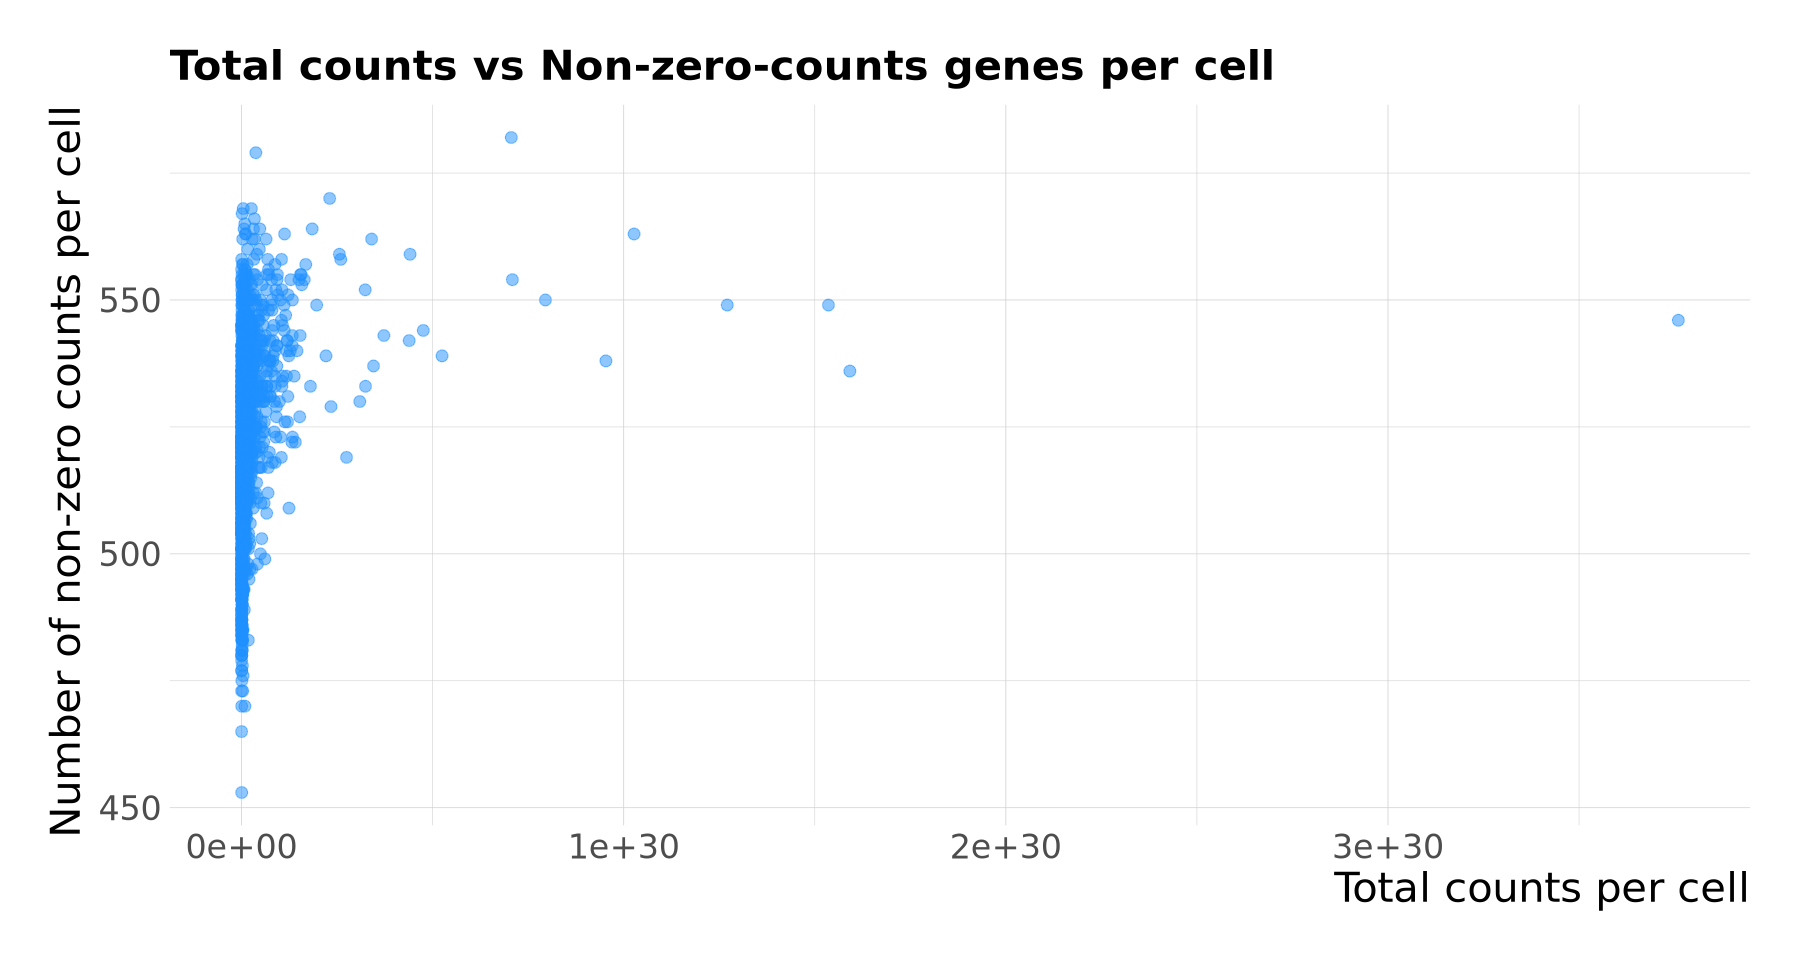

In [39]:
# Calculate the number of rows where sum(counts) > 0
non_zero_counts <- rowSums(counts > 0)

# Create a data frame for plotting
plot_data <- data.frame(Counts = rowSums(counts), NonZeroCounts = non_zero_counts)

# Plot using ggplot2
ggplot(plot_data, aes(x = Counts, y = NonZeroCounts)) +
    geom_point(alpha = 0.5, color = "dodgerblue", size = 3) +
    labs(
        title = "Total counts vs Non-zero-counts genes per cell",
        x = "Total counts per cell",
        y = "Number of non-zero counts per cell"
    ) +
    theme_ipsum_rc(base_size = 20, plot_title_size = 25, axis_title_size = 25)


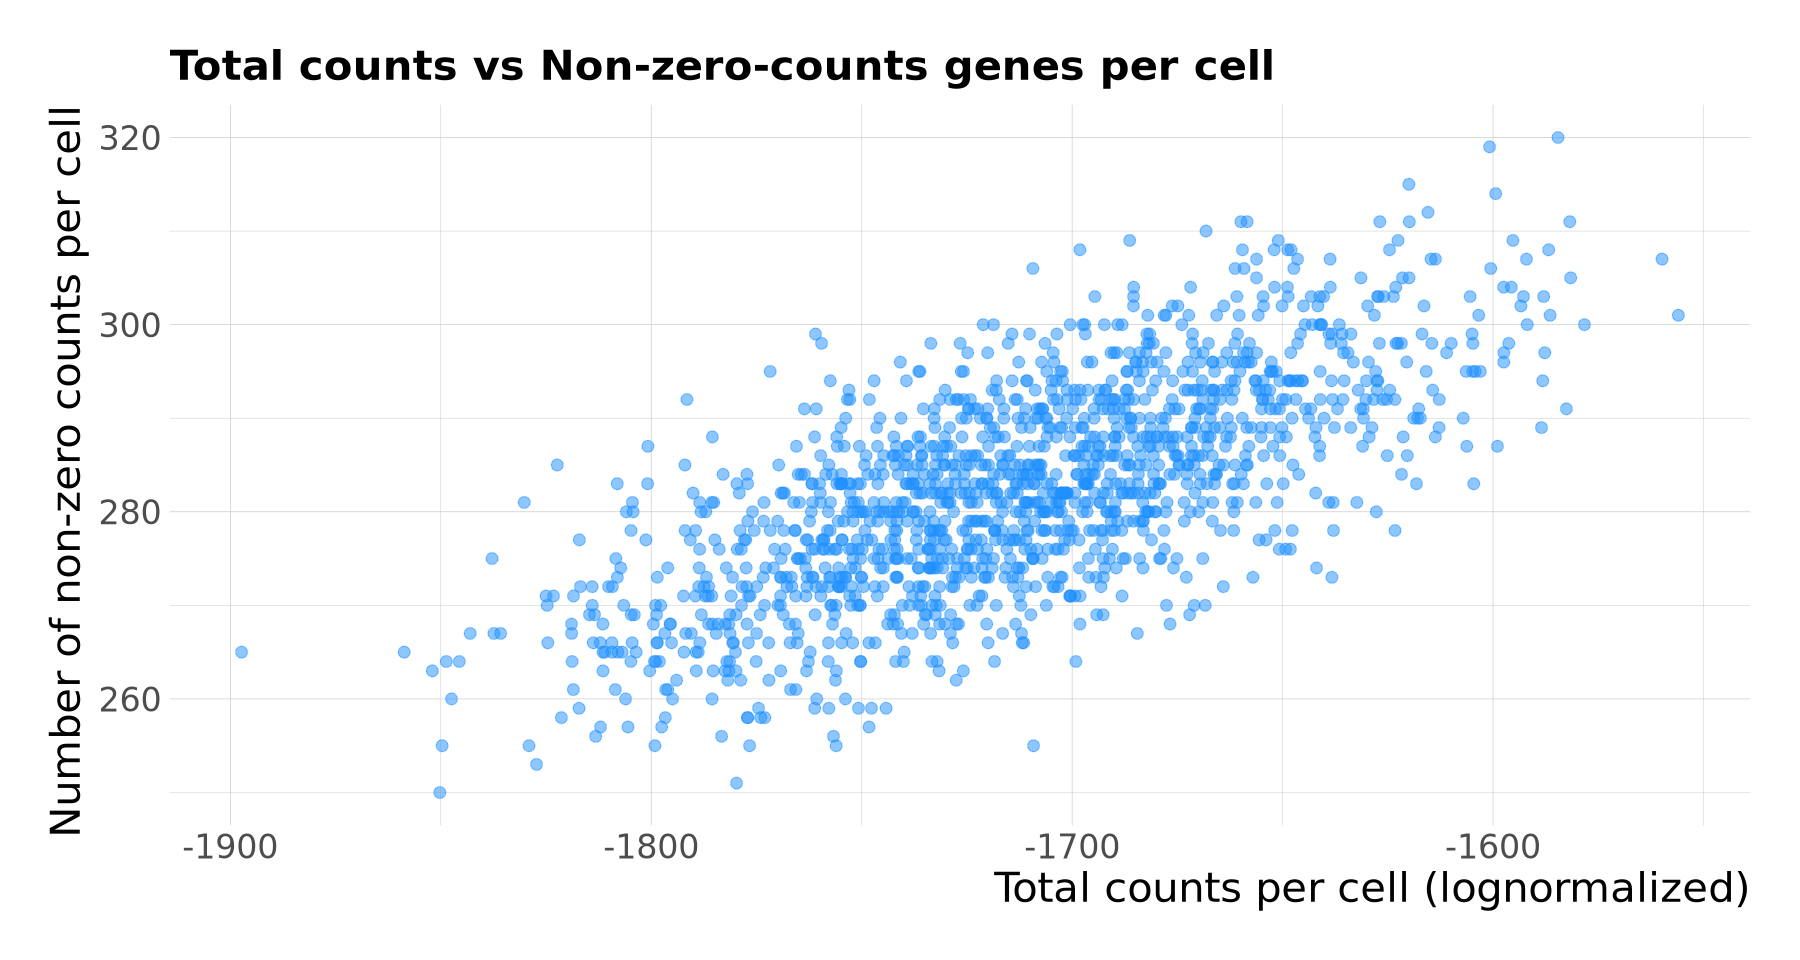

In [38]:
# Calculate the number of rows where sum(counts) > 0
non_zero_counts <- rowSums(counts_lognormalized > 0)

# Create a data frame for plotting
plot_data <- data.frame(Counts = rowSums(counts_lognormalized), NonZeroCounts = non_zero_counts)

# Plot using ggplot2
ggplot(plot_data, aes(x = Counts, y = NonZeroCounts)) +
    geom_point(alpha = 0.5, color = "dodgerblue", size = 3) +
    labs(
        title = "Total counts vs Non-zero-counts genes per cell",
        x = "Total counts per cell (lognormalized)",
        y = "Number of non-zero counts per cell"
    ) +
    theme_ipsum_rc(base_size = 20, plot_title_size = 25, axis_title_size = 25)


#### Check that the cells with 0 expression for a gene correlate with lower sequencing depth or low gene mean expression

# TODOs
- Compare the data generated versus the actual data
- Do this in python in the other notebook?